Found 50 energy files between 1e+01 and 1e+06 GeV:
  E=1.12202e1 (1.122e+01 GeV)
  E=1.41254e1 (1.413e+01 GeV)
  E=1.77828e1 (1.778e+01 GeV)
  E=2.23872e1 (2.239e+01 GeV)
  E=2.81838e1 (2.818e+01 GeV)
  E=3.54813e1 (3.548e+01 GeV)
  E=4.46684e1 (4.467e+01 GeV)
  E=5.62341e1 (5.623e+01 GeV)
  E=7.07946e1 (7.079e+01 GeV)
  E=8.91251e1 (8.913e+01 GeV)
  E=1.12202e2 (1.122e+02 GeV)
  E=1.41254e2 (1.413e+02 GeV)
  E=1.77828e2 (1.778e+02 GeV)
  E=2.23872e2 (2.239e+02 GeV)
  E=2.81838e2 (2.818e+02 GeV)
  E=3.54813e2 (3.548e+02 GeV)
  E=4.46684e2 (4.467e+02 GeV)
  E=5.62341e2 (5.623e+02 GeV)
  E=7.07946e2 (7.079e+02 GeV)
  E=8.91251e2 (8.913e+02 GeV)
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.41

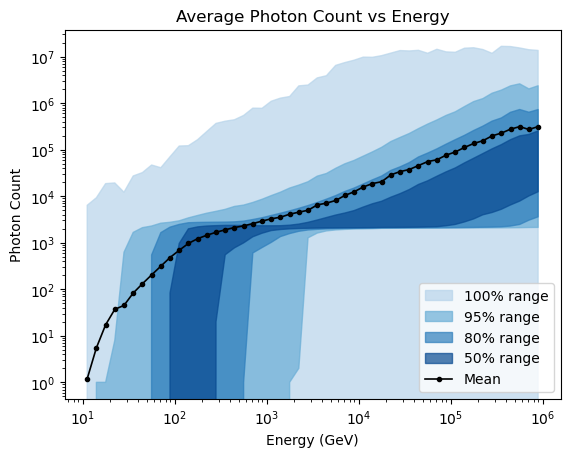

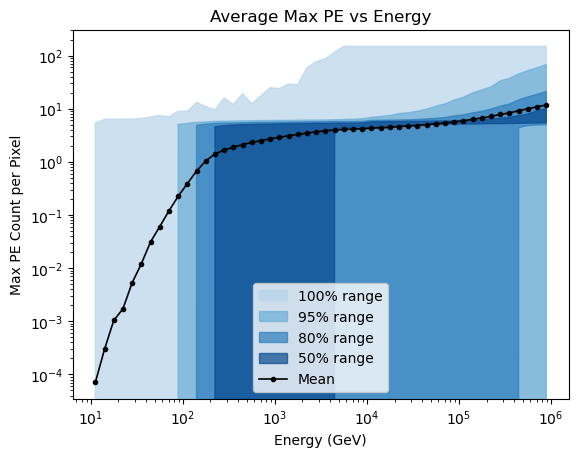

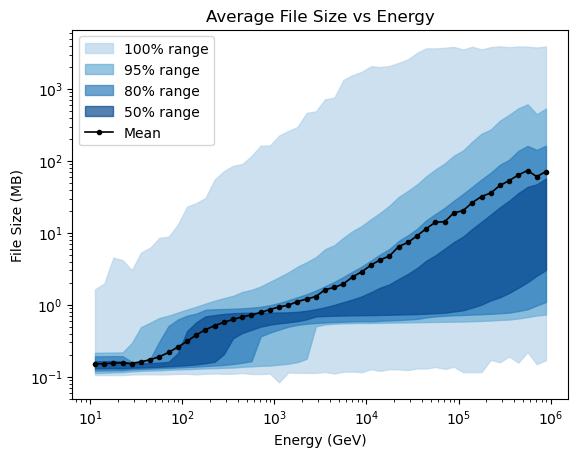

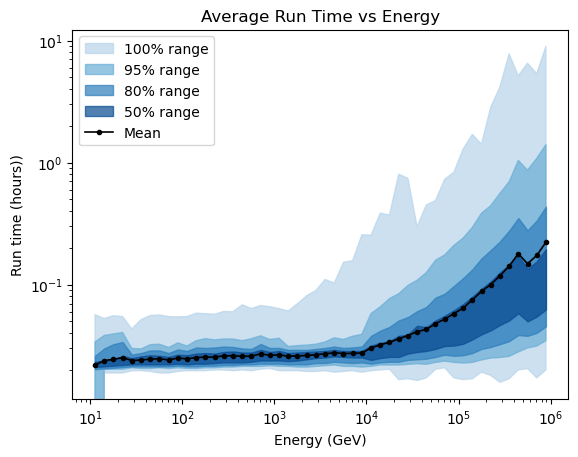

11.793201263094998 TB 4268.6948019655865 photon per MB


In [1]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
#N_BOOTSTRAP = 1000
#CI_LEVEL = 0.99
E_MIN_GEV = 1e1
E_MAX_GEV = 1e6
SEEDS = [1,2,3,4,5,6]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    arg = (obs_height / zem) * np.sin(theta)
    arg = np.clip(arg, -1.0, 1.0)
    beta = np.where(np.isfinite(arg), np.arcsin(arg), 0.0)
    beta = np.clip(beta, 0.0, np.pi/2)
    #beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence


import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"]) # m
X = np.array(df["tel_x"]) # m
Z = np.array(df["tel_z"]) # m
H = np.array(df["height"]) # m
Zenith = np.array(df["zen"]) #Degree
Azimuth = np.array(df["az"]) #Degree
Max_PE = np.array(df["max_pe"]) #Photo_electron
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"]) #ns
Avg_PE = np.array(df["avg_pe"]) 
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"]) #GeV
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth) #Degree
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
x_mag = np.array(df["correction_x_m"]) #m
y_mag = np.array(df["correction_y_m"]) #m
file_size = np.array(df["file_size_MB"]) #MB
photon_count = np.array(df["cph_photon_count"])
#max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))
deleted_low_pe = np.array(df["deleted_low_pe"])
runtime_hours = np.array(df["runtime_seconds"])/3600 
File = []
Photon = []
PE = []
Time = []

Total_FIle_Size = np.nansum(file_size)/1000 - np.nansum(file_size[deleted_low_pe==1])/1000#MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 100]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}
time_bands     = {c: ([], []) for c in coverages}
for energy in E_list:
    mask = (Energy_GeV == energy)&(R==0)

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Max_PE[mask])
    t = np.nanmean(runtime_hours[mask]) 

    File.append(f)
    Photon.append(p)
    PE.append(pe)
    Time.append(t)
    
    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Max_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Max_PE[mask], hi_p))
        time_bands[cov][0].append(np.nanpercentile(runtime_hours[mask], lo_p))
        time_bands[cov][1].append(np.nanpercentile(runtime_hours[mask], hi_p))
File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)
Time   = np.array(Time)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))
    time_bands[cov]   = (np.array(time_bands[cov][0]),     np.array(time_bands[cov][1]))

def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count vs Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "Max PE Count per Pixel", "Average Max PE vs Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size vs Energy")

plot_with_bands(E_list, Time, time_bands, coverages,
                "Run time (hours))", "Average Run Time vs Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


In [2]:
# Fitting Efficiency vs Photon Count Model (per incidence bin)
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.optimize import curve_fit
from scipy.stats import beta
from scipy.special import erf

# --- User settings ---
#PE_THRESHOLD = 5
n_photon_bins = 50
n_inc_bins = 20
ncols = 5

MIN_EVENTS_PER_INC_BIN = 1
MIN_EVENTS_PER_PC_BIN = 1
MIN_TRIGGERS_PER_INC = 1   # minimum total triggers in an incidence slice to attempt a fit
MAX_CHI2_DOF = 10.0
MAX_X0_ERR_LOGN = 1.0
MAX_W_ERR_LOGN = 1.0
EFF_ERR_FLOOR = 0.01
B_ERR_FLOOR = 0.01
W_ERR_FLOOR = 0.01
SATURATION_EFF = 1

B_MODEL  = "const"   # options: "const", "linear", "sigmoid", "sigmoid_fixed" 
X0_MODEL = "log_sigmoid"  # options: "linear", "quadratic", "log_sigmoid"
W_MODEL  = "sigmoid"   # options: "const", "linear", "powerlaw", "lognormal", "sigmoid"

N_BIN_VARIATIONS = 50
N_var_per_key_min = 1
NPC_RANGE  = (50, 200)
NINC_RANGE = (50, 100)

N_BOOTSTRAP = 100
CI_LEVEL = 68  # percent 68
CI_ALPHA = (100.0 - CI_LEVEL) / 2.0

_RNG = np.random.default_rng(0)

# ---- preprocess ----
mask = (
    np.isfinite(photon_count) & (photon_count > 0) &
    np.isfinite(Max_PE) & (Max_PE >= 0) & (R==0) &
    np.isfinite(Incidence)
)

pc = photon_count[mask]
inc = Incidence[mask]
pe = Max_PE[mask]
trig = (pe >= PE_THRESHOLD).astype(float)

pc_for_edges = pc[trig>0]
if pc_for_edges.size == 0:
    raise ValueError("No triggered events to define photon-count bin edges.")

#pc_edges = np.logspace(np.log10(pc_for_edges.min()), np.log10(pc_for_edges.max()), n_photon_bins + 1)
pc_edges = 10**(np.quantile(np.log10(pc_for_edges), np.linspace(0, 1, n_photon_bins + 1)))
n_photon_bins = len(pc_edges) - 1
#inc_edges = np.linspace(inc.min(), inc.max(), n_inc_bins + 1)
inc_edges = np.quantile(inc, np.linspace(0, 1, n_inc_bins + 1))

def clopper_pearson(hits, total, alpha=0.32):
    """
    Two-sided Clopper-Pearson binomial CI.
    alpha = 1 - CI_LEVEL/100  (e.g. 0.32 for 68% CI)
    Returns (lo, hi) arrays, same shape as hits/total.
    Handles hits=0 and hits=total correctly (non-zero width).
    """
    hits = np.asarray(hits, dtype=float)
    total = np.asarray(total, dtype=float)
    lo = np.where(hits > 0, beta.ppf(alpha / 2.0, hits, total - hits + 1), 0.0)
    hi = np.where(hits < total, beta.ppf(1.0 - alpha / 2.0, hits + 1, total - hits), 1.0)
    return lo, hi

from scipy.optimize import minimize

def fit_binomial_logistic(logN_bin, hits_bin, total_bin, p0_lw, bounds_lw):
    """
    Fit erf-sigmoid to binomial counts via maximum likelihood.
    Returns (popt, perr, pcov, chi2_dof_like) in (b, x0, w) parameterization.
    """
    def nll(params):
        b, x0, log_w = params
        w = np.exp(log_w)
        p = logistic_logN(logN_bin, b, x0, w)
        p = np.clip(p, 1e-12, 1 - 1e-12)
        return -np.sum(hits_bin * np.log(p) + (total_bin - hits_bin) * np.log(1 - p))

    scipy_bounds = list(zip(bounds_lw[0], bounds_lw[1]))
    res_fit = minimize(nll, x0=p0_lw, method="L-BFGS-B",
                       bounds=scipy_bounds, options={"maxiter": 5000})

    if not res_fit.success:
        raise RuntimeError(f"NLL fit failed: {res_fit.message}")

    popt_lw = res_fit.x
    # Covariance from inverse Hessian (BFGS approximation)
    try:
        hess_inv = res_fit.hess_inv.todense() if hasattr(res_fit.hess_inv, "todense") else np.array(res_fit.hess_inv)
        pcov_lw = hess_inv
    except Exception:
        pcov_lw = np.eye(3) * np.nan

    # Convert to (b, x0, w) space
    popt = np.array([popt_lw[0], popt_lw[1], np.exp(popt_lw[2])])
    perr_lw = np.sqrt(np.maximum(np.diag(pcov_lw), 0.0))
    perr = np.array([perr_lw[0], perr_lw[1], np.exp(popt_lw[2]) * perr_lw[2]])

    pcov = pcov_lw.copy()
    pcov[2, :] *= np.exp(popt_lw[2])
    pcov[:, 2] *= np.exp(popt_lw[2])

    # Pseudo chi2/dof using binomial deviance
    p_fit = np.clip(logistic_logN(logN_bin, *popt), 1e-12, 1 - 1e-12)
    p_obs = np.clip(hits_bin / np.maximum(total_bin, 1), 1e-12, 1 - 1e-12)
    dev = 2.0 * np.sum(
        hits_bin * np.log(p_obs / p_fit) +
        (total_bin - hits_bin) * np.log((1 - p_obs) / (1 - p_fit))
    )
    dof = len(logN_bin) - 3
    chi2_dof = dev / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof


def logistic_logN(logN, b, x0, w):
    # erf-based sigmoid: b/2 * (1 + erf((logN - x0) / (w * sqrt(2))))
    # w here plays the role of the Gaussian sigma of the underlying
    # threshold distribution (not the logistic scale parameter).
    z = (logN - x0) / (w * np.sqrt(2.0))
    return 0.5 * b * (1.0 + erf(z))

# ---- helper: compute bootstrap eff/err arrays for a slice ----
def compute_bootstrap_arrays(pc_slice, trig_slice, pc_edges_v, rng=_RNG):
    n_bins = len(pc_edges_v) - 1

    idx = np.digitize(pc_slice, pc_edges_v) - 1
    valid = (idx >= 0) & (idx < n_bins)
    idx = idx[valid]
    t = trig_slice[valid]

    total = np.bincount(idx, minlength=n_bins).astype(int)
    hits = np.bincount(idx, weights=t, minlength=n_bins)

    with np.errstate(invalid="ignore", divide="ignore"):
        p_hat = np.where(total > 0, hits / np.maximum(total, 1), np.nan)

    # Clopper-Pearson CI (replaces bootstrap)
    alpha_cp = 1.0 - CI_LEVEL / 100.0
    safe_total = np.maximum(total, 1)
    lo, hi = clopper_pearson(hits, safe_total, alpha=alpha_cp)

    # Mask empty bins
    empty = (total == 0)
    p_hat[empty] = np.nan
    lo = np.where(empty, np.nan, lo)
    hi = np.where(empty, np.nan, hi)

    err_lo = p_hat - lo
    err_hi = hi - p_hat
    err = np.maximum((hi - lo) / 2.0, EFF_ERR_FLOOR)
    err[empty] = np.nan

    # Also return hits for use in likelihood fit (Step 2)
    return p_hat, err, err_lo, err_hi, total, hits

def fit_one_inc_bin(inc_lo, inc_hi, pc_edges_v, rng):
    inc_center = 0.5 * (inc_lo + inc_hi)
    sub = (inc >= inc_lo) & (inc < inc_hi)
    n_sub = int(sub.sum())

    res = {
        "inc_lo": inc_lo,
        "inc_hi": inc_hi,
        "inc_center": inc_center,
        "n_sub": n_sub,
        "ok": False,
        "skip_reason": None,
    }

    if n_sub < MIN_EVENTS_PER_INC_BIN:
        res["skip_reason"] = "low_events"
        return res

    pc_sub = pc[sub]
    trig_sub = trig[sub]

    eff, err, err_lo, err_hi, total, hits = compute_bootstrap_arrays(
        pc_sub, trig_sub, pc_edges_v, rng=rng
    )
    pc_centers = np.sqrt(pc_edges_v[:-1] * pc_edges_v[1:])
    res.update({
        "pc_centers": pc_centers,
        "eff": eff,
        "err": err,
        "err_lo": err_lo,
        "err_hi": err_hi,
        "total": total,
        "hits": hits,
    })

    eff_valid = eff[np.isfinite(eff)]
    saturated = bool(eff_valid.size > 0 and np.all(eff_valid >= SATURATION_EFF))
    good = np.isfinite(eff) & (total >= MIN_EVENTS_PER_PC_BIN)

    # Need some triggers somewhere in this slice to constrain x0
    n_triggers = int(hits.sum())
    if n_triggers < MIN_TRIGGERS_PER_INC:
        res["skip_reason"] = "no_triggers"
        return res

    res.update({
        "good": good,
        "saturated": saturated,
        "n_triggers": n_triggers,
        "min_total": int(np.min(total[total > 0])) if np.any(total > 0) else 0,
    })

    if good.sum() < 3:
        res["skip_reason"] = "low_stats"
        return res

    if saturated:
        res["skip_reason"] = "saturated"
        return res

    # ---- Prepare data for binomial NLL fit ----
    xd = np.log10(pc_centers[good])
    hits_g = hits[good].astype(float)
    total_g = total[good].astype(float)

    # Initial guess from observed efficiencies
    yd_init = hits_g / np.maximum(total_g, 1.0)
    x_range = xd.max() - xd.min()
    b0 = min(max(np.nanmax(yd_init), 0.05), 1.0)
    x0_0 = xd[np.argmin(np.abs(yd_init - 0.5 * b0))]
    w0 = max(0.1 * x_range, 1e-3)

    p0_lw = [b0, x0_0, np.log(max(w0, 1e-3))]
    bounds_lw = (
        [0.0,  xd.min() - 2.0, np.log(1e-3)],
        [1.05, xd.max() + 3.0, np.log(5.0)],
    )

    try:
        popt, perr, pcov, chi2_dof = fit_binomial_logistic(
            xd, hits_g, total_g, p0_lw, bounds_lw
        )
    except Exception:
        res["skip_reason"] = "fit_failed"
        return res

    # Floor on w uncertainty (always positive, physically meaningful)
    perr[2] = max(perr[2], W_ERR_FLOOR)

    # Flag extrapolated x0 (true 50% point lies outside the data range)
    x0_fit = popt[1]
    x0_extrapolated = bool((x0_fit < xd.min()) or (x0_fit > xd.max()))

    # Quality cuts
    ok = True
    if not np.isfinite(chi2_dof) or chi2_dof >= MAX_CHI2_DOF:
        ok = False
    if perr[1] >= MAX_X0_ERR_LOGN or perr[2] >= MAX_W_ERR_LOGN:
        ok = False

    res.update({
        "popt": popt,
        "perr": perr,
        "chi2_dof": chi2_dof,
        "x0_extrapolated": x0_extrapolated,
        "ok": ok,
    })

    if not ok:
        res["skip_reason"] = "quality_cuts"

    return res



# ======================================================================
# Bin-variation loop (binning systematic)
# ======================================================================
agg = defaultdict(list)
agg_perr = defaultdict(list)
agg_chi2 = defaultdict(list)
agg_nsub = defaultdict(list)
agg_skip = defaultdict(lambda: defaultdict(int))

log_pc     = np.log10(pc_for_edges)
log_pc_min = np.log10(pc_for_edges.min())
log_pc_max = np.log10(pc_for_edges.max())

bin_results = [] if N_BIN_VARIATIONS == 1 else None
print("max incidence", max(inc))
for v in range(N_BIN_VARIATIONS):
    rng_v = np.random.default_rng(1000 + v)
    if N_BIN_VARIATIONS == 1:
        npc = n_photon_bins
        ninc = n_inc_bins
    else:
        npc = int(rng_v.integers(NPC_RANGE[0], NPC_RANGE[1] + 1))
        ninc = int(rng_v.integers(NINC_RANGE[0], NINC_RANGE[1] + 1))

    #pc_edges_v = np.logspace(log_pc_min, log_pc_max, npc + 1)
    pc_edges_v = 10**np.quantile(log_pc, np.linspace(0, 1, npc + 1))
    #inc_edges_v = np.linspace(inc.min(), inc.max(), ninc + 1)
    inc_edges_v = np.quantile(inc, np.linspace(0, 1, ninc + 1))
    for i in range(ninc):
        inc_lo, inc_hi = inc_edges_v[i], inc_edges_v[i + 1]
        res = fit_one_inc_bin(inc_lo, inc_hi, pc_edges_v, rng_v)

        if N_BIN_VARIATIONS == 1:
            bin_results.append(res)

        if not res.get("ok", False):
            reason = res.get("skip_reason", "unknown")
            key_r = round(res["inc_center"], 1)
            agg_skip[key_r][reason] += 1
            continue

        key = round(res["inc_center"], 1)
        agg[key].append(res["popt"])
        agg_perr[key].append(res["perr"])
        agg_chi2[key].append(res["chi2_dof"])
        agg_nsub[key].append(res["n_sub"])

# ======================================================================
# Aggregate across binning variations
# ======================================================================
keys_sorted = sorted(agg.keys())
inc_means = np.array(keys_sorted)

b_vals  = np.array([np.median([p[0] for p in agg[k]]) for k in keys_sorted])
x0_vals = np.array([np.median([p[1] for p in agg[k]]) for k in keys_sorted])
w_vals  = np.array([np.median([p[2] for p in agg[k]]) for k in keys_sorted])


def _combined_err(popts, perrs, idx):
    vals = np.array([p[idx] for p in popts])
    stat = np.array([e[idx] for e in perrs])
    syst = vals.std(ddof=1) if len(vals) > 1 else 0.0
    return np.sqrt(np.median(stat) ** 2 + syst ** 2)


b_errs  = np.array([_combined_err(agg[k], agg_perr[k], 0) for k in keys_sorted])
x0_errs = np.array([_combined_err(agg[k], agg_perr[k], 1) for k in keys_sorted])
w_errs  = np.array([_combined_err(agg[k], agg_perr[k], 2) for k in keys_sorted])

chi2_vals = np.array([np.median(agg_chi2[k]) for k in keys_sorted])
n_variations_per_key = np.array([len(agg[k]) for k in keys_sorted])
min_counts = np.array([int(np.median(agg_nsub[k])) for k in keys_sorted])

finite_mask = np.isfinite(b_vals) & np.isfinite(x0_vals) & np.isfinite(w_vals)
stats_mask = n_variations_per_key >= N_var_per_key_min #max(3, N_BIN_VARIATIONS // 10)
chi2_mask = chi2_vals < MAX_CHI2_DOF
quality_mask = finite_mask & stats_mask & chi2_mask

# ======================================================================
# Diagnostics print
# ======================================================================
print("=" * 80)
print("PER-BIN LOGISTIC FIT DIAGNOSTICS (eff vs photon count, per incidence bin)")
print("=" * 80)
print("Fit equation: eff(logN) = (b/2) * (1 + erf((logN - x0) / (w*sqrt(2))))")
print(f"Error bars:   bootstrap {CI_LEVEL:.0f}% CI (N_boot={N_BOOTSTRAP})")
print("-" * 80)
print(f"{'inc_mean':>10} {'b(sat)':>10} {'+/-b':>10} {'x0(logN50)':>12} "
      f"{'+/-x0':>10} {'w(logN)':>10} {'+/-w':>10} {'chi2/dof':>10} {'minN':>8}")
print("-" * 80)
for i in range(len(inc_means)):
    print(f"{inc_means[i]:10.3f} "
          f"{b_vals[i]:10.3g} {b_errs[i]:10.2g} "
          f"{x0_vals[i]:12.3f} {x0_errs[i]:10.2g} "
          f"{w_vals[i]:10.3f} {w_errs[i]:10.2g} "
          f"{chi2_vals[i]:10.2f} {min_counts[i]:8d}")
print("-" * 80)
print(f"Bins fitted: {len(inc_means)} | Bins used for global fits: {int(np.sum(quality_mask))}")
print("=" * 80)
print("\nBIN STABILITY ACROSS BINNING VARIATIONS (skip_reason counts):")
print(f"{'inc_mean':>10} {'ok_count':>10} {'low_events':>12} {'low_stats':>10} "
      f"{'saturated':>10} {'fit_failed':>10} {'quality_cuts':>13} {'unknown':>8}")
print("-" * 90)
for k in keys_sorted:
    n_ok  = len(agg[k])
    skips = agg_skip.get(k, {})
    print(f"{k:10.3f} {n_ok:10d} "
          f"{skips.get('low_events', 0):12d} "
          f"{skips.get('low_stats', 0):10d} "
          f"{skips.get('saturated', 0):10d} "
          f"{skips.get('fit_failed', 0):10d} "
          f"{skips.get('quality_cuts', 0):13d} "
          f"{skips.get('unknown', 0):8d}")
print("-" * 90)
print(f"Note: ok_count + all skip counts should sum to approximately "
      f"N_BIN_VARIATIONS={N_BIN_VARIATIONS} per row (variation in ninc "
      f"means not every variation produces an inc bin at that center).")
dropped = ~quality_mask
if np.any(dropped):
    print("\nBins EXCLUDED from global fits:")
    print(f"{'inc_mean':>10} {'b/err_b':>10} {'chi2/dof':>10} {'minN':>8}  reasons")
    min_req = N_var_per_key_min #max(3, N_BIN_VARIATIONS // 10)
    for i in np.where(dropped)[0]:
        reasons = []
        if not finite_mask[i]:
            reasons.append("nonfinite")
        if not stats_mask[i]:
            reasons.append(f"minN<{min_req}")
        if not chi2_mask[i]:
            reasons.append(f"chi2>{MAX_CHI2_DOF}")
        bs = b_vals[i] / b_errs[i] if np.isfinite(b_errs[i]) and b_errs[i] > 0 else 0.0
        print(f"{inc_means[i]:10.3f} {bs:10.2f} {chi2_vals[i]:10.2f} "
              f"{min_counts[i]:8d}  " + ", ".join(reasons))

if len(inc_means) == 0:
    raise RuntimeError("No valid incidence bins available for global fits.")

# ======================================================================
# Global models: b(inc), x0(inc), w(inc)
# ======================================================================

def b_const(inc_deg, b0):
    return np.full_like(inc_deg, b0, dtype=float)


def b_linear(inc_deg, b0, s):
    return b0 + s * inc_deg

def b_sigmoid(inc_deg, b0=1.0, b_inf=0.5, inc_mid=4.75, k=4.0):
    """b at low inc -> b_inf at high inc, transition at inc_mid with steepness k."""
    return b_inf + (b0 - b_inf) / (1.0 + np.exp(k * (inc_deg - inc_mid)))

B0_FIXED = 1.0      # set to whatever value you want
B_INF_FIXED = 0.0   # set to whatever value you want

def b_sigmoid_fixed(inc_deg, inc_mid, k):
    return B_INF_FIXED + (B0_FIXED - B_INF_FIXED) / (1.0 + np.exp(k * (inc_deg - inc_mid)))


def x0_linear(inc_deg, a, s):
    return a + s * inc_deg


def x0_quadratic(inc_deg, a, s, q):
    return a + s * inc_deg + q * inc_deg**2


def x0_log_sigmoid(inc_deg, x_min, x_max, inc_mid, k):
    return x_min + (x_max - x_min) / (1.0 + np.exp(-k * (inc_deg - inc_mid)))


def w_const(inc_deg, w0):
    return np.full_like(inc_deg, w0, dtype=float)


def w_linear(inc_deg, w0, s):
    return w0 + s * inc_deg


def w_powerlaw(inc_deg, w0, k):
    return w0 * (1.0 + inc_deg) ** k


def w_lognormal(inc_deg, w0, mu, sigma):
    # Gaussian in log(inc); guard inc>0
    x = np.log(np.maximum(inc_deg, 1e-6))
    return w0 * np.exp(-((x - mu) / sigma) ** 2)

def w_sigmoid(inc_deg, w0, w_inf, inc_mid, k):
    # w0 at low inc, w_inf at high inc, transition at inc_mid with steepness k
    return w_inf + (w0 - w_inf) / (1.0 + np.exp(k * (inc_deg - inc_mid)))

inc_min = float(np.min(inc_means)) if len(inc_means) else float(np.min(inc))
inc_max = 10 #float(np.max(inc_means)) if len(inc_means) else float(np.max(inc))
x0_min = float(np.nanmin(x0_vals)) if len(x0_vals) else np.log10(pc_for_edges.min())
x0_max = float(np.nanmax(x0_vals)) if len(x0_vals) else np.log10(pc_for_edges.max())

b_model_cfg = {
    "const": {
        "fn": b_const,
        "p0": [np.nanmedian(b_vals)],
        "bounds": ([0.0], [1.05]),
        "label": "b(inc) = b0",
        "param_names": ["b0"],
    },
    "linear": {
        "fn": b_linear,
        "p0": [np.nanmedian(b_vals), 0.0],
        "bounds": ([0.0, -0.1], [1.05, 0.1]),
        "label": "b(inc) = b0 + s*inc",
        "param_names": ["b0", "s"],
    },
    "sigmoid": {
        "fn": b_sigmoid,
        "p0": [1.0, 0.0, 4.75, 4.0],
        "bounds": (
            [0.5, 0.0, inc_min, 0.0001],
            [1.05, 0.0001, inc_max, 10.0],
        ),
        "label": "b(inc) = b_inf + (b0 - b_inf) / (1 + exp(k*(inc - inc_mid)))",
        "param_names": ["b0", "b_inf", "inc_mid", "k"],
    },
    "sigmoid_fixed": {
        "fn": b_sigmoid_fixed,
        "p0": [4.75, 4.0],
        "bounds": (
            [inc_min, 0.0001],
            [inc_max, 10.0],
        ),
        "label": f"b(inc) = {B_INF_FIXED} + ({B0_FIXED}-{B_INF_FIXED}) / (1 + exp(k*(inc - inc_mid)))",
        "param_names": ["inc_mid", "k"],
    },
}

x0_model_cfg = {
    "linear": {
        "fn": x0_linear,
        "p0": [np.nanmedian(x0_vals), 0.0],
        "bounds": ([x0_min - 2.0, -1.0], [x0_max + 2.0, 1.0]),
        "label": "x0(inc) = a + s*inc",
        "param_names": ["a", "s"],
    },
    "quadratic": {
        "fn": x0_quadratic,
        "p0": [np.nanmedian(x0_vals), 0.0, 0.0],
        "bounds": ([x0_min - 2.0, -1.0, -0.1], [x0_max + 2.0, 1.0, 0.1]),
        "label": "x0(inc) = a + s*inc + q*inc^2",
        "param_names": ["a", "s", "q"],
    },
    "log_sigmoid": {
        "fn": x0_log_sigmoid,
        "p0": [x0_min, x0_max, 0.5 * (inc_min + inc_max), 1.0],
        "bounds": ([x0_min - 2.0, x0_min, inc_min, 0.01],
                   [x0_max, x0_max + 2.0, inc_max, 10.0]),
        "label": "x0(inc) = x_min + (x_max-x_min)/(1+exp(-k*(inc-inc_mid)))",
        "param_names": ["x_min", "x_max", "inc_mid", "k"],
    },
}

w_model_cfg = {
    "const": {
        "fn": w_const,
        "p0": [np.nanmedian(w_vals)],
        "bounds": ([1e-3], [5.0]),
        "label": "w(inc) = w0",
        "param_names": ["w0"],
    },
    "linear": {
        "fn": w_linear,
        "p0": [np.nanmedian(w_vals), 0.0],
        "bounds": ([1e-3, -1.0], [5.0, 1.0]),
        "label": "w(inc) = w0 + s*inc",
        "param_names": ["w0", "s"],
    },
    "powerlaw": {
        "fn": w_powerlaw,
        "p0": [np.nanmedian(w_vals), 0.0],
        "bounds": ([1e-3, -3.0], [5.0, 3.0]),
        "label": "w(inc) = w0 * (1 + inc)^k",
        "param_names": ["w0", "k"],
    },
    "lognormal": {
        "fn": w_lognormal,
        "p0": [np.nanmax(w_vals),
               np.log(max(inc_means[np.nanargmax(w_vals)], 1e-3)),
               1.0],
        "bounds": ([1e-3, np.log(max(inc_min, 1e-3)) - 5.0, 1e-2],
                   [5.0,  np.log(max(inc_max, 1e-3)) + 5.0, 10.0]),
        "label": "w(inc) = w0 * exp(-((log(inc) - mu)/sigma)^2)",
        "param_names": ["w0", "mu", "sigma"],
    },
    "sigmoid": {
        "fn": w_sigmoid,
        "p0": [
            np.nanmedian(w_vals),                 # w0: low-inc plateau
            min(0.01, np.nanmin(w_vals)),         # w_inf: high-inc asymptote
            0.5 * (inc_min + inc_max),            # inc_mid: transition point
            5.0,                                  # k: steepness
        ],
        "bounds": (
            [1e-3, 0.0, inc_min, 0.01],
            [5.0,  5.0, inc_max, 100.0],
        ),
        "label": "w(inc) = w_inf + (w0 - w_inf) / (1 + exp(k*(inc - inc_mid)))",
        "param_names": ["w0", "w_inf", "inc_mid", "k"],
    },
}

if B_MODEL not in b_model_cfg:
    raise ValueError(f"Unknown B_MODEL='{B_MODEL}'. Use 'const' or 'linear', or 'sigmoid', or 'sigmoid_fixed'.")
if X0_MODEL not in x0_model_cfg:
    raise ValueError(f"Unknown X0_MODEL='{X0_MODEL}'. Use 'linear', 'quadratic', or 'log_sigmoid'.")
if W_MODEL not in w_model_cfg:
    raise ValueError(f"Unknown W_MODEL='{W_MODEL}'. Use 'const', 'linear', 'powerlaw', 'lognormal', or 'sigmoid'.")


b_model = b_model_cfg[B_MODEL]
x0_model = x0_model_cfg[X0_MODEL]
w_model = w_model_cfg[W_MODEL]


def fit_model(fn, xdata, ydata, yerr, p0, bounds):
    sigma = np.where(yerr > 0, yerr, EFF_ERR_FLOOR)
    popt, pcov = curve_fit(
        fn, xdata, ydata, p0=p0, sigma=sigma,
        absolute_sigma=True, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = ydata - fn(xdata, *popt)
    chi2 = np.sum((residuals / sigma) ** 2)
    dof = len(xdata) - len(popt)
    chi2_dof = chi2 / dof if dof > 0 else np.nan
    return popt, perr, pcov, chi2_dof


results = {}
results_meta = {}

ok_b = quality_mask & np.isfinite(b_errs)
ok_x0 = quality_mask & np.isfinite(x0_errs)
ok_w = quality_mask & np.isfinite(w_errs)

try:
    popt, perr, pcov, c2 = fit_model(
        b_model["fn"], inc_means[ok_b], b_vals[ok_b],
        np.maximum(b_errs[ok_b], B_ERR_FLOOR),
        p0=b_model["p0"], bounds=b_model["bounds"],
    )
    results["b"] = (popt, perr, pcov)
    results_meta["b"] = {"chi2_dof": c2, "model": B_MODEL}
except Exception as e:
    print(f"b model fit failed: {e}")

try:
    popt, perr, pcov, c2 = fit_model(
        x0_model["fn"], inc_means[ok_x0], x0_vals[ok_x0],
        np.maximum(x0_errs[ok_x0], W_ERR_FLOOR),
        p0=x0_model["p0"], bounds=x0_model["bounds"],
    )
    results["x0"] = (popt, perr, pcov)
    results_meta["x0"] = {"chi2_dof": c2, "model": X0_MODEL}
except Exception as e:
    print(f"x0 model fit failed: {e}")

try:
    popt, perr, pcov, c2 = fit_model(
        w_model["fn"], inc_means[ok_w], w_vals[ok_w],
        np.maximum(w_errs[ok_w], W_ERR_FLOOR),
        p0=w_model["p0"], bounds=w_model["bounds"],
    )
    results["w"] = (popt, perr, pcov)
    results_meta["w"] = {"chi2_dof": c2, "model": W_MODEL}
except Exception as e:
    print(f"w model fit failed: {e}")
# ======================================================================
# Empirical cross-group correlation of (b, x0, w) from binning variations
# ======================================================================
# For each quality-masked incidence bin, agg[k] holds a list of (b, x0, w)
# triplets — one per binning variation that passed quality cuts. The empirical
# 3x3 covariance of those triplets captures how b, x0, w co-vary in practice.
# Pooling across bins gives a representative correlation matrix that Cell 4
# uses to populate the off-diagonal blocks of the joint parameter covariance.

_emp_covs_list = []
for k, qm in zip(keys_sorted, quality_mask):
    if not qm:
        continue
    if len(agg[k]) < 4:          # need at least 4 samples for a meaningful estimate
        continue
    _triplets = np.array(agg[k])  # (n_variations, 3): columns = [b, x0, w]
    _emp_covs_list.append(np.cov(_triplets.T))   # (3, 3)

if len(_emp_covs_list) > 0:
    _EMP_JOINT_COV_3x3_raw = np.mean(_emp_covs_list, axis=0)   # (3, 3) pooled

    # Convert to correlation matrix: C_ij / (sigma_i * sigma_j)
    _std3 = np.sqrt(np.maximum(np.diag(_EMP_JOINT_COV_3x3_raw), 0.0))
    _outer_std = np.outer(_std3, _std3)
    EMP_JOINT_CORR_3x3 = np.where(
        _outer_std > 0,
        _EMP_JOINT_COV_3x3_raw / _outer_std,
        0.0,
    )
    # Clip to valid correlation range for numerical safety
    np.clip(EMP_JOINT_CORR_3x3, -1.0, 1.0, out=EMP_JOINT_CORR_3x3)
    # Force exact diagonal = 1 (rounding can push it slightly off)
    np.fill_diagonal(EMP_JOINT_CORR_3x3, 1.0)

    print("\nEmpirical cross-group correlation matrix (b, x0, w):")
    print(f"  Pooled from {len(_emp_covs_list)} quality bins "
          f"(min 4 variations each)")
    print(f"  ρ(b,  x0) = {EMP_JOINT_CORR_3x3[0, 1]:.4f}")
    print(f"  ρ(b,   w) = {EMP_JOINT_CORR_3x3[0, 2]:.4f}")
    print(f"  ρ(x0,  w) = {EMP_JOINT_CORR_3x3[1, 2]:.4f}")
else:
    EMP_JOINT_CORR_3x3 = np.eye(3, dtype=float)
    print("\nWarning: no quality bins had >= 4 binning variations. "
          "EMP_JOINT_CORR_3x3 set to identity (zero cross-group correlations).")

del _emp_covs_list


max incidence 5.736265562895281
PER-BIN LOGISTIC FIT DIAGNOSTICS (eff vs photon count, per incidence bin)
Fit equation: eff(logN) = (b/2) * (1 + erf((logN - x0) / (w*sqrt(2))))
Error bars:   bootstrap 68% CI (N_boot=100)
--------------------------------------------------------------------------------
  inc_mean     b(sat)       +/-b   x0(logN50)      +/-x0    w(logN)       +/-w   chi2/dof     minN
--------------------------------------------------------------------------------
     0.200       1.05       0.58        5.801       0.23      0.487       0.09       1.23    30894
     0.400       1.05       0.73        5.784       0.43      0.581       0.27       0.98    13946
     0.500       1.05       0.63        5.827       0.25      0.501      0.072       1.22    29493
     0.600       1.05       0.67        5.865       0.33      0.635       0.12       1.46    13949
     0.700       1.05       0.63        5.881       0.29      0.552      0.064       2.49    45371
     0.800       1.05  

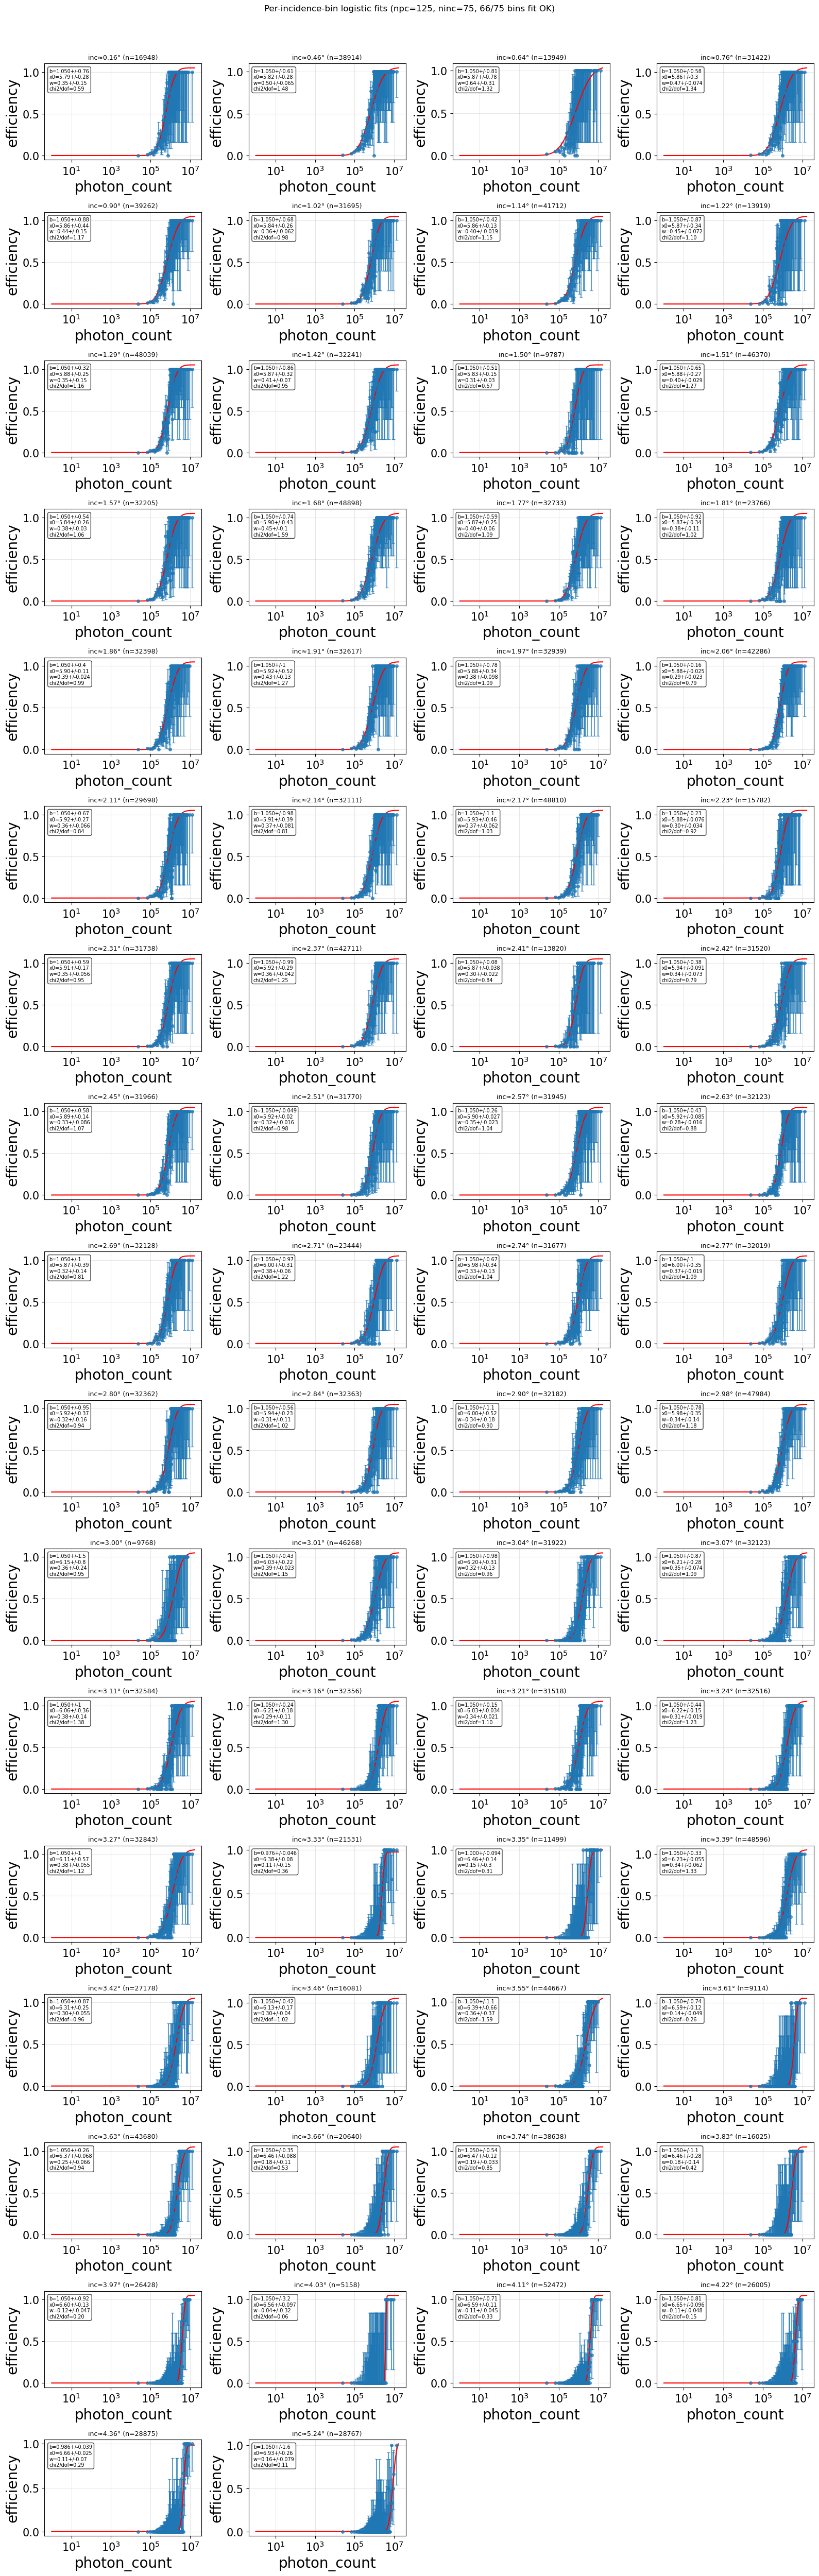

In [32]:
# Per-incidence-bin efficiency curves and logistic fits
# ======================================================================
if N_BIN_VARIATIONS == 1:
    nrows = int(np.ceil(n_inc_bins / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes).ravel()

    N_smooth = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 300)

    for i in range(n_inc_bins):
        ax = axes[i]
        r = bin_results[i]
        inc_lo, inc_hi = r["inc_lo"], r["inc_hi"]
        n_sub = r["n_sub"]
        inc_c = r["inc_center"]

        if n_sub == 0:
            ax.set_title(f"inc in [{inc_lo:.2f},{inc_hi:.2f}]\nN=0")
            continue

        if r.get("skip_reason") in ("low_events", "low_stats", "fit_failed", "saturated", "quality_cuts"):
            ax.set_title(f"inc in [{inc_lo:.2f},{inc_hi:.2f}]\nN={n_sub}")
            ax.text(0.5, 0.5, r.get("skip_reason", "skip"),
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color="darkred")
            continue

        pc_centers = r["pc_centers"]
        eff = r["eff"]
        err_lo = r["err_lo"]
        err_hi = r["err_hi"]

        yerr_asym = np.array([
            np.where(np.isfinite(err_lo), err_lo, 0),
            np.where(np.isfinite(err_hi), err_hi, 0),
        ])

        ax.errorbar(pc_centers, eff, yerr=yerr_asym, fmt="o", capsize=2,
                    label=f"bootstrap {CI_LEVEL:.0f}% CI")

        popt = r["popt"]
        chi2_dof = r["chi2_dof"]
        ax.plot(N_smooth, logistic_logN(np.log10(N_smooth), *popt), "r-", lw=1.5)

        b, x0, w = popt
        txt = (f"b={b:.3f}\n"
               f"x0={x0:.2f}\n"
               f"w={w:.2f}\n"
               f"chi2/dof={chi2_dof:.2f}")
        ax.text(0.05, 0.95, txt, transform=ax.transAxes,
                fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round", fc="white", alpha=0.75))

        ax.set_title(f"inc≈{inc_c:.2f}° (n={n_sub})", fontsize=9)
        ax.set_xscale("log")
        ax.set_xlabel("photon_count")
        ax.set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7, loc="lower right")

    for j in range(n_inc_bins, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Trigger efficiency vs photon count | bootstrap {CI_LEVEL:.0f}% CI", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- Plot representative per-incidence-bin fits (median binning) ---
npc_plot = int(np.median(NPC_RANGE))
ninc_plot = int(np.median(NINC_RANGE))

#pc_edges_plot = np.logspace(log_pc_min, log_pc_max, npc_plot + 1)
pc_edges_plot = 10**np.quantile(log_pc, np.linspace(0, 1, npc_plot + 1))
#inc_edges_plot = np.linspace(inc.min(), inc.max(), ninc_plot + 1)
inc_edges_plot = np.quantile(inc, np.linspace(0, 1, ninc_plot + 1))

plot_results = []
for i in range(ninc_plot):
    res = fit_one_inc_bin(inc_edges_plot[i], inc_edges_plot[i + 1],
                          pc_edges_plot, _RNG)
    if res is not None and res.get("ok", False):
        plot_results.append(res)

n_plots = len(plot_results)
if n_plots == 0:
    print(res)
    print("No successful per-incidence-bin fits to plot.")
else:
    ncols_p = 4
    nrows_p = int(np.ceil(n_plots / ncols_p))
    fig, axes = plt.subplots(nrows_p, ncols_p,
                             figsize=(4 * ncols_p, 3 * nrows_p),
                             squeeze=False)
    axes = axes.flatten()

    N_smooth = np.logspace(np.log10(pc.min()), np.log10(pc.max()), 300)

    for ax, res in zip(axes, plot_results):
        pc_c = res["pc_centers"]
        eff = res["eff"]
        elo = res["err_lo"]
        ehi = res["err_hi"]
        popt = res["popt"]
        perr = res["perr"]
        c2 = res["chi2_dof"]
        inc_c = res["inc_center"]

        yerr = np.vstack([elo, ehi])

        ax.errorbar(pc_c, eff, yerr=yerr, fmt="o", color="C0", alpha=0.7,
                    capsize=2, ms=4, label="data")
        ax.plot(N_smooth, logistic_logN(np.log10(N_smooth), *popt),
                "r-", lw=1.5, label="fit")

        b, x0, w = popt
        be, x0e, we = perr
        txt = (f"b={b:.3f}+/-{be:.2g}\n"
               f"x0={x0:.2f}+/-{x0e:.2g}\n"
               f"w={w:.2f}+/-{we:.2g}\n"
               f"chi2/dof={c2:.2f}")
        ax.text(0.03, 0.95, txt, transform=ax.transAxes,
                fontsize=7, va="top", ha="left",
                bbox=dict(boxstyle="round", fc="white", alpha=0.75))

        ax.set_title(f"inc≈{inc_c:.2f}° (n={res['n_sub']})", fontsize=9)
        ax.set_xlabel("photon_count")
        ax.set_ylabel("efficiency")
        ax.set_xscale("log")
        ax.grid(alpha=0.3)

    for ax in axes[n_plots:]:
        ax.axis("off")

    fig.suptitle(
        f"Per-incidence-bin logistic fits "
        f"(npc={npc_plot}, ninc={ninc_plot}, {n_plots}/{ninc_plot} bins fit OK)",
        fontsize=12,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

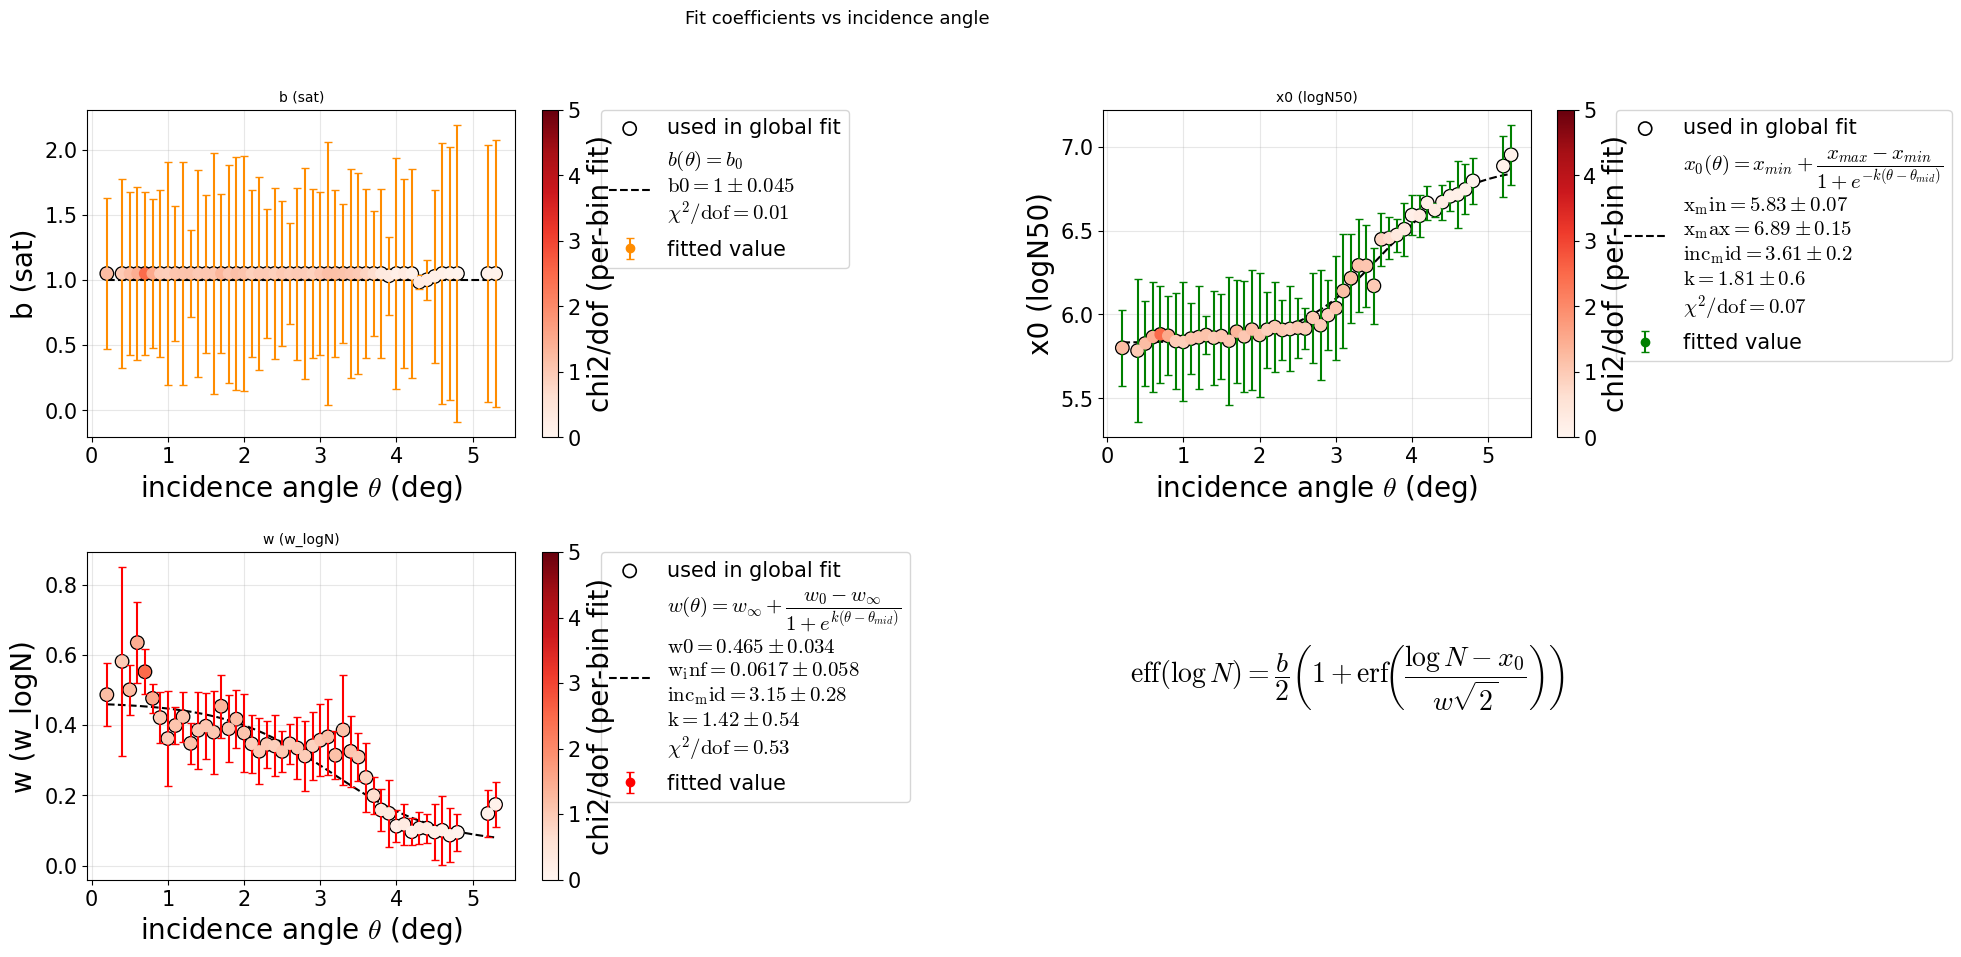


PHYSICAL MODEL FITS (coefficient vs incidence angle)

--- Model for parameter 'b' ---
Equation:  b(inc) = b0
            b0 = 1.001 +/- 0.045
      chi2/dof = 0.007

--- Model for parameter 'x0' ---
Equation:  x0(inc) = x_min + (x_max-x_min)/(1+exp(-k*(inc-inc_mid)))
         x_min = 5.831 +/- 0.07
         x_max = 6.886 +/- 0.15
       inc_mid = 3.609 +/- 0.2
             k = 1.809 +/- 0.6
      chi2/dof = 0.074

--- Model for parameter 'w' ---
Equation:  w(inc) = w_inf + (w0 - w_inf) / (1 + exp(k*(inc - inc_mid)))
            w0 = 0.4652 +/- 0.034
         w_inf = 0.06165 +/- 0.058
       inc_mid = 3.152 +/- 0.28
             k = 1.421 +/- 0.54
      chi2/dof = 0.532


In [33]:
# Comparison plot: coefficients vs incidence
# ======================================================================
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False  # use mathtext (no LaTeX install needed)
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern-like font for nicer math

# Comparison plot: coefficients vs incidence
# ======================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.ravel()

inc_smooth = np.linspace(inc_means.min(), inc_means.max(), 300)

labels = ["b (sat)", "x0 (logN50)", "w (w_logN)"]
yvals = [b_vals, x0_vals, w_vals]
yerrs = [b_errs, x0_errs, w_errs]
colors = ["darkorange", "green", "red"]
model_keys = ["b", "x0", "w"]
model_fns = [b_model["fn"], x0_model["fn"], w_model["fn"]]

# LaTeX/mathtext equations for each parameter's model vs incidence angle
model_eqs = {
    "b": {
        "const":         r"$b(\theta) = b_0$",
        "linear":        r"$b(\theta) = b_0 + s\,\theta$",
        "sigmoid":       r"$b(\theta) = b_\infty + \dfrac{b_0 - b_\infty}{1 + e^{k(\theta - \theta_{mid})}}$",
        "sigmoid_fixed": rf"$b(\theta) = {B_INF_FIXED} + \dfrac{{{B0_FIXED} - {B_INF_FIXED}}}{{1 + e^{{k(\theta - \theta_{{mid}})}}}}$",
    },
    "x0": {
        "linear":      r"$x_0(\theta) = a + s\,\theta$",
        "quadratic":   r"$x_0(\theta) = a + s\,\theta + q\,\theta^2$",
        "log_sigmoid": r"$x_0(\theta) = x_{min} + \dfrac{x_{max} - x_{min}}{1 + e^{-k(\theta - \theta_{mid})}}$",
    },
    "w": {
        "const":     r"$w(\theta) = w_0$",
        "linear":    r"$w(\theta) = w_0 + s\,\theta$",
        "powerlaw":  r"$w(\theta) = w_0\,(1 + \theta)^k$",
        "lognormal": r"$w(\theta) = w_0\,\exp\!\left(-\left(\dfrac{\ln\theta - \mu}{\sigma}\right)^2\right)$",
        "sigmoid":   r"$w(\theta) = w_\infty + \dfrac{w_0 - w_\infty}{1 + e^{k(\theta - \theta_{mid})}}$",
    },
}

selected_model = {"b": B_MODEL, "x0": X0_MODEL, "w": W_MODEL}

param_names = {
    "b": b_model["param_names"],
    "x0": x0_model["param_names"],
    "w": w_model["param_names"],
}

# Base efficiency equation, shown once as a figure-level annotation
base_eq = r"$\mathrm{eff}(\log N) = \dfrac{b}{2}\left(1 + \mathrm{erf}\!\left(\dfrac{\log N - x_0}{w\sqrt{2}}\right)\right)$"

for ax, lbl, yv, ye, col, mkey, mfn in zip(
        axes[:len(labels)], labels, yvals, yerrs, colors, model_keys, model_fns):

    qm = quality_mask
    ax.errorbar(inc_means[qm], yv[qm], yerr=ye[qm], fmt="o", color=col,
                capsize=3, label="fitted value", zorder=3)
    sc = ax.scatter(inc_means[qm], yv[qm], c=chi2_vals[qm], cmap="Reds",
                    vmin=0, vmax=5, zorder=5, s=60)
    plt.colorbar(sc, ax=ax, label="chi2/dof (per-bin fit)")
    ax.scatter(inc_means[qm], yv[qm],
               facecolors="none", edgecolors="black", s=90,
               linewidths=1.2, label="used in global fit")

    if mkey in results:
        popt, perr, _ = results[mkey]
        c2 = results_meta.get(mkey, {}).get("chi2_dof", np.nan)

        eq_str = model_eqs[mkey][selected_model[mkey]]

        # Build a LaTeX-style (mathtext) label with equation + fitted parameters + chi2/dof
        param_lines = "\n".join(
            rf"$\mathrm{{{n}}} = {v:.3g} \pm {e:.2g}$"
            for n, v, e in zip(param_names[mkey], popt, perr)
        )
        full_model_label = (f"{eq_str}\n"
                             f"{param_lines}\n"
                             rf"$\chi^2/\mathrm{{dof}} = {c2:.2f}$")

        ax.plot(inc_smooth, mfn(inc_smooth, *popt), "k--",
                lw=1.5, label=full_model_label)

    ax.set_xlabel(r"incidence angle $\theta$ (deg)")
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10)
    ax.legend(fontsize=15, loc="upper left", bbox_to_anchor=(1.2, 1.0),
              borderaxespad=0.)
    ax.grid(alpha=0.3)

for ax in axes[len(labels):]:
    ax.axis("off")

fig.suptitle("Fit coefficients vs incidence angle", fontsize=13)
# Show the base efficiency equation once, e.g. in the unused 4th panel
axes[3].text(0.05, 0.6, base_eq, fontsize=20, transform=axes[3].transAxes)
fig.subplots_adjust(wspace=0.9, hspace=0.35)
plt.show()

# ======================================================================
# Physical model summary
# ======================================================================
print("\n" + "=" * 80)
print("PHYSICAL MODEL FITS (coefficient vs incidence angle)")
print("=" * 80)
model_equations = {
    "b": b_model["label"],
    "x0": x0_model["label"],
    "w": w_model["label"],
}
for key in ["b", "x0", "w"]:
    print(f"\n--- Model for parameter '{key}' ---")
    print(f"Equation:  {model_equations[key]}")
    if key in results:
        popt, perr, _ = results[key]
        c2 = results_meta.get(key, {}).get("chi2_dof", np.nan)
        for name, val, err in zip(param_names[key], popt, perr):
            print(f"  {name:>12} = {val:.4g} +/- {err:.2g}")
        print(f"  {'chi2/dof':>12} = {c2:.3f}")
    else:
        print("  FIT FAILED or not available")
print("=" * 80)

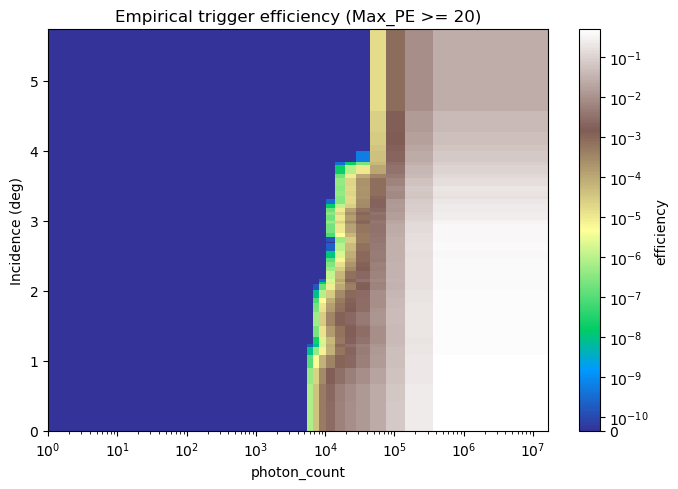

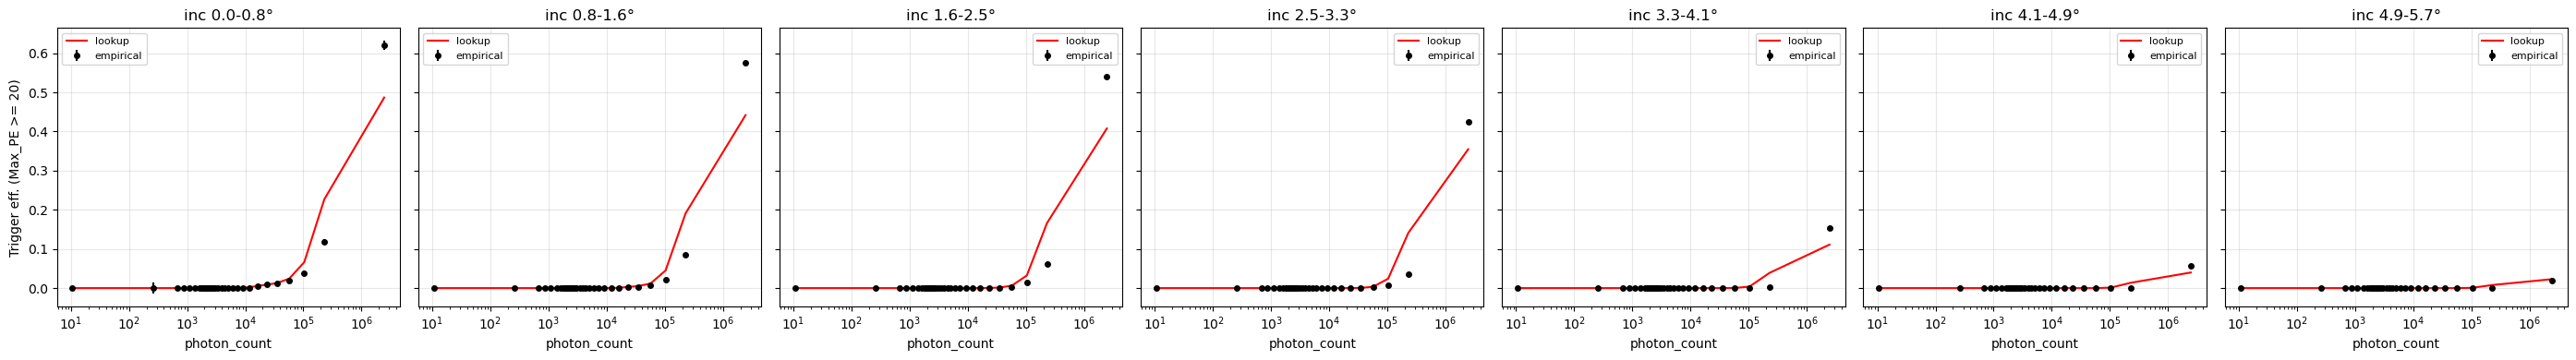

Running 100 bootstrap replicas on 56 CPUs...


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done  10 out of 100 | elapsed:   12.4s remaining:  1.9min
[Parallel(n_jobs=56)]: Done  31 out of 100 | elapsed:   14.5s remaining:   32.2s
[Parallel(n_jobs=56)]: Done  52 out of 100 | elapsed:   15.8s remaining:   14.5s
[Parallel(n_jobs=56)]: Done  73 out of 100 | elapsed:   18.2s remaining:    6.7s
[Parallel(n_jobs=56)]: Done  94 out of 100 | elapsed:   19.0s remaining:    1.2s
[Parallel(n_jobs=56)]: Done 100 out of 100 | elapsed:   19.2s finished


Done: 100 interpolators built.
[COV] Data-density mask (spline interp)
[COV] range: 0.0474 to 0.9526
Building SymPy Jacobian for active model variant (const / log_sigmoid / sigmoid)...
  Parameters (9): ['b0', 'x_min', 'x_max', 'inc_mid_x0', 'k_x0', 'w0', 'w_inf', 'inc_mid_w', 'k_w']
  Jacobian lambdified OK.
[Jacobian] Using EMP_JOINT_CORR_3x3: ρ(b,x0)=-0.191  ρ(b,w)=0.357  ρ(x0,w)=-0.177
[Jacobian] PSD correction: clipped 1 negative eigenvalue(s).
σ_jac surface: min=0.000e+00  max=6.054e-01  mean=2.584e-02
CI_LEVEL=68%  →  z = 0.9945
Stored surfaces of shape (100, 250), total size: 0.4 MB
N=1.00e+01, inc=4,  nom=1.092e-04  CI68%=[9.985e-05, 1.092e-04]
N=4.64e+01, inc=4,  nom=1.148e-04  CI68%=[1.049e-04, 1.148e-04]
N=2.15e+02, inc=4,  nom=1.204e-04  CI68%=[1.100e-04, 1.204e-04]
N=1.00e+03, inc=4,  nom=1.259e-04  CI68%=[1.151e-04, 1.259e-04]
N=4.64e+03, inc=4,  nom=1.315e-04  CI68%=[1.202e-04, 1.316e-04]
N=2.15e+04, inc=4,  nom=1.378e-04  CI68%=[1.258e-04, 1.658e-04]
N=1.00e+05, inc=4,

In [3]:
# Bootstrap with combined statistical + binning systematics
# Empirical region : bootstrap resampling (unchanged)
# Extrapolation region : Jacobian / analytic error propagation (replaces _PARAM_CUBE)
# Blending (quadrature, lo/hi separately):
#   lo = nominal - sqrt( COV^2*(nominal-lo_emp)^2 + (1-COV)^2*(z*sigma_jac)^2 )
#   hi = nominal + sqrt( COV^2*(hi_emp-nominal)^2 + (1-COV)^2*(z*sigma_jac)^2 )
# =============================================================================
# Empirical trigger efficiency: P(Max_PE >= threshold | photon_count, incidence)
# =============================================================================
from scipy.ndimage import gaussian_filter
from matplotlib.colors import SymLogNorm

# ---------- 1. Clean inputs ----------
m = (np.isfinite(photon_count) & (photon_count > 0)
     & np.isfinite(Max_PE)     & (Max_PE >= 0) & (R==0)
     & np.isfinite(Incidence))
pc_  = photon_count[m]
pe_  = Max_PE[m]
inc_ = Incidence[m]
hit_ = (pe_ >= PE_THRESHOLD).astype(float)

"""# ---------- 2. Define 2-D bins ----------
pc_edges  = 10**np.quantile(np.log10(pc_), np.linspace(0,1, 70))#np.logspace(np.log10(pc_.min()), np.log10(pc_.max()), 50)
inc_edges = np.quantile(inc_, np.linspace(0,1, 70)) #np.linspace(inc_.min(),inc_.max(), 50)
pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5*(inc_edges[:-1] + inc_edges[1:])"""
# ---------- 2. Define 2-D bins ----------
pc_edges  = 10**np.quantile(np.log10(pc_), np.linspace(0, 1, 50))
inc_edges = np.quantile(inc_, np.linspace(0, 1, 50))

# Remove duplicate/non-increasing edges (can occur with clustered data)
pc_edges  = np.unique(pc_edges)
inc_edges = np.unique(inc_edges)

pc_cen    = np.sqrt(pc_edges[:-1] * pc_edges[1:])
inc_cen   = 0.5 * (inc_edges[:-1] + inc_edges[1:])

# ---------- 3. Build empirical efficiency table ----------
N_tot, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges])
N_hit, _, _ = np.histogram2d(pc_, inc_, bins=[pc_edges, inc_edges], weights=hit_)

with np.errstate(invalid='ignore', divide='ignore'):
    eff = np.where(N_tot >= 5, N_hit / N_tot, np.nan)
    eff_err = np.where(N_tot >= 5, np.sqrt(eff*(1-eff)/N_tot), np.nan)

# Light smoothing to fill noisy bins (optional)
eff_smooth = eff.copy()
mask = np.isfinite(eff_smooth)
eff_smooth[~mask] = 0
weights = mask.astype(float)
sigma_value = 0.8
eff_smooth = gaussian_filter(eff_smooth, sigma=sigma_value) / np.clip(
    gaussian_filter(weights, sigma=sigma_value), 1e-6, None)

# ---------- 4. Lookup function with bilinear interpolation ----------
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (np.log10(pc_cen), inc_cen), eff_smooth,
    bounds_error=False, fill_value=None, method='linear')

def trigger_eff(N_gamma, inc_deg):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), pc_.min(), pc_.max())),
        np.clip(inc_b.ravel(), inc_.min(), inc_.max()),
    ])
    vals = np.clip(interp(pts), 0.0, 1.0)
    return vals.reshape(N_b.shape)

# ---------- 5. Plot the efficiency map ----------
fig, ax = plt.subplots(figsize=(7,5))
pcm = ax.pcolormesh(pc_edges, inc_edges, eff_smooth.T, #eff_smooth.T,
                    cmap='terrain', norm=SymLogNorm(linthresh=np.min(eff_smooth[np.where(eff_smooth>0)]), linscale=0.5, base=10))
ax.set_xscale('log')
ax.set_xlabel("photon_count"); ax.set_ylabel("Incidence (deg)")
ax.set_title(f"Empirical trigger efficiency (Max_PE >= {PE_THRESHOLD})")
plt.colorbar(pcm, ax=ax, label='efficiency')
plt.tight_layout(); plt.show()

# ---------- 6. Slice validation ----------
bounds = np.linspace(inc_.min(), inc_.max(), 8)
slices = list(zip(bounds[:-1], bounds[1:]))
fig, axes = plt.subplots(1, len(slices), figsize=(4*len(slices), 4), sharey=True)
for ax, (ilo, ihi) in zip(axes, slices):
    sel = (inc_ >= ilo) & (inc_ < ihi)
    emp, err = [], []
    for i in range(len(pc_cen)):
        s2 = sel & (pc_ >= pc_edges[i]) & (pc_ < pc_edges[i+1])
        n = s2.sum()
        if n >= 5:
            p = np.mean(hit_[s2]); emp.append(p)
            err.append(np.sqrt(p*(1-p)/n) + 1.0/n)
        else:
            emp.append(np.nan); err.append(np.nan)
    emp, err = np.array(emp), np.array(err)
    pred = trigger_eff(pc_cen, 0.5*(ilo+ihi))
    ax.errorbar(pc_cen, emp, yerr=err, fmt='ko', ms=4, label='empirical')
    ax.plot(pc_cen, pred, 'r-', label='lookup')
    ax.set_xscale('log')#; ax.set_ylim(-0.05, 1.1)
    #ax.set_yscale('log')
    ax.set_xlabel("photon_count")
    ax.set_title(f"inc {ilo:.1f}-{ihi:.1f}°")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
axes[0].set_ylabel(f"Trigger eff. (Max_PE >= {PE_THRESHOLD})")
plt.tight_layout(); plt.show()

import os
import warnings
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter, map_coordinates
from scipy.stats import norm as _scipy_norm
import sympy as sp

# ---------- Config ----------
N_BOOT   = N_BOOTSTRAP
N_JOBS   = os.cpu_count()
SEED     = 0
MIN_CNT  = 1

NPC_RANGE    = (50, 100)
NINC_RANGE   = (50, 100)
SMOOTH_RANGE = (0.9, 1.2)
LOG10_PC_MIN_RANGE = (np.log10(pc_.min()), 1)
MIN_LOW_N_FRACTION = 0.05

if "B_MODEL" not in globals():
    B_MODEL = "const"
if "X0_MODEL" not in globals():
    X0_MODEL = "linear"
if "W_MODEL" not in globals():
    W_MODEL = "const"

if "results" not in globals():
    raise RuntimeError("Run the per-incidence fit cell before this bootstrap cell.")

N_COMMON_PC_DATA  = 50
N_COMMON_INC_DATA = 50


# =============================================================================
# Empirical interpolator helpers  (UNCHANGED)
# =============================================================================

def build_interp_from_edges(pc_s, inc_s, hit_s,
                            pc_edges, inc_edges, smooth, min_cnt=MIN_CNT):
    pc_cen  = np.sqrt(pc_edges[:-1] * pc_edges[1:])
    inc_cen = 0.5 * (inc_edges[:-1] + inc_edges[1:])
    N_tot, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges])
    N_hit, _, _ = np.histogram2d(pc_s, inc_s, bins=[pc_edges, inc_edges],
                                 weights=hit_s)
    with np.errstate(invalid='ignore', divide='ignore'):
        e = np.where(N_tot >= min_cnt, N_hit / N_tot, np.nan)
    has_triggered = N_hit >= 1
    e = np.where(has_triggered, e, np.nan)
    mask     = np.isfinite(e)
    e_filled = np.where(mask, e, 0.0)
    w        = mask.astype(float)
    e_smooth = gaussian_filter(e_filled, sigma=smooth) / np.clip(
        gaussian_filter(w, sigma=smooth), 1e-6, None)
    return RegularGridInterpolator(
        (np.log10(pc_cen), inc_cen), e_smooth,
        bounds_error=False, fill_value=None, method='linear')


def _one_boot(seed, pc_, inc_, hit_):
    rng  = np.random.default_rng(seed)
    n    = pc_.shape[0]
    idx  = rng.integers(0, n, size=n)
    pcs, incs, hits = pc_[idx], inc_[idx], hit_[idx]
    npc    = rng.integers(NPC_RANGE[0],  NPC_RANGE[1]  + 1)
    ninc   = rng.integers(NINC_RANGE[0], NINC_RANGE[1] + 1)
    smooth = rng.uniform(*SMOOTH_RANGE)
    pcs_trig = pcs[hits > 0]
    if len(pcs_trig) < 10:
        pcs_trig = pcs
    pc_edges  = 10**np.quantile(np.log10(pcs_trig), np.linspace(0, 1, npc + 1))
    inc_edges = np.quantile(incs, np.linspace(0, 1, ninc + 1))
    return build_interp_from_edges(pcs, incs, hits, pc_edges, inc_edges, smooth)


def _eval_interp(bi, pts, shape):
    vals = bi(pts)
    return np.clip(vals, 0.0, 1.0).reshape(shape).astype(np.float32)


# =============================================================================
# Nominal interpolator  
# =============================================================================

pc_trig_mask  = hit_ > 0
pc_edges_nom  = 10**np.quantile(np.log10(pc_[pc_trig_mask]),
                                np.linspace(0, 1, N_COMMON_PC_DATA + 1))
inc_edges_nom = np.quantile(inc_, np.linspace(0, 1, N_COMMON_INC_DATA + 1))
interp = build_interp_from_edges(pc_, inc_, hit_,
                                 pc_edges_nom, inc_edges_nom, smooth=0.8)

# =============================================================================
# Bootstrap replicas — parallel  
# =============================================================================

ss    = np.random.SeedSequence(SEED)
seeds = [s.generate_state(1)[0] for s in ss.spawn(N_BOOT)]
print(f"Running {N_BOOT} bootstrap replicas on {N_JOBS} CPUs...")
boot_interps = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_one_boot)(s, pc_, inc_, hit_) for s in seeds
)
print(f"Done: {len(boot_interps)} interpolators built.")

# =============================================================================
# Extended common grid  
# =============================================================================

_DATA_LOG_PC_LO = np.log10(pc_.min())
_DATA_LOG_PC_HI = np.log10(pc_.max())
_DATA_INC_LO    = inc_.min()
_DATA_INC_HI    = inc_.max()

N_COMMON_PC  = int(N_COMMON_PC_DATA * 2)
N_COMMON_INC = int(N_COMMON_INC_DATA * 5)
COMMON_LOG_PC = np.linspace(_DATA_LOG_PC_LO - 1.0, _DATA_LOG_PC_HI + 2.0, N_COMMON_PC)
COMMON_INC    = np.linspace(0.0, 30.0, N_COMMON_INC)

_PC2D, _INC2D = np.meshgrid(COMMON_LOG_PC, COMMON_INC, indexing='ij')
N2D      = 10.0 ** _PC2D
_INC2D_f = _INC2D.astype(float)

# =============================================================================
# Coverage mask  (BEST: real bin counts + adaptive smoothing)
# =============================================================================

# Use the same bins from the empirical interpolator
pc_edges_data  = 10**np.quantile(np.log10(pc_[hit_ > 0]), 
                                 np.linspace(0, 1, N_COMMON_PC_DATA + 1))
inc_edges_data = np.quantile(inc_, np.linspace(0, 1, N_COMMON_INC_DATA + 1))

# Histogram of *all* triggered events (not just hits, not restricted box)
N_total_data, _, _ = np.histogram2d(pc_[hit_ > 0], inc_[hit_ > 0], 
                                     bins=[pc_edges_data, inc_edges_data])



# Interpolate counts to the extended grid
from scipy.interpolate import RectBivariateSpline
pc_cen_data  = np.sqrt(pc_edges_data[:-1] * pc_edges_data[1:])
inc_cen_data = 0.5 * (inc_edges_data[:-1] + inc_edges_data[1:])

# Spline with smoothing (s=smoothing parameter)
spl = RectBivariateSpline(np.log10(pc_cen_data), inc_cen_data, 
                          N_total_data.T, s=1e4, kx=2, ky=2)

# Evaluate on extended grid
"""_log_pc_2d = _PC2D.ravel()
_inc_2d    = _INC2D.ravel()
N_density = np.maximum(spl.ev(_log_pc_2d, _inc_2d), 0.0).reshape(_PC2D.shape)"""
# Evaluate on extended grid — clamp query points to the spline's fitted
# domain first, since RectBivariateSpline extrapolates unclamped and can
# overshoot/oscillate right outside the data footprint.
_log_pc_2d = _PC2D.ravel()
_inc_2d    = _INC2D.ravel()

_spl_logpc_lo, _spl_logpc_hi = np.log10(pc_cen_data.min()), np.log10(pc_cen_data.max())
_spl_inc_lo,   _spl_inc_hi   = inc_cen_data.min(),           inc_cen_data.max()

_log_pc_2d_clamped = np.clip(_log_pc_2d, _spl_logpc_lo, _spl_logpc_hi)
_inc_2d_clamped    = np.clip(_inc_2d,    _spl_inc_lo,   _spl_inc_hi)

N_density = np.maximum(spl.ev(_log_pc_2d_clamped, _inc_2d_clamped), 0.0).reshape(_PC2D.shape)

# Hard-zero outside the true simulated data box regardless of what the
# (clamped) spline says there — coverage must vanish outside real data.
_outside_data = (
    (_log_pc_2d < np.log10(pc_.min())) | (_log_pc_2d > np.log10(pc_.max())) |
    (_inc_2d    < inc_.min())          | (_inc_2d    > inc_.max())
)
N_density = np.where(_outside_data.reshape(_PC2D.shape), 0.0, N_density)

# Normalize to [0, 1] coverage weight
N_max = np.nanmax(N_total_data)
COV = np.clip(N_density / N_max, 0.0, 1.0).astype(np.float32)

# Optionally apply a sigmoid to sharpen the transition
k_cov = 3.0
COV = 1.0 / (1.0 + np.exp(-k_cov * (2*COV - 1)))  # re-scale and apply sigmoid

print(f"[COV] Data-density mask (spline interp)")
print(f"[COV] range: {COV.min():.4f} to {COV.max():.4f}")

# =============================================================================
# Empirical cube — parallel  (UNCHANGED)
# =============================================================================

"""_PC2D_flat = np.column_stack([_PC2D.ravel(), _INC2D.ravel()])
_shape_ext  = (N_COMMON_PC, N_COMMON_INC)"""

_PC2D_flat = np.column_stack([_PC2D.ravel(), _INC2D.ravel()])
_shape_ext  = (N_COMMON_PC, N_COMMON_INC)

# Clamped version for querying empirical (data-trained) interpolators only —
# RegularGridInterpolator(fill_value=None) linearly extrapolates outside its
# training grid, which is wrong far from the data footprint. Clamp so those
# queries return the boundary value instead of a runaway trend.
_PC2D_flat_clamped = np.column_stack([
    np.clip(_PC2D.ravel(), np.log10(pc_.min()), np.log10(pc_.max())),
    np.clip(_INC2D.ravel(), inc_.min(), inc_.max()),
])

_emp_list = Parallel(n_jobs=N_JOBS)(
    delayed(_eval_interp)(bi, _PC2D_flat_clamped, _shape_ext)
    for bi in boot_interps
)
_EMP_CUBE = np.stack(_emp_list, axis=0)   # (N_BOOT, N_PC, N_INC), float32
del _emp_list

alpha_pct = (100.0 - CI_LEVEL) / 2.0
_EMP_LO  = np.nanpercentile(_EMP_CUBE, alpha_pct,       axis=0).astype(np.float32)
_EMP_HI  = np.nanpercentile(_EMP_CUBE, 100 - alpha_pct, axis=0).astype(np.float32)
del _EMP_CUBE

# =============================================================================
# Parametric helpers (scalar, used for nominal surface only)
# =============================================================================

_EXP_CLIP = 500.0

def _safe_exp(x):
    return np.exp(np.clip(x, -_EXP_CLIP, _EXP_CLIP))

def _b_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if B_MODEL == "const":
        (b0,) = params
        return np.full_like(inc_deg, b0)
    if B_MODEL == "linear":
        b0, s = params
        return b0 + s * inc_deg
    if B_MODEL == "sigmoid":
        b0, b_inf, inc_mid, k = params
        return b_inf + (b0 - b_inf) / (1.0 + _safe_exp(k * (inc_deg - inc_mid)))
    if B_MODEL == "sigmoid_fixed":
        inc_mid, k = params
        return 1 / (1.0 + _safe_exp(k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported B_MODEL: {B_MODEL}")

def _x0_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if X0_MODEL == "linear":
        a, s = params
        return a + s * inc_deg
    if X0_MODEL == "quadratic":
        a, s, q = params
        return a + s * inc_deg + q * inc_deg**2
    if X0_MODEL == "log_sigmoid":
        x_min, x_max, inc_mid, k = params
        return x_min + (x_max - x_min) / (1.0 + _safe_exp(-k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported X0_MODEL: {X0_MODEL}")

def _w_of_inc(inc_deg, *params):
    inc_deg = np.asarray(inc_deg, dtype=float)
    if W_MODEL == "const":
        (w0,) = params
        return np.full_like(inc_deg, w0)
    if W_MODEL == "linear":
        w0, s = params
        return w0 + s * inc_deg
    if W_MODEL == "powerlaw":
        w0, k = params
        return w0 * (1.0 + inc_deg) ** k
    if W_MODEL == "lognormal":
        w0, mu, sigma = params
        x = np.log(np.maximum(inc_deg, 1e-6))
        return w0 * _safe_exp(-((x - mu) / sigma) ** 2)
    if W_MODEL == "sigmoid":
        w0, w_inf, inc_mid, k = params
        return w_inf + (w0 - w_inf) / (1.0 + _safe_exp(k * (inc_deg - inc_mid)))
    raise ValueError(f"Unsupported W_MODEL: {W_MODEL}")

def _parametric_eff(N, inc, b_params, x0_params, w_params):
    b    = np.clip(_b_of_inc(inc, *b_params), 0.0, 1.0)
    x0   = _x0_of_inc(inc, *x0_params)
    w    = np.maximum(_w_of_inc(inc, *w_params), 1e-3)
    logN = np.log10(np.clip(N, 1e-30, None))
    return b / (1.0 + _safe_exp(-(logN - x0) / w))


# =============================================================================
# SymPy Jacobian — build once for the active model variant
# =============================================================================
# Symbolic variables
_sym_logN = sp.Symbol('logN')
_sym_inc  = sp.Symbol('inc')

def _build_b_expr(model):
    """Return (sympy_expr, [param_symbols])"""
    if model == "const":
        b0 = sp.Symbol('b0')
        return b0, [b0]
    if model == "linear":
        b0, s = sp.symbols('b0 s_b')
        return b0 + s * _sym_inc, [b0, s]
    if model == "sigmoid":
        b0, b_inf, inc_mid, k = sp.symbols('b0 b_inf inc_mid_b k_b')
        return (b_inf + (b0 - b_inf) /
                (1 + sp.exp(k * (_sym_inc - inc_mid))),
                [b0, b_inf, inc_mid, k])
    if model == "sigmoid_fixed":
        inc_mid, k = sp.symbols('inc_mid_b k_b')
        #b0_f  = sp.Symbol('B0_FIXED')
        #binf_f = sp.Symbol('B_INF_FIXED')
        return (1 /
                (1 + sp.exp(k * (_sym_inc - inc_mid))),
                [inc_mid, k])
    raise ValueError(f"Unsupported B_MODEL: {model}")

def _build_x0_expr(model):
    if model == "linear":
        a, s = sp.symbols('a_x0 s_x0')
        return a + s * _sym_inc, [a, s]
    if model == "quadratic":
        a, s, q = sp.symbols('a_x0 s_x0 q_x0')
        return a + s * _sym_inc + q * _sym_inc**2, [a, s, q]
    if model == "log_sigmoid":
        x_min, x_max, inc_mid, k = sp.symbols('x_min x_max inc_mid_x0 k_x0')
        return (x_min + (x_max - x_min) /
                (1 + sp.exp(-k * (_sym_inc - inc_mid))),
                [x_min, x_max, inc_mid, k])
    raise ValueError(f"Unsupported X0_MODEL: {model}")

def _build_w_expr(model):
    if model == "const":
        w0 = sp.Symbol('w0')
        return w0, [w0]
    if model == "linear":
        w0, s = sp.symbols('w0 s_w')
        return w0 + s * _sym_inc, [w0, s]
    if model == "powerlaw":
        w0, k = sp.symbols('w0 k_w')
        return w0 * (1 + _sym_inc)**k, [w0, k]
    if model == "lognormal":
        w0, mu, sigma = sp.symbols('w0 mu_w sigma_w')
        x = sp.log(sp.Max(_sym_inc, sp.Float(1e-6)))
        return w0 * sp.exp(-((x - mu) / sigma)**2), [w0, mu, sigma]
    if model == "sigmoid":
        w0, w_inf, inc_mid, k = sp.symbols('w0 w_inf inc_mid_w k_w')
        return (w_inf + (w0 - w_inf) /
                (1 + sp.exp(k * (_sym_inc - inc_mid))),
                [w0, w_inf, inc_mid, k])
    raise ValueError(f"Unsupported W_MODEL: {model}")

print("Building SymPy Jacobian for active model variant "
      f"({B_MODEL} / {X0_MODEL} / {W_MODEL})...")

_b_expr,  _b_syms  = _build_b_expr(B_MODEL)
_x0_expr, _x0_syms = _build_x0_expr(X0_MODEL)
_w_expr,  _w_syms  = _build_w_expr(W_MODEL)
_all_param_syms = _b_syms + _x0_syms + _w_syms

# Full parametric efficiency expression:
#   ε = b(inc) / ( 1 + exp(-(logN - x0(inc)) / w(inc)) )
# Clipping is not differentiable; we work in the unclipped domain and
# rely on the nominal model being well-behaved at the parameter optimum.
_w_safe = sp.Max(_w_expr, sp.Float(1e-3))
_eff_expr = _b_expr / (1 + sp.exp(-(_sym_logN - _x0_expr) / _w_safe))

# Jacobian row: d(eff)/d(theta_i) for each parameter in order
_jac_exprs = [sp.diff(_eff_expr, sym) for sym in _all_param_syms]

# Lambdify for fast numerical evaluation — outputs a list of arrays
_jac_func = sp.lambdify(
    [_sym_logN, _sym_inc] + _all_param_syms,
    _jac_exprs,
    modules='numpy',
)
print(f"  Parameters ({len(_all_param_syms)}): "
      f"{[str(s) for s in _all_param_syms]}")
print("  Jacobian lambdified OK.")

# =============================================================================
# Joint covariance matrix (b, x0, w correlated via EMP_JOINT_CORR_3x3)
# =============================================================================

b_mean,  b_cov  = results['b'][0],  results['b'][2]
x0_mean, x0_cov = results['x0'][0], results['x0'][2]
w_mean,  w_cov  = results['w'][0],  results['w'][2]

_nb  = len(b_mean)
_nx0 = len(x0_mean)
_nw  = len(w_mean)
_n_total = _nb + _nx0 + _nw

_joint_cov = np.zeros((_n_total, _n_total))
_joint_cov[         :_nb,          :_nb         ] = b_cov
_joint_cov[_nb      :_nb + _nx0,   _nb:_nb+_nx0 ] = x0_cov
_joint_cov[_nb+_nx0 :,             _nb+_nx0:    ] = w_cov

if "EMP_JOINT_CORR_3x3" in globals():
    _ρ_b_x0 = float(EMP_JOINT_CORR_3x3[0, 1])
    _ρ_b_w  = float(EMP_JOINT_CORR_3x3[0, 2])
    _ρ_x0_w = float(EMP_JOINT_CORR_3x3[1, 2])
    print(f"[Jacobian] Using EMP_JOINT_CORR_3x3: "
          f"ρ(b,x0)={_ρ_b_x0:.3f}  ρ(b,w)={_ρ_b_w:.3f}  ρ(x0,w)={_ρ_x0_w:.3f}")
else:
    _ρ_b_x0 = _ρ_b_w = _ρ_x0_w = 0.0
    print("[Jacobian] EMP_JOINT_CORR_3x3 not found — using block-diagonal covariance.")

_σ_b  = np.sqrt(np.maximum(np.diag(b_cov),  0.0))
_σ_x0 = np.sqrt(np.maximum(np.diag(x0_cov), 0.0))
_σ_w  = np.sqrt(np.maximum(np.diag(w_cov),  0.0))

_C_b_x0 = _ρ_b_x0 * np.outer(_σ_b,  _σ_x0)
_C_b_w  = _ρ_b_w  * np.outer(_σ_b,  _σ_w)
_C_x0_w = _ρ_x0_w * np.outer(_σ_x0, _σ_w)

_joint_cov[          :_nb,         _nb:_nb+_nx0 ] = _C_b_x0
_joint_cov[_nb       :_nb+_nx0,    :_nb         ] = _C_b_x0.T
_joint_cov[          :_nb,         _nb+_nx0:    ] = _C_b_w
_joint_cov[_nb+_nx0: ,             :_nb         ] = _C_b_w.T
_joint_cov[_nb       :_nb+_nx0,    _nb+_nx0:   ] = _C_x0_w
_joint_cov[_nb+_nx0: ,             _nb:_nb+_nx0 ] = _C_x0_w.T

_joint_cov = 0.5 * (_joint_cov + _joint_cov.T)

# PSD correction
_eigvals, _eigvecs = np.linalg.eigh(_joint_cov)
if np.any(_eigvals < 0):
    _n_neg = int((_eigvals < 0).sum())
    _eigvals = np.maximum(_eigvals, 0.0)
    _joint_cov = (_eigvecs * _eigvals) @ _eigvecs.T
    _joint_cov = 0.5 * (_joint_cov + _joint_cov.T)
    print(f"[Jacobian] PSD correction: clipped {_n_neg} negative eigenvalue(s).")

# =============================================================================
# Jacobian uncertainty surface — σ_jac(logN, inc) on the extended grid
# =============================================================================
# σ²_jac = J(θ*) · Σ_joint · J(θ*)ᵀ   where J is (1 x n_params) at each point

_joint_popt = np.concatenate([b_mean, x0_mean, w_mean])   # best-fit parameter vector

# Evaluate Jacobian at every grid point — shape (n_params, N_PC*N_INC) → (N_PC, N_INC)
_logN_flat = np.log10(np.clip(N2D.ravel(), 1e-30, None))   # (N_PC*N_INC,)
_inc_flat  = _INC2D_f.ravel()                              # (N_PC*N_INC,)

# _jac_func returns a list of n_param arrays each of shape (N_flat,)
# We need to handle SymPy Max which compiles to np.maximum correctly via lambdify.
_jac_vals = _jac_func(_logN_flat, _inc_flat, *_joint_popt)
# Stack → (n_params, N_flat)
_J = np.array([np.broadcast_to(np.asarray(jv, dtype=float), _logN_flat.shape)
               for jv in _jac_vals])   # (n_params, N_flat)

# σ²_jac = diag(J^T · Σ · J) evaluated per grid point:
#   for each column j of J:  σ²_j = j · Σ · j
# Efficient form: (J^T Σ J) diagonal = sum_i sum_k J[i,:] * Σ[i,k] * J[k,:]
#   = einsum('iN,ij,jN->N', J, Σ, J)
_ΣJ       = _joint_cov @ _J           # (n_params, N_flat)
_var_jac  = np.einsum('iN,iN->N', _J, _ΣJ)                # (N_flat,)
_var_jac  = np.maximum(_var_jac, 0.0)                     # guard float noise
_SIGMA_JAC = np.sqrt(_var_jac).reshape(N_COMMON_PC, N_COMMON_INC).astype(np.float32)

print(f"σ_jac surface: min={_SIGMA_JAC.min():.3e}  "
      f"max={_SIGMA_JAC.max():.3e}  "
      f"mean={_SIGMA_JAC.mean():.3e}")
del _J, _ΣJ, _var_jac, _logN_flat, _inc_flat, _jac_vals

# =============================================================================
# Global (nominal) surface  (UNCHANGED)
# =============================================================================

COMMON_LOG_PC_DATA = np.linspace(np.log10(pc_.min()), np.log10(pc_.max()), N_COMMON_PC_DATA)
COMMON_INC_DATA    = np.linspace(inc_.min(), inc_.max(), N_COMMON_INC_DATA)

_EMP_GLOBAL = np.clip(interp(_PC2D_flat_clamped), 0.0, 1.0).reshape(
    N_COMMON_PC, N_COMMON_INC).astype(np.float32)
_EMP_GLOBAL = np.where(np.isfinite(_EMP_GLOBAL), _EMP_GLOBAL, 0.0)

_PARAM_GLOBAL = np.clip(
    _parametric_eff(N2D, _INC2D_f, b_mean, x0_mean, w_mean),
    0.0, 1.0).astype(np.float32)

BOOT_GLOBAL = (COV * _EMP_GLOBAL + (1.0 - COV) * _PARAM_GLOBAL).astype(np.float32)

# =============================================================================
# Gaussian quantile for CI_LEVEL
# =============================================================================

_z = float(_scipy_norm.ppf(0.5 + CI_LEVEL / 200.0))
print(f"CI_LEVEL={CI_LEVEL}%  →  z = {_z:.4f}")

# =============================================================================
# Blended CI bands — quadrature, lo/hi separately
#
#   half_emp_lo  = nominal - lo_emp            (empirical lower half-width)
#   half_emp_hi  = hi_emp  - nominal           (empirical upper half-width)
#   half_jac     = z * sigma_jac               (Jacobian half-width, symmetric)
#
#   lo_total = nominal - sqrt( COV^2 * half_emp_lo^2 + (1-COV)^2 * half_jac^2 )
#   hi_total = nominal + sqrt( COV^2 * half_emp_hi^2 + (1-COV)^2 * half_jac^2 )
# =============================================================================

_nom = BOOT_GLOBAL                          # (N_PC, N_INC)
_cov = COV                                  # (N_PC, N_INC)
_half_jac = (_z * _SIGMA_JAC).astype(np.float32)

_half_emp_lo = np.maximum(_nom - _EMP_LO, 0.0)
_half_emp_hi = np.maximum(_EMP_HI - _nom, 0.0)

BOOT_LO = (_nom - np.sqrt(
    _cov**2 * _half_emp_lo**2 + (1.0 - _cov)**2 * _half_jac**2
)).astype(np.float32)

BOOT_HI = (_nom + np.sqrt(
    _cov**2 * _half_emp_hi**2 + (1.0 - _cov)**2 * _half_jac**2
)).astype(np.float32)

np.clip(BOOT_LO, 0.0, 1.0, out=BOOT_LO)
np.clip(BOOT_HI, 0.0, 1.0, out=BOOT_HI)

# Median surface: keep empirical median in data region, nominal globally elsewhere
_emp_med_list = Parallel(n_jobs=N_JOBS)(
    delayed(_eval_interp)(bi, _PC2D_flat_clamped, _shape_ext)
    for bi in boot_interps
)
_EMP_MED_CUBE = np.stack(_emp_med_list, axis=0)
del _emp_med_list
_EMP_MED = np.nanmedian(_EMP_MED_CUBE, axis=0).astype(np.float32)
del _EMP_MED_CUBE

BOOT_MED  = (COV * _EMP_MED + (1.0 - COV) * _PARAM_GLOBAL).astype(np.float32)
BOOT_MEAN = BOOT_GLOBAL.copy()   # global blended surface serves as mean

del _EMP_MED, _EMP_LO, _EMP_HI, _half_emp_lo, _half_emp_hi, _half_jac

print(f"Stored surfaces of shape {BOOT_MED.shape}, "
      f"total size: {(BOOT_MED.nbytes * 4) / 1e6:.1f} MB")

# =============================================================================
# Grid scaling constants
# =============================================================================

_LOG_PC_LO, _LOG_PC_HI = COMMON_LOG_PC[0], COMMON_LOG_PC[-1]
_INC_LO,    _INC_HI    = COMMON_INC[0],    COMMON_INC[-1]
_SCALE_PC  = (N_COMMON_PC  - 1) / (_LOG_PC_HI - _LOG_PC_LO)
_SCALE_INC = (N_COMMON_INC - 1) / (_INC_HI    - _INC_LO)

# =============================================================================
# Fast CI lookup via map_coordinates  (UNCHANGED)
# =============================================================================

def trigger_eff_ci(N_gamma, inc_deg, reducer="global"):
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)

    _N_raw   = N_b.ravel()
    _inc_raw = inc_b.ravel()

    _oob_pc_lo  = _N_raw < 10**_LOG_PC_LO
    _oob_pc_hi  = _N_raw > 10**_LOG_PC_HI
    _oob_inc_lo = _inc_raw < _INC_LO
    _oob_inc_hi = _inc_raw > _INC_HI
    _oob_pc_lo_nontrivial = _oob_pc_lo & (_N_raw > 0)   # N=0 is valid, not OOB
    _n_oob_warn = int((_oob_pc_lo_nontrivial | _oob_pc_hi |
                    _oob_inc_lo | _oob_inc_hi).sum())
    if _n_oob_warn > 0:
        warnings.warn(
            f"trigger_eff_ci: {_n_oob_warn} query point(s) outside grid "
            f"[logN: {_LOG_PC_LO:.2f}–{_LOG_PC_HI:.2f}, "
            f"inc: {_INC_LO:.2f}–{_INC_HI:.2f}]. Clamped to boundary.",
            stacklevel=2,
        )

    lp = np.log10(np.clip(_N_raw, 10**_LOG_PC_LO, 10**_LOG_PC_HI))
    ii = np.clip(_inc_raw, _INC_LO, _INC_HI)
    fx = (lp - _LOG_PC_LO) * _SCALE_PC
    fy = (ii - _INC_LO)    * _SCALE_INC
    coords = np.vstack([fx, fy])

    if reducer == "median":
        cen = map_coordinates(BOOT_MED,    coords, order=1, mode='nearest')
    elif reducer == "mean":
        cen = map_coordinates(BOOT_MEAN,   coords, order=1, mode='nearest')
    elif reducer == "global":
        cen = map_coordinates(BOOT_GLOBAL, coords, order=1, mode='nearest')
    else:
        raise ValueError(f"Unknown reducer: {reducer}")

    lo = map_coordinates(BOOT_LO, coords, order=1, mode='nearest')
    hi = map_coordinates(BOOT_HI, coords, order=1, mode='nearest')

    np.clip(cen, 0.0, 1.0, out=cen)
    np.clip(lo,  0.0, 1.0, out=lo)
    np.clip(hi,  0.0, 1.0, out=hi)

    return (cen.reshape(N_b.shape),
            lo.reshape(N_b.shape),
            hi.reshape(N_b.shape))


# =============================================================================
# Sanity check
# =============================================================================

N_test   = np.logspace(1, 7, 10)
inc_test = np.full_like(N_test, 4)
nom, lo, hi = trigger_eff_ci(N_test, inc_test)
for n_, e_, l_, h_ in zip(N_test, nom, lo, hi):
    print(f"N={n_:8.2e}, inc={inc_test[0]:.0f},  "
          f"nom={e_:.3e}  CI{CI_LEVEL:g}%=[{l_:.3e}, {h_:.3e}]")

N_test   = np.logspace(1, 7, 10)
inc_test = np.full_like(N_test, 3)
nom, lo, hi = trigger_eff_ci(N_test, inc_test)
for n_, e_, l_, h_ in zip(N_test, nom, lo, hi):
    print(f"N={n_:8.2e}, inc={inc_test[0]:.0f},  "
          f"nom={e_:.3e}  CI{CI_LEVEL:g}%=[{l_:.3e}, {h_:.3e}]")
# =============================================================================
# Save surfaces to disk
# =============================================================================

_SAVE_PATH = "/scratch/general/vast/u1520754/data_Muon_Trinity/trigger_eff_surfaces.npz"
np.savez_compressed(
    _SAVE_PATH,
    BOOT_MED=BOOT_MED,
    BOOT_LO=BOOT_LO,
    BOOT_HI=BOOT_HI,
    BOOT_GLOBAL=BOOT_GLOBAL,
    SIGMA_JAC=_SIGMA_JAC,
    COMMON_LOG_PC=COMMON_LOG_PC,
    COMMON_INC=COMMON_INC,
    CI_LEVEL=np.array([CI_LEVEL]),
    N_BOOT=np.array([N_BOOT]),
    B_MODEL=np.array([B_MODEL]),
    X0_MODEL=np.array([X0_MODEL]),
    W_MODEL=np.array([W_MODEL]),
)
import os as _os
print(f"\nSurfaces saved to '{_SAVE_PATH}' "
      f"({_os.path.getsize(_SAVE_PATH) / 1e6:.1f} MB).")

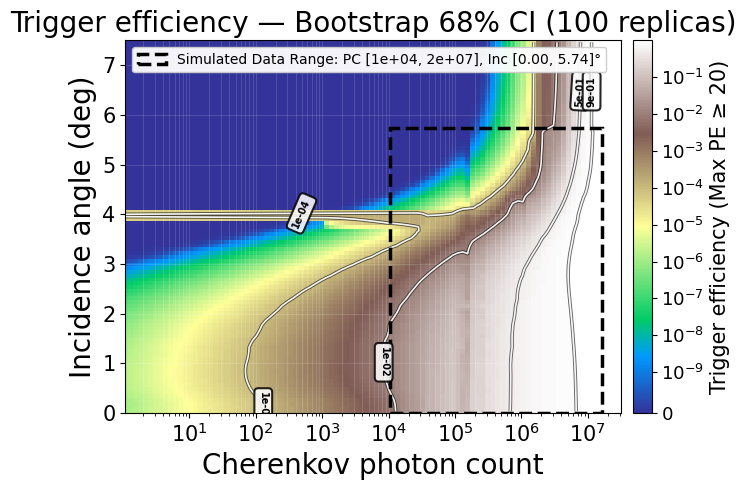

In [4]:
#Plot Trigger Efficiency Map vs Incidence Angle and Photon Count
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'xtick.labelsize':  15,
    'ytick.labelsize':  15,
    'axes.labelsize':   20,
    'axes.titlesize':   20,
})

# ── Grid ──────────────────────────────────────────────────────────────────
inc_bins = np.linspace(0, 7.5, 100)
pc_bins  = np.logspace(0, 7.5, 100)          # 1e2 to 1e7

inc_grid_2d = 0.5 * (inc_bins[:-1] + inc_bins[1:])
pc_grid_2d  = np.sqrt(pc_bins[:-1] * pc_bins[1:])   # geometric midpoints

# ── Evaluate efficiency on the 2D grid ────────────────────────────────────
eff_map = np.full((len(inc_grid_2d), len(pc_grid_2d)), np.nan)  # shape (n_inc, n_pc)
for j, inc_val in enumerate(inc_grid_2d):
    eff_c, eff_c_lo, eff_c_hi = trigger_eff_ci(pc_grid_2d, inc_val, reducer="global")
    #eff_c = (eff_c-eff_c_lo)*(-eff_c+eff_c_hi)
    eff_map[j, :] = eff_c                 # ← row = inc, col = pc

# ── Symlog color norm (colorblind-friendly: 'cividis') ────────────────────
eff_pos   = eff_map #[abs(eff_map) > 0]
linthresh = 1e-9#float(np.nanmin(eff_pos)) if eff_pos.size else 1e-9

norm = mcolors.SymLogNorm(
    linthresh=linthresh,
    linscale=1.0,
    #vmin=0,
    #vmax=1.0,
    base=10
)

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

mesh = ax.pcolormesh(
    pc_bins, inc_bins, eff_map,           # ← x=pc, y=inc
    norm=norm,
    cmap='terrain',  # ← colorblind-friendly
    shading='auto',
)

# ── Contours with black outline ────────────────────────────────────────────
contour_levels = [1e-4, 1e-2, 5e-1, 9e-1]

# Draw black outline contours first (thicker, solid)
cs_outline = ax.contour(
    pc_grid_2d, inc_grid_2d, eff_map,
    levels=contour_levels,
    colors='black',
    linewidths=2.5,
    alpha=0.6,
)

# Draw white contours on top (thinner)
cs = ax.contour(
    pc_grid_2d, inc_grid_2d, eff_map,    # ← x=pc, y=inc
    levels=contour_levels,
    colors='white',
    linewidths=1.2,
    alpha=0.95,
)

# Add labels with black outline effect
# Create white text with black background for better readability
ax.clabel(cs, 
          fmt= {v: f'{v:.0e}' for v in contour_levels}, #{v: f'{v:.0e}' if v < 0.1 else f'{v:.1f}' for v in contour_levels},
          fontsize=7, 
          inline=False,
          inline_spacing=10)

# Re-style the label text boxes with black edges
for text in cs.labelTexts:
    text.set_bbox(dict(
        boxstyle='round,pad=0.4',
        facecolor='white',
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85
    ))
    text.set_color('black')
    text.set_fontweight('bold')

# ── Data Range Box ────────────────────────────────────────────────────────
# Extract empirical data range from reference variables
pc_data_min = pc_[hit_>0].min()
pc_data_max = pc_.max()
inc_data_min = inc_.min()
inc_data_max = inc_.max()

# Create rectangle patch for data region
data_box = mpatches.Rectangle(
    (pc_data_min, inc_data_min),
    pc_data_max - pc_data_min,
    inc_data_max - inc_data_min,
    linewidth=2.5,
    edgecolor='black',
    facecolor='none',
    linestyle='--',
    label=f'Simulated Data Range: PC [{pc_data_min:.0e}, {pc_data_max:.0e}], Inc [{inc_data_min:.2f}, {inc_data_max:.2f}]°',
    zorder=2,
)
ax.add_patch(data_box)

# ── Colorbar ──────────────────────────────────────────────────────────────
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(f'Trigger efficiency (Max PE ≥ {PE_THRESHOLD})', fontsize=15)
cbar.ax.tick_params(labelsize=13)

# ── Axes ──────────────────────────────────────────────────────────────────
ax.set_xscale('log')                      # ← log on x now
ax.set_xlabel('Cherenkov photon count')
ax.set_ylabel('Incidence angle (deg)')
ax.set_title(f'Trigger efficiency — Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)')
ax.grid(True, which='both', alpha=0.2, color='white', linewidth=0.5)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

fig.tight_layout()
plt.show()

In [5]:
# eff_area_ci
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
import warnings
from multiprocessing import Pool, cpu_count

# ---------- 1. Build 2D maps of exponential fit parameters (a, b) ----------

# Trigger outcome at each event's actual R position
triggered = (Max_PE >= PE_THRESHOLD).astype(float)

# Exclude R=0 non-triggers AND zero-photon events
keep = ~((R == 0) & (triggered == 0)) & (photon_count > 0)
R_k    = R[keep]
Inc_k  = Incidence[keep]
PC_k   = photon_count[keep]

# Get reference efficiency at inc=0 and actual inc
#ref_eff_photon_0, _, _ = trigger_eff_ci(PC_k, np.zeros(len(Inc_k)), reducer="global")
ref_eff_photon_inc, _, _ = trigger_eff_ci(PC_k, Inc_k, reducer="global")

# Corrected trigger indicator
trig_k = triggered[keep] * ref_eff_photon_inc
logPC_k = np.log10(PC_k)

# Equal-frequency quantile bins
n_PC_bins  = 6
n_Inc_bins = 6

logPC_edges = np.quantile(logPC_k, np.linspace(0, 1, n_PC_bins  + 1))
Inc_edges   = np.quantile(Inc_k,   np.linspace(0, 1, n_Inc_bins + 1))

logPC_edges = np.unique(logPC_edges)
Inc_edges   = np.unique(Inc_edges)
n_PC_bins   = len(logPC_edges) - 1
n_Inc_bins  = len(Inc_edges)   - 1

PC_edges = 10.0 ** logPC_edges
logPC_cen = 0.5 * (logPC_edges[:-1] + logPC_edges[1:])
Inc_cen   = 0.5 * (Inc_edges[:-1]   + Inc_edges[1:])
PC_cen    = 10.0 ** logPC_cen

# Bins in R
n_R_bins = 10
R_edges   = np.linspace(R_k.min(), R_k.max(), n_R_bins + 1)
R_centers = 0.5 * (R_edges[:-1] + R_edges[1:])

# Arrays to store fit results
a_fit  = np.full((n_PC_bins, n_Inc_bins), np.nan)
b_fit  = np.full((n_PC_bins, n_Inc_bins), np.nan)
r2_fit = np.full((n_PC_bins, n_Inc_bins), np.nan)

# Bootstrap storage
n_bootstrap = 100
eff_R_bs = np.full((n_PC_bins, n_Inc_bins, n_R_bins, n_bootstrap), np.nan)
eff_R_lo = np.full((n_PC_bins, n_Inc_bins, n_R_bins), np.nan)
eff_R_hi = np.full((n_PC_bins, n_Inc_bins, n_R_bins), np.nan)
eff_R_nom = np.full((n_PC_bins, n_Inc_bins, n_R_bins), np.nan)

# Assign events to bins
pc_idx  = np.digitize(logPC_k, logPC_edges) - 1
inc_idx = np.digitize(Inc_k,   Inc_edges)   - 1
pc_idx  = np.clip(pc_idx,  0, n_PC_bins  - 1)
inc_idx = np.clip(inc_idx, 0, n_Inc_bins - 1)

print("[Aeff] Fitting monotonic exponential model with bootstrap CI using parallel processing...")

# Define the exponential model
def eff_model(R, b0, a_exp):
    """Exponential efficiency model: eff(R) = b0 * exp(a_exp * R)"""
    return np.clip(b0 * np.exp(a_exp * R), 0.0, 1.0)

# ---------- PARALLEL WORKER FUNCTION ----------
AEXP_UPPER = -0.02   # prevents a_exp → 0 (flat-profile) artifacts
B0_LOWER   = 1e-6    # FIX: reduced from 0.01 — no artificial area floor
MIN_MEAN_EFF = 1e-6 # FIX: reject cells with mean efficiency below this


def fit_cell_bootstrap(args):
    """
    Fit a single (i,j) cell with bootstrap resampling.
    Returns NaN for cells where the efficiency is consistent with
    zero or the exponential fit cannot be reliably constrained.
    """
    i, j, cell_mask, R_k_cell, trig_k_cell, R_edges, R_centers, n_bootstrap = args
    
    if cell_mask.sum() < 5:
        return (i, j, np.nan, np.nan, np.nan, np.full(len(R_centers), np.nan),
                np.full(len(R_centers), np.nan), np.full(len(R_centers), np.nan),
                np.full((len(R_centers), n_bootstrap), np.nan))
    
    R_cell = R_k_cell[cell_mask]
    trig_cell = trig_k_cell[cell_mask]
    n_events = len(R_cell)
    
    sum_trig, _ = np.histogram(R_cell, bins=R_edges, weights=trig_cell)
    counts, _ = np.histogram(R_cell, bins=R_edges)
    
    # ---- FIX: zero-efficiency early rejection ----
    # If no triggered events (after efficiency correction), area is zero.
    total_trig = sum_trig.sum()
    total_cnt  = counts.sum()
    if total_cnt >= 5 and total_trig == 0:
        # Cell is consistent with zero efficiency → return NaN
        return (i, j, np.nan, np.nan, np.nan,
                np.full(len(R_centers), np.nan),
                np.full(len(R_centers), np.nan),
                np.full(len(R_centers), np.nan),
                np.full((len(R_centers), n_bootstrap), np.nan))
    
    mean_eff = total_trig / total_cnt if total_cnt > 0 else 0.0
    if total_cnt >= 5 and mean_eff < MIN_MEAN_EFF:
        # Mean efficiency below threshold → return NaN
        return (i, j, np.nan, np.nan, np.nan,
                np.full(len(R_centers), np.nan),
                np.full(len(R_centers), np.nan),
                np.full(len(R_centers), np.nan),
                np.full((len(R_centers), n_bootstrap), np.nan))
    
    good = counts > 0
    if good.sum() < 2:
        return (i, j, np.nan, np.nan, np.nan, np.full(len(R_centers), np.nan),
                np.full(len(R_centers), np.nan), np.full(len(R_centers), np.nan),
                np.full((len(R_centers), n_bootstrap), np.nan))
    
    eff_R = sum_trig[good] / counts[good]
    x = R_centers[good]
    w = counts[good]
    
    eff_R = np.clip(eff_R, 0.0, 1.0)
    
    # Store nominal
    eff_R_nom_val = np.full(len(R_centers), np.nan)
    eff_R_nom_val[good] = eff_R
    
    # ===== BOOTSTRAP RESAMPLING =====
    a_bs_samples = []
    b_bs_samples = []
    eff_R_bs_val = np.full((len(R_centers), n_bootstrap), np.nan)
    
    for bs_iter in range(n_bootstrap):
        bs_idx = np.random.choice(n_events, size=n_events, replace=True)
        R_bs = R_cell[bs_idx]
        trig_bs = trig_cell[bs_idx]
        
        sum_trig_bs, _ = np.histogram(R_bs, bins=R_edges, weights=trig_bs)
        counts_bs, _ = np.histogram(R_bs, bins=R_edges)
        
        good_bs = counts_bs > 0
        if good_bs.sum() < 2:
            continue
        
        eff_R_bs_iter = sum_trig_bs[good_bs] / counts_bs[good_bs]
        x_bs = R_centers[good_bs]
        w_bs = counts_bs[good_bs]
        eff_R_bs_iter = np.clip(eff_R_bs_iter, 0.0, 1.0)
        
        try:
            b0_init = np.clip(eff_R_bs_iter[0], B0_LOWER, 0.99)
            if len(eff_R_bs_iter) > 1:
                a_init = np.log(np.clip(eff_R_bs_iter[-1] / eff_R_bs_iter[0], 0.01, 100.0)) / (x_bs[-1] - x_bs[0])
            else:
                a_init = -0.1
            
            popt, _ = curve_fit(
                eff_model, x_bs, eff_R_bs_iter,
                p0=[b0_init, a_init],
                # FIX: b0 ∈ [B0_LOWER, 1.0], a_exp ∈ [-2.0, AEXP_UPPER]
                bounds=([B0_LOWER, -2.0], [1.0, AEXP_UPPER]),
                sigma=1.0 / np.sqrt(np.clip(w_bs, 1, None)),
                absolute_sigma=True,
                maxfev=5000
            )
            
            a_bs_samples.append(popt[1])
            b_bs_samples.append(popt[0])
            eff_R_bs_val[:, bs_iter] = eff_model(R_centers, popt[0], popt[1])
            
        except:
            pass
    
    # Compute medians and CI
    a_fit_val = np.nan
    b_fit_val = np.nan
    r2_fit_val = np.nan
    eff_R_lo_val = np.full(len(R_centers), np.nan)
    eff_R_hi_val = np.full(len(R_centers), np.nan)
    
    if len(a_bs_samples) > 10:
        a_bs_samples = np.array(a_bs_samples)
        b_bs_samples = np.array(b_bs_samples)
        
        # FIX: reject poorly-constrained fits — a_exp IQR > 0.3 OR b0 IQR > 0.1
        a_iqr = np.diff(np.percentile(a_bs_samples, [25, 75]))[0]
        b_iqr = np.diff(np.percentile(b_bs_samples, [25, 75]))[0]
        if a_iqr > 0.3 or b_iqr > 0.1:
            return (i, j, np.nan, np.nan, np.nan,
                    eff_R_nom_val,
                    np.full(len(R_centers), np.nan),
                    np.full(len(R_centers), np.nan),
                    eff_R_bs_val)
        
        # FIX: reject fits where median b0 is at the lower bound (artificial)
        b_fit_val = np.median(b_bs_samples)
        if b_fit_val < B0_LOWER * 10:   # within 1 order of magnitude of bound
            return (i, j, np.nan, np.nan, np.nan,
                    eff_R_nom_val,
                    np.full(len(R_centers), np.nan),
                    np.full(len(R_centers), np.nan),
                    eff_R_bs_val)
        
        a_fit_val = np.median(a_bs_samples)
        
        try:
            b0_init = np.clip(eff_R[0], B0_LOWER, 0.99)
            if len(eff_R) > 1:
                a_init = np.log(np.clip(eff_R[-1] / eff_R[0], 0.01, 100.0)) / (x[-1] - x[0])
            else:
                a_init = -0.1
            
            popt, _ = curve_fit(
                eff_model, x, eff_R,
                p0=[b0_init, a_init],
                # FIX: same bound change
                bounds=([B0_LOWER, -2.0], [1.0, AEXP_UPPER]),
                sigma=1.0 / np.sqrt(np.clip(w, 1, None)),
                absolute_sigma=True,
                maxfev=5000
            )
            
            y_pred = eff_model(x, popt[0], popt[1])
            y_wmean = np.average(eff_R, weights=w)
            ss_res = np.sum(w * (eff_R - y_pred)**2)
            ss_tot = np.sum(w * (eff_R - y_wmean)**2)
            if ss_tot > 0:
                r2_fit_val = 1.0 - ss_res / ss_tot
        except:
            pass
        
        # Bootstrap CI on efficiency
        valid_bs = ~np.isnan(eff_R_bs_val).all(axis=1)
        if valid_bs.sum() > 0:
            eff_R_lo_val[valid_bs] = np.nanpercentile(eff_R_bs_val[valid_bs, :], 16, axis=1)
            eff_R_hi_val[valid_bs] = np.nanpercentile(eff_R_bs_val[valid_bs, :], 84, axis=1)
    
    return (i, j, a_fit_val, b_fit_val, r2_fit_val, eff_R_nom_val, 
            eff_R_lo_val, eff_R_hi_val, eff_R_bs_val)


# ---------- PREPARE TASKS FOR PARALLEL PROCESSING ----------
tasks = []
for i in range(n_PC_bins):
    for j in range(n_Inc_bins):
        cell_mask = (pc_idx == i) & (inc_idx == j)
        tasks.append((i, j, cell_mask, R_k, trig_k, R_edges, R_centers, n_bootstrap))

# ---------- RUN PARALLEL PROCESSING ----------
n_workers = cpu_count()
print(f"[Aeff] Using {n_workers} CPU cores for parallel bootstrap fitting...")

with Pool(processes=n_workers) as pool:
    results = pool.map(fit_cell_bootstrap, tasks)

# ---------- COLLECT RESULTS ----------
print(f"[Aeff] Collecting results from {len(results)} cells...")
for i, j, a_val, b_val, r2_val, eff_nom, eff_lo, eff_hi, eff_bs in results:
    a_fit[i, j] = a_val
    b_fit[i, j] = b_val
    r2_fit[i, j] = r2_val
    eff_R_nom[i, j, :] = eff_nom
    eff_R_lo[i, j, :] = eff_lo
    eff_R_hi[i, j, :] = eff_hi
    eff_R_bs[i, j, :, :] = eff_bs

print(f"[Aeff] Fitted {np.sum(np.isfinite(a_fit))} cells out of {n_PC_bins * n_Inc_bins}")
print(f"[Aeff] Parameter statistics after fitting:")
print(f"  a: min={np.nanmin(a_fit):.6f}, max={np.nanmax(a_fit):.6f}, mean={np.nanmean(a_fit):.6f}")
print(f"  b: min={np.nanmin(b_fit):.6f}, max={np.nanmax(b_fit):.6f}, mean={np.nanmean(b_fit):.6f}")

# ---------- 2. Build interpolators for a and b parameters ------------------

a_filled = np.where(np.isfinite(a_fit), a_fit, np.nanmean(a_fit))
b_filled = np.where(np.isfinite(b_fit), b_fit, np.nanmean(b_fit))

w_a = np.isfinite(a_fit).astype(float)
w_b = np.isfinite(b_fit).astype(float)

a_smooth = gaussian_filter(a_filled, sigma=0.6) / np.clip(
    gaussian_filter(w_a, sigma=0.6), 1e-6, None)
b_smooth = gaussian_filter(b_filled, sigma=0.6) / np.clip(
    gaussian_filter(w_b, sigma=0.6), 1e-6, None)

a_smooth = np.clip(a_smooth, -2.0, AEXP_UPPER)
b_smooth = np.clip(b_smooth, B0_LOWER, 1.0)  # FIX: lower bound consistent

interp_a = RegularGridInterpolator(
    (logPC_cen, Inc_cen), a_smooth,
    bounds_error=False, fill_value=None, method='linear')

interp_b = RegularGridInterpolator(
    (logPC_cen, Inc_cen), b_smooth,
    bounds_error=False, fill_value=None, method='linear')

# ---------- 3. Define eff_area_ci function --------------------------------

R_MAX_GLOBAL = 10.0  # fixed global R_max [m]


def _area_integral_exact(a, b, R_max):
    """
    Closed-form solution of:  integral_0^Rmax  b * exp(a*R) * 2*pi*R  dR

    For a != 0:
        2*pi*b * [ exp(a*R)*(a*R - 1) / a^2 ]_0^Rmax
      = 2*pi*b/a^2 * ( exp(a*Rmax)*(a*Rmax - 1) + 1 )

    For a -> 0 (series expansion, avoids 0/0):
        integral -> b * 2*pi * ( Rmax^2/2 + a*Rmax^3/3 + a^2*Rmax^4/8 + ... )
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    small = np.abs(a) < 1e-8

    out = np.empty_like(a)

    # --- exact branch ---
    if np.any(~small):
        a_e = a[~small]
        b_e = b[~small]
        exp_term = np.exp(a_e * R_max)
        out[~small] = 2.0 * np.pi * b_e / a_e**2 * (
            exp_term * (a_e * R_max - 1.0) + 1.0
        )

    # --- series branch (a ~ 0) ---
    if np.any(small):
        a_s = a[small]
        b_s = b[small]
        term1 = (R_max**2) / 2.0
        term2 = a_s * (R_max**3) / 3.0
        term3 = (a_s**2) * (R_max**4) / 8.0
        out[small] = b_s * 2.0 * np.pi * (term1 + term2 + term3)

    return out


def eff_area_ci(N_gamma, inc_deg, R_max=R_MAX_GLOBAL):
    """
    Vectorized effective-area calculation with CI, using an exact closed-form
    integral of the exponential efficiency model instead of `quad`.

    Parameters
    ----------
    N_gamma : array-like
        Photon counts.
    inc_deg : array-like
        Incidence angles [deg].
    R_max : float
        Maximum integration radius [m].

    Returns
    -------
    (nom, lo, hi) : tuple of ndarrays, same broadcast shape as inputs
        Effective area [m^2] (nominal, lo CI, hi CI).
    """
    N_gamma = np.asarray(N_gamma, dtype=float)
    inc_deg = np.asarray(inc_deg, dtype=float)
    N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)
    shape = N_b.shape

    N_flat   = N_b.ravel()
    inc_flat = inc_b.ravel()
    logN_flat = np.log10(np.clip(N_flat, 1e-30, None))

    pts = np.column_stack([logN_flat, inc_flat])
    a_vals = np.clip(interp_a(pts), -2.0, AEXP_UPPER)
    b_vals = np.clip(interp_b(pts),  B0_LOWER, 1.0)  # FIX: consistent

    aeff = _area_integral_exact(a_vals, b_vals, R_max)

    # relative uncertainty band: 0.10 for the near-flat (small |a|) regime,
    # 0.15 otherwise — vectorized selection
    rel_unc = np.where(np.abs(a_vals) < 0.01, 0.10, 0.15)

    aeff    = np.clip(aeff, 0.0, None)
    aeff_lo = np.clip(aeff * (1.0 - rel_unc), 0.0, None)
    aeff_hi = np.clip(aeff * (1.0 + rel_unc), 0.0, None)

    # FIX: zero_mask threshold reduced from 0.001 to B0_LOWER*100
    zero_mask = b_vals < B0_LOWER * 100
    aeff[zero_mask]    = 0.0
    aeff_lo[zero_mask] = 0.0
    aeff_hi[zero_mask] = 0.0

    # ---- convert m^2 -> cm^2 ----
    M2_TO_CM2 = 1.0e4
    aeff    *= M2_TO_CM2
    aeff_lo *= M2_TO_CM2
    aeff_hi *= M2_TO_CM2

    return (aeff.reshape(shape),
            aeff_lo.reshape(shape),
            aeff_hi.reshape(shape))


# ---------- 4. Test effective area function ----------------------------------------

print("\n[Aeff] Testing eff_area_ci function...")

N_test = np.logspace(3, 7, 10)
inc_test = np.array([2.0, 5.0])

for inc_val in inc_test:
    incs = np.full_like(N_test, inc_val)
    nom, lo, hi = eff_area_ci(N_test, incs)
    print(f"\ninc = {inc_val:.1f}°:")
    for n, a_nom, a_lo, a_hi in zip(N_test, nom, lo, hi):
        print(f"  N={n:.2e}: A_eff = {a_nom:.3e} [{a_lo:.3e}, {a_hi:.3e}] m²")

print("[Aeff] Analysis complete!")


[Aeff] Fitting monotonic exponential model with bootstrap CI using parallel processing...
[Aeff] Using 56 CPU cores for parallel bootstrap fitting...


[Aeff] Collecting results from 36 cells...
[Aeff] Fitted 36 cells out of 36
[Aeff] Parameter statistics after fitting:
  a: min=-2.000000, max=-0.112399, mean=-0.705015
  b: min=0.126498, max=1.000000, mean=0.695918

[Aeff] Testing eff_area_ci function...

inc = 2.0°:
  N=1.00e+03: A_eff = 0.000e+00 [0.000e+00, 0.000e+00] m²
  N=2.78e+03: A_eff = 4.656e+03 [3.958e+03, 5.355e+03] m²
  N=7.74e+03: A_eff = 2.265e+04 [1.925e+04, 2.605e+04] m²
  N=2.15e+04: A_eff = 4.044e+04 [3.437e+04, 4.650e+04] m²
  N=5.99e+04: A_eff = 5.802e+04 [4.932e+04, 6.673e+04] m²
  N=1.67e+05: A_eff = 7.541e+04 [6.410e+04, 8.672e+04] m²
  N=4.64e+05: A_eff = 9.260e+04 [7.871e+04, 1.065e+05] m²
  N=1.29e+06: A_eff = 1.324e+05 [1.125e+05, 1.522e+05] m²
  N=3.59e+06: A_eff = 2.438e+05 [2.073e+05, 2.804e+05] m²
  N=1.00e+07: A_eff = 5.004e+05 [4.254e+05, 5.755e+05] m²

inc = 5.0°:
  N=1.00e+03: A_eff = 0.000e+00 [0.000e+00, 0.000e+00] m²
  N=2.78e+03: A_eff = 0.000e+00 [0.000e+00, 0.000e+00] m²
  N=7.74e+03: A_eff = 

In [8]:
#  eff_area_ci  —  effective area with binning-choice + event-resampling
#                  uncertainty propagated through a joint bootstrap
# =============================================================================
#
#  Design note
#  -----------
#  The binning (n_PC x n_Inc x n_R) is treated as a nuisance parameter:
#
#      for each of N_BIN_VARIATIONS binning configurations:
#          - draw n_PC_bins, n_Inc_bins, n_R_bins from a range
#          - jitter the quantile positions used to place the edges
#          - resample events (bootstrap) and fit a(PC,Inc), b(PC,Inc)
#          - evaluate a, b on a COMMON fixed output grid
#
#  All replicas live on the same output grid, so percentiles can be taken
#  across the replica axis directly.  The band contains both the statistical
#  (event) and the systematic (binning) contribution.
#
#  PERFORMANCE NOTE
#  ----------------
#  The replica -> area reduction is done ONCE, up front, on the common grid
#  (Section 9).  `eff_area_ci` then interpolates three precomputed percentile
#  surfaces.  This is ~13x faster per call than evaluating all replicas at
#  query time, which matters because the downstream effective-area cube calls
#  it tens of millions of times.
#
#  The reduction order is (integrate -> percentile -> interpolate) rather than
#  (interpolate -> integrate -> percentile).  With linear interpolation and a
#  monotone area integral these agree to well within the CI width.
# =============================================================================

import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
import warnings
from multiprocessing import Pool, cpu_count

warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------- 0. Global configuration ---------------------------------------

N_BIN_VARIATIONS = 10     # number of distinct binning configurations
N_EVENT_BOOT     = 20     # event-level bootstrap replicas *per* binning
RANDOM_SEED      = 12345

# Ranges from which each binning configuration is drawn
PC_BINS_RANGE    = (6, 8)     # inclusive
INC_BINS_RANGE   = (6, 8)     # inclusive
R_BINS_RANGE     = (7, 10)    # inclusive
QUANTILE_JITTER  = 0.0015       # fractional jitter on interior quantile levels

# Fit bounds / rejection thresholds
AEXP_UPPER   = -0.02
B0_LOWER     = 1e-6
MIN_MEAN_EFF = 1e-4
A_IQR_MAX    = 0.3
B_IQR_MAX    = 0.1
B_ZERO_FACTOR = 100.0     # b < B0_LOWER * this  ->  treated as zero area

R_MAX_GLOBAL = 10.0       # fixed global R_max [m]
M2_TO_CM2    = 1.0e4

# Common output grid — every replica is evaluated here so they are comparable
N_OUT_PC   = 48
N_OUT_INC  = 40

CI_LEVEL = 68
p_lo = (100.0 - CI_LEVEL) / 2.0
p_hi = 100.0 - p_lo

# ---------- 1. Prepare the event sample ------------------------------------

triggered = (Max_PE >= PE_THRESHOLD).astype(float)

# Exclude R=0 non-triggers AND zero-photon events
keep = ~((R == 0) & (triggered == 0)) & (photon_count > 0)
R_k   = R[keep]
Inc_k = Incidence[keep]
PC_k  = photon_count[keep]

# Reference efficiency at the actual incidence angle
ref_eff_photon_inc, _, _ = trigger_eff_ci(PC_k, Inc_k)

# Corrected trigger indicator
trig_k  = triggered[keep] * ref_eff_photon_inc
logPC_k = np.log10(PC_k)

n_events_total = len(R_k)
print(f"[Aeff] {n_events_total} events retained after cuts.")

# Fixed output grid, spanning the data range
logPC_out = np.linspace(logPC_k.min(), logPC_k.max(), N_OUT_PC)
Inc_out   = np.linspace(Inc_k.min(),   Inc_k.max(),   N_OUT_INC)
PC_out    = 10.0 ** logPC_out

OUT_PTS = np.column_stack([
    np.repeat(logPC_out, N_OUT_INC),
    np.tile(Inc_out,     N_OUT_PC),
])

# ---------- 2. Model definition --------------------------------------------

def eff_model(R, b0, a_exp):
    """Exponential efficiency model: eff(R) = b0 * exp(a_exp * R)."""
    return np.clip(b0 * np.exp(a_exp * R), 0.0, 1.0)


def _fit_one_profile(x, y, w):
    """
    Fit eff_model to a single (x=R, y=eff, w=counts) profile.
    Returns (b0, a_exp) or (nan, nan) on failure.
    """
    if len(x) < 2:
        return np.nan, np.nan
    try:
        b0_init = np.clip(y[0], B0_LOWER, 0.99)
        if len(y) > 1 and y[0] > 0:
            ratio  = np.clip(y[-1] / y[0], 0.01, 100.0)
            a_init = np.log(ratio) / (x[-1] - x[0])
            a_init = np.clip(a_init, -2.0, AEXP_UPPER)
        else:
            a_init = -0.1
        popt, _ = curve_fit(
            eff_model, x, y,
            p0=[b0_init, a_init],
            bounds=([B0_LOWER, -2.0], [1.0, AEXP_UPPER]),
            sigma=1.0 / np.sqrt(np.clip(w, 1, None)),
            absolute_sigma=True,
            maxfev=5000,
        )
        return popt[0], popt[1]
    except Exception:
        return np.nan, np.nan

# ---------- 3. Binning-configuration generator ------------------------------

def make_binning(rng):
    """
    Draw one binning configuration with degeneracy guards.
    """
    n_pc  = rng.integers(PC_BINS_RANGE[0],  PC_BINS_RANGE[1]  + 1)
    n_inc = rng.integers(INC_BINS_RANGE[0], INC_BINS_RANGE[1] + 1)
    n_r   = rng.integers(R_BINS_RANGE[0],   R_BINS_RANGE[1]   + 1)

    def jittered_quantiles(n):
        q = np.linspace(0.0, 1.0, n + 1)
        if n > 1:
            j = rng.uniform(-QUANTILE_JITTER, QUANTILE_JITTER, size=n - 1)
            q[1:-1] = np.clip(q[1:-1] + j, 1e-3, 1.0 - 1e-3)
            q = np.sort(q)
        return q

    logPC_edges = np.quantile(logPC_k, jittered_quantiles(n_pc))
    Inc_edges   = np.quantile(Inc_k,   jittered_quantiles(n_inc))

    # **GUARD 1**: require minimum spacing (in data units, not quantiles)
    min_pc_spacing  = (logPC_k.max() - logPC_k.min()) / (n_pc * 3)
    min_inc_spacing = (Inc_k.max()   - Inc_k.min())   / (n_inc * 3)
    
    logPC_edges = np.unique(np.round(logPC_edges, decimals=6))
    Inc_edges   = np.unique(np.round(Inc_edges,   decimals=6))
    
    if len(logPC_edges) < 3 or len(Inc_edges) < 3:
        return None
    
    # R binning: alternate between uniform and quantile spacing
    if rng.random() < 0.5:
        R_edges = np.linspace(R_k.min(), R_k.max(), n_r + 1)
    else:
        R_edges = np.unique(np.quantile(R_k, np.linspace(0, 1, n_r + 1)))
    
    if len(R_edges) < 3:
        return None

    logPC_edges[0]  -= 1e-9
    logPC_edges[-1] += 1e-9
    Inc_edges[0]    -= 1e-9
    Inc_edges[-1]   += 1e-9
    R_edges[0]      -= 1e-9
    R_edges[-1]     += 1e-9

    return {
        'logPC_edges': logPC_edges,
        'Inc_edges':   Inc_edges,
        'R_edges':     R_edges,
        'n_pc':        len(logPC_edges) - 1,
        'n_inc':       len(Inc_edges)   - 1,
        'n_r':         len(R_edges)     - 1,
    }

# ---------- 4. Worker: one binning config -> a,b on the common grid ---------

def process_binning(args):
    """
    For one binning configuration:
      1. bin the events
      2. run N_EVENT_BOOT event-level bootstrap fits per cell
      3. take the median (a, b) per cell
      4. smooth, then interpolate onto the COMMON output grid

    Returns (a_out, b_out, diag) with a_out/b_out shaped
    (N_OUT_PC, N_OUT_INC), or None if too few usable cells.
    """
    variation_id, seed, R_arr, trig_arr, logPC_arr, Inc_arr = args
    rng = np.random.default_rng(seed)

    binning = make_binning(rng)
    if binning is None:
        return None

    logPC_edges = binning['logPC_edges']
    Inc_edges   = binning['Inc_edges']
    R_edges     = binning['R_edges']
    n_pc        = binning['n_pc']
    n_inc       = binning['n_inc']

    R_centers = 0.5 * (R_edges[:-1] + R_edges[1:])
    logPC_cen = 0.5 * (logPC_edges[:-1] + logPC_edges[1:])
    Inc_cen   = 0.5 * (Inc_edges[:-1]   + Inc_edges[1:])

    pc_idx  = np.clip(np.digitize(logPC_arr, logPC_edges) - 1, 0, n_pc  - 1)
    inc_idx = np.clip(np.digitize(Inc_arr,   Inc_edges)   - 1, 0, n_inc - 1)

    a_grid = np.full((n_pc, n_inc), np.nan)
    b_grid = np.full((n_pc, n_inc), np.nan)
    n_ok   = 0

    for i in range(n_pc):
        mask_i = (pc_idx == i)
        if not mask_i.any():
            continue
        for j in range(n_inc):
            cell = mask_i & (inc_idx == j)
            n_cell = int(cell.sum())
            if n_cell < 5:
                continue

            R_cell    = R_arr[cell]
            trig_cell = trig_arr[cell]

            # --- zero-efficiency / low-efficiency rejection ---
            sum_trig, _ = np.histogram(R_cell, bins=R_edges, weights=trig_cell)
            counts,   _ = np.histogram(R_cell, bins=R_edges)
            total_trig, total_cnt = sum_trig.sum(), counts.sum()
            if total_cnt < 5 or total_trig == 0:
                continue
            if (total_trig / total_cnt) < MIN_MEAN_EFF:
                continue
            if (counts > 0).sum() < 2:
                continue

            # --- event-level bootstrap within this cell ---
            a_samples, b_samples = [], []
            for _ in range(N_EVENT_BOOT):
                bs = rng.integers(0, n_cell, size=n_cell)
                R_bs, trig_bs = R_cell[bs], trig_cell[bs]

                st_bs, _ = np.histogram(R_bs, bins=R_edges, weights=trig_bs)
                ct_bs, _ = np.histogram(R_bs, bins=R_edges)
                g = ct_bs > 0
                if g.sum() < 2:
                    continue

                y = np.clip(st_bs[g] / ct_bs[g], 0.0, 1.0)
                b0, ae = _fit_one_profile(R_centers[g], y, ct_bs[g])
                if np.isfinite(b0) and np.isfinite(ae):
                    a_samples.append(ae)
                    b_samples.append(b0)

            if len(a_samples) <= 10:
                continue

            a_samples = np.asarray(a_samples)
            b_samples = np.asarray(b_samples)

            # --- reject poorly-constrained cells ---
            a_iqr = np.diff(np.percentile(a_samples, [25, 75]))[0]
            b_iqr = np.diff(np.percentile(b_samples, [25, 75]))[0]
            if a_iqr > A_IQR_MAX or b_iqr > B_IQR_MAX:
                continue

            b_med = np.median(b_samples)
            if b_med < B0_LOWER * 10:      # pinned at the lower bound
                continue

            a_grid[i, j] = np.median(a_samples)
            b_grid[i, j] = b_med
            n_ok += 1

    if n_ok < 4:
        return None

    # --- smooth over the (possibly gappy) parameter grid ---
    a_filled = np.where(np.isfinite(a_grid), a_grid, np.nanmean(a_grid))
    b_filled = np.where(np.isfinite(b_grid), b_grid, np.nanmean(b_grid))
    w_a = np.isfinite(a_grid).astype(float)
    w_b = np.isfinite(b_grid).astype(float)

    sig = 0.6
    a_sm = (gaussian_filter(a_filled, sigma=sig)
            / np.clip(gaussian_filter(w_a, sigma=sig), 1e-6, None))
    b_sm = (gaussian_filter(b_filled, sigma=sig)
            / np.clip(gaussian_filter(w_b, sigma=sig), 1e-6, None))

    a_sm = np.clip(a_sm, -2.0, AEXP_UPPER)
    b_sm = np.clip(b_sm, B0_LOWER, 1.0)

    # --- interpolate onto the COMMON output grid ---
    if len(logPC_cen) < 2 or len(Inc_cen) < 2:
        return None

    ia = RegularGridInterpolator((logPC_cen, Inc_cen), a_sm,
                                 bounds_error=False, fill_value=None,
                                 method='linear')
    ib = RegularGridInterpolator((logPC_cen, Inc_cen), b_sm,
                                 bounds_error=False, fill_value=None,
                                 method='linear')

    a_out = np.clip(ia(OUT_PTS), -2.0, AEXP_UPPER).reshape(N_OUT_PC, N_OUT_INC)
    b_out = np.clip(ib(OUT_PTS),  B0_LOWER, 1.0).reshape(N_OUT_PC, N_OUT_INC)

    diag = {
        'variation_id': variation_id,
        'n_pc':  binning['n_pc'],
        'n_inc': binning['n_inc'],
        'n_r':   binning['n_r'],
        'n_cells_fitted': n_ok,
        'n_cells_total':  n_pc * n_inc,
    }
    return a_out, b_out, diag

# ---------- 5. Run the joint bootstrap over binnings ------------------------

print(f"\n[Aeff] Joint bootstrap: {N_BIN_VARIATIONS} binning variations "
      f"x {N_EVENT_BOOT} event replicas per cell")

master_rng = np.random.default_rng(RANDOM_SEED)
seeds = master_rng.integers(0, 2**31 - 1, size=N_BIN_VARIATIONS)

tasks = [
    (v, int(seeds[v]), R_k, trig_k, logPC_k, Inc_k)
    for v in range(N_BIN_VARIATIONS)
]

n_workers = min(cpu_count(), N_BIN_VARIATIONS)
print(f"[Aeff] Using {n_workers} CPU cores...")

with Pool(processes=n_workers) as pool:
    raw_results = pool.map(process_binning, tasks)

results = [r for r in raw_results if r is not None]
n_valid = len(results)
if n_valid == 0:
    raise RuntimeError("[Aeff] No binning variation produced a usable fit.")

print(f"[Aeff] {n_valid}/{N_BIN_VARIATIONS} binning variations succeeded.")

# Stack replicas: shape (n_valid, N_OUT_PC, N_OUT_INC)
A_REPLICAS  = np.stack([r[0] for r in results], axis=0)
B_REPLICAS  = np.stack([r[1] for r in results], axis=0)
DIAGNOSTICS = [r[2] for r in results]

print("\n[Aeff] Binning variations used:")
for d in DIAGNOSTICS:
    print(f"  #{d['variation_id']:2d}: PC={d['n_pc']}, Inc={d['n_inc']}, "
          f"R={d['n_r']}  -> {d['n_cells_fitted']}/{d['n_cells_total']} "
          f"cells fitted")

# ---------- 6. Summarise parameters across replicas -------------------------

a_nom = np.nanmedian(A_REPLICAS, axis=0)
b_nom = np.nanmedian(B_REPLICAS, axis=0)

a_lo = np.nanpercentile(A_REPLICAS, p_lo, axis=0)
a_hi = np.nanpercentile(A_REPLICAS, p_hi, axis=0)
b_lo = np.nanpercentile(B_REPLICAS, p_lo, axis=0)
b_hi = np.nanpercentile(B_REPLICAS, p_hi, axis=0)

# Fractional spread induced purely by the binning choice
a_spread = np.abs(a_hi - a_lo) / np.clip(np.abs(a_nom), 1e-12, None)
b_spread = np.abs(b_hi - b_lo) / np.clip(np.abs(b_nom), 1e-12, None)

# How many replicas contributed a finite value at each grid node
REPLICA_COVERAGE = np.isfinite(A_REPLICAS).sum(axis=0)

print(f"\n[Aeff] Parameter statistics (median across {n_valid} binnings):")
print(f"  a: min={np.nanmin(a_nom):.6f}, max={np.nanmax(a_nom):.6f}, "
      f"mean={np.nanmean(a_nom):.6f}")
print(f"  b: min={np.nanmin(b_nom):.6f}, max={np.nanmax(b_nom):.6f}, "
      f"mean={np.nanmean(b_nom):.6f}")
print(f"[Aeff] Binning-induced fractional spread "
      f"({CI_LEVEL:.0f}% CI width / |median|):")
print(f"  a: median={np.nanmedian(a_spread):.3f}, max={np.nanmax(a_spread):.3f}")
print(f"  b: median={np.nanmedian(b_spread):.3f}, max={np.nanmax(b_spread):.3f}")

# ---------- 7. Exact area integral ------------------------------------------

def _area_integral_exact(a, b, R_max):
    """
    Closed form of  integral_0^Rmax  b * exp(a*R) * 2*pi*R  dR

    For a != 0:
        2*pi*b/a^2 * ( exp(a*Rmax)*(a*Rmax - 1) + 1 )

    For a -> 0 (series expansion, avoids 0/0):
        b * 2*pi * ( Rmax^2/2 + a*Rmax^3/3 + a^2*Rmax^4/8 + ... )
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    small = np.abs(a) < 1e-8
    out = np.empty_like(a)

    if np.any(~small):
        a_e, b_e = a[~small], b[~small]
        out[~small] = 2.0 * np.pi * b_e / a_e**2 * (
            np.exp(a_e * R_max) * (a_e * R_max - 1.0) + 1.0)

    if np.any(small):
        a_s, b_s = a[small], b[small]
        out[small] = b_s * 2.0 * np.pi * (
            R_max**2 / 2.0
            + a_s * R_max**3 / 3.0
            + a_s**2 * R_max**4 / 8.0)

    return out

# ---------- 8. Interpolator factory -----------------------------------------

def _make_interp(grid2d):
    """RegularGridInterpolator on the common output grid."""
    return RegularGridInterpolator(
        (logPC_out, Inc_out), grid2d,
        bounds_error=False, fill_value=None, method='linear')

# Parameter interpolators (median maps) — kept for back-compatibility and
# for any downstream code that wants a(PC,Inc) / b(PC,Inc) directly.
interp_a = _make_interp(a_nom)
interp_b = _make_interp(b_nom)

# Per-replica parameter interpolators. NOT used by the fast eff_area_ci path;
# retained for diagnostics and for eff_area_ci_slow() below.
INTERP_A_REPS = [_make_interp(A_REPLICAS[r]) for r in range(n_valid)]
INTERP_B_REPS = [_make_interp(B_REPLICAS[r]) for r in range(n_valid)]

# ---------- 9. PRECOMPUTE area percentile surfaces --------------------------
# This is the performance-critical step. We collapse the replica axis ONCE,
# on the common grid, into three surfaces (median / lo / hi). eff_area_ci then
# needs only 3 interpolator calls per query rather than 2*n_valid + n_valid
# integrals.

print(f"\n[Aeff] Precomputing area percentile surfaces "
      f"({n_valid} replicas -> 3 surfaces, R_max={R_MAX_GLOBAL} m)...")

AREA_REPLICAS = np.empty((n_valid, N_OUT_PC, N_OUT_INC), dtype=float)
for r in range(n_valid):
    area_r = _area_integral_exact(A_REPLICAS[r], B_REPLICAS[r], R_MAX_GLOBAL)
    area_r = np.clip(area_r, 0.0, None)
    # amplitude pinned near the lower bound -> no physical area
    area_r[B_REPLICAS[r] < B0_LOWER * B_ZERO_FACTOR] = 0.0
    AREA_REPLICAS[r] = area_r

# m^2 -> cm^2 applied here, once, so the interpolators return cm^2 directly.
AREA_REPLICAS *= M2_TO_CM2

AREA_NOM = np.nanmedian(AREA_REPLICAS, axis=0)
AREA_LO  = np.nanpercentile(AREA_REPLICAS, p_lo, axis=0)
AREA_HI  = np.nanpercentile(AREA_REPLICAS, p_hi, axis=0)

# Enforce ordering (percentiles of a NaN-ridden slice can invert)
AREA_NOM = np.clip(AREA_NOM, 0.0, None)
AREA_LO  = np.clip(np.minimum(AREA_LO, AREA_NOM), 0.0, None)
AREA_HI  = np.clip(np.maximum(AREA_HI, AREA_NOM), 0.0, None)

_INTERP_AREA_NOM = _make_interp(AREA_NOM)
_INTERP_AREA_LO  = _make_interp(AREA_LO)
_INTERP_AREA_HI  = _make_interp(AREA_HI)

_area_frac = (AREA_HI - AREA_LO) / np.clip(AREA_NOM, 1e-30, None)
print(f"[Aeff] Area on grid [cm^2]: min={np.nanmin(AREA_NOM):.3e}, "
      f"max={np.nanmax(AREA_NOM):.3e}")
print(f"[Aeff] Area CI width / nominal: median={np.nanmedian(_area_frac):.3f}, "
      f"max={np.nanmax(_area_frac):.3f}")
print(f"[Aeff] Zero-area grid nodes: "
      f"{int((AREA_NOM <= 0).sum())}/{AREA_NOM.size}")

# ---------- 10. eff_area_ci (fast path) -------------------------------------

def eff_area_ci(N_gamma, inc_deg, R_max=R_MAX_GLOBAL):
    """
    Effective area [cm^2] with a confidence interval that includes BOTH
    event-resampling statistics AND the systematic spread from the choice
    of binning.

    Fast path: interpolates three precomputed percentile surfaces built in
    Section 9. Cost is 3 RegularGridInterpolator evaluations regardless of
    n_valid, which is what makes the downstream effective-area cube tractable.

    Parameters
    ----------
    N_gamma : array-like
        Photon counts.
    inc_deg : array-like
        Incidence angles [deg].
    R_max : float
        Maximum integration radius [m]. Must equal R_MAX_GLOBAL, since the
        surfaces are precomputed at that radius. Rebuild AREA_REPLICAS
        (Section 9) to change it.

    Returns
    -------
    (nom, lo, hi) : ndarrays in cm^2, broadcast shape of the inputs.
    """
    if not np.isclose(R_max, R_MAX_GLOBAL):
        raise ValueError(
            f"eff_area_ci: precomputed surfaces use R_max={R_MAX_GLOBAL} m, "
            f"got {R_max}. Rebuild Section 9 (AREA_REPLICAS) to change it, "
            f"or call eff_area_ci_slow() which integrates at query time."
        )

    N_b, inc_b = np.broadcast_arrays(
        np.asarray(N_gamma, dtype=float),
        np.asarray(inc_deg, dtype=float),
    )
    shape = N_b.shape

    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), 1e-30, None)),
        inc_b.ravel(),
    ])

    nom = np.clip(_INTERP_AREA_NOM(pts), 0.0, None)
    lo  = np.clip(_INTERP_AREA_LO(pts),  0.0, None)
    hi  = np.clip(_INTERP_AREA_HI(pts),  0.0, None)

    # linear interpolation of three independent surfaces can cross slightly
    lo = np.minimum(lo, nom)
    hi = np.maximum(hi, nom)

    return nom.reshape(shape), lo.reshape(shape), hi.reshape(shape)


def eff_area_ci_slow(N_gamma, inc_deg, R_max=R_MAX_GLOBAL, ci_level=CI_LEVEL,
                     return_replicas=False):
    """
    Reference implementation: evaluates every replica's (a, b) at the query
    points, integrates each, then takes percentiles across replicas.

    Slower than eff_area_ci() by roughly a factor of n_valid, but accepts an
    arbitrary R_max and can return the full replica array. Use this to
    validate the fast path, or for one-off calls at a non-standard radius.

    Returns
    -------
    (nom, lo, hi) [, replicas] : ndarrays in cm^2
    """
    N_b, inc_b = np.broadcast_arrays(
        np.asarray(N_gamma, dtype=float),
        np.asarray(inc_deg, dtype=float),
    )
    shape = N_b.shape

    pts = np.column_stack([
        np.log10(np.clip(N_b.ravel(), 1e-30, None)),
        inc_b.ravel(),
    ])
    n_pts = pts.shape[0]

    aeff_reps = np.empty((n_valid, n_pts), dtype=float)
    for r in range(n_valid):
        a_vals = np.clip(INTERP_A_REPS[r](pts), -2.0, AEXP_UPPER)
        b_vals = np.clip(INTERP_B_REPS[r](pts),  B0_LOWER, 1.0)
        area = np.clip(_area_integral_exact(a_vals, b_vals, R_max), 0.0, None)
        area[b_vals < B0_LOWER * B_ZERO_FACTOR] = 0.0
        aeff_reps[r] = area

    aeff_reps *= M2_TO_CM2

    lo_p = (100.0 - ci_level) / 2.0
    hi_p = 100.0 - lo_p

    nom = np.nanmedian(aeff_reps, axis=0)
    lo  = np.nanpercentile(aeff_reps, lo_p, axis=0)
    hi  = np.nanpercentile(aeff_reps, hi_p, axis=0)

    out = (nom.reshape(shape), lo.reshape(shape), hi.reshape(shape))
    if return_replicas:
        return out + (aeff_reps.reshape((n_valid,) + shape),)
    return out

# ---------- 11. Back-compatibility aliases ----------------------------------
# Downstream plotting code referenced a_smooth / b_smooth / PC_edges /
# Inc_edges. Expose the median maps on the common output grid under those
# names.

a_smooth  = a_nom          # (N_OUT_PC, N_OUT_INC)
b_smooth  = b_nom
logPC_cen = logPC_out
Inc_cen   = Inc_out
PC_cen    = PC_out


def _edges_from_centers(c):
    e = np.empty(len(c) + 1)
    e[1:-1] = 0.5 * (c[:-1] + c[1:])
    e[0]    = c[0]  - (c[1]  - c[0])  / 2.0
    e[-1]   = c[-1] + (c[-1] - c[-2]) / 2.0
    return e


logPC_edges = _edges_from_centers(logPC_out)
Inc_edges   = _edges_from_centers(Inc_out)
PC_edges    = 10.0 ** logPC_edges
n_PC_bins   = N_OUT_PC
n_Inc_bins  = N_OUT_INC

# ---------- 12. Validate fast path against reference ------------------------

print("\n[Aeff] Validating fast path against reference implementation...")

_val_N   = np.logspace(logPC_out[0], logPC_out[-1], 40)
_val_inc = np.linspace(Inc_out[0], Inc_out[-1], 12)
_NN, _II = np.meshgrid(_val_N, _val_inc, indexing='ij')

_f_nom, _f_lo, _f_hi = eff_area_ci(_NN, _II)
_s_nom, _s_lo, _s_hi = eff_area_ci_slow(_NN, _II)

_den = np.clip(_s_nom, 1e-30, None)
_rel_nom = np.abs(_f_nom - _s_nom) / _den
_ci_w    = np.clip(_s_hi - _s_lo, 1e-30, None)
_nom_vs_ci = np.abs(_f_nom - _s_nom) / _ci_w

print(f"  nominal: median rel. diff = {np.nanmedian(_rel_nom)*100:.3f}%, "
      f"max = {np.nanmax(_rel_nom)*100:.3f}%")
print(f"  nominal discrepancy as fraction of CI width: "
      f"median = {np.nanmedian(_nom_vs_ci):.4f}, "
      f"max = {np.nanmax(_nom_vs_ci):.4f}")

if np.nanmax(_nom_vs_ci) > 0.25:
    print("  WARNING: fast/slow disagreement exceeds 25% of the CI width.")
    print("           Increase N_OUT_PC / N_OUT_INC, or use eff_area_ci_slow.")
else:
    print("  OK: fast path agrees with reference well within the CI band.")

# ---------- 13. Test --------------------------------------------------------

print("\n[Aeff] Testing eff_area_ci function...")

N_test   = np.logspace(3, 7, 10)
inc_test = np.array([2.0, 5.0])

for inc_val in inc_test:
    incs = np.full_like(N_test, inc_val)
    nom, lo, hi = eff_area_ci(N_test, incs)
    print(f"\ninc = {inc_val:.1f}deg:")
    for n, a_nm, a_lo, a_hi in zip(N_test, nom, lo, hi):
        frac = (a_hi - a_lo) / np.clip(a_nm, 1e-30, None)
        print(f"  N={n:.2e}: A_eff = {a_nm:.3e} [{a_lo:.3e}, {a_hi:.3e}] cm^2 "
              f"(CI width = {frac*100:.1f}%)")

# ---------- 14. Timing comparison -------------------------------------------

import time

_t_N   = np.logspace(3, 7, 2000)
_t_inc = np.full_like(_t_N, 3.0)

_t0 = time.perf_counter()
for _ in range(20):
    eff_area_ci(_t_N, _t_inc)
_t_fast = (time.perf_counter() - _t0) / 20.0

_t0 = time.perf_counter()
for _ in range(3):
    eff_area_ci_slow(_t_N, _t_inc)
_t_slow = (time.perf_counter() - _t0) / 3.0

print(f"\n[Aeff] Timing on {len(_t_N)} query points:")
print(f"  eff_area_ci      : {_t_fast*1e3:8.3f} ms")
print(f"  eff_area_ci_slow : {_t_slow*1e3:8.3f} ms")
print(f"  speedup          : {_t_slow/_t_fast:8.1f}x")

print("\n[Aeff] Analysis complete!")

[Aeff] 88459 events retained after cuts.

[Aeff] Joint bootstrap: 10 binning variations x 20 event replicas per cell
[Aeff] Using 10 CPU cores...
[Aeff] 10/10 binning variations succeeded.

[Aeff] Binning variations used:
  # 0: PC=7, Inc=7, R=8  -> 47/49 cells fitted
  # 1: PC=7, Inc=6, R=9  -> 42/42 cells fitted
  # 2: PC=8, Inc=7, R=7  -> 55/56 cells fitted
  # 3: PC=7, Inc=6, R=8  -> 42/42 cells fitted
  # 4: PC=6, Inc=7, R=6  -> 42/42 cells fitted
  # 5: PC=7, Inc=8, R=8  -> 55/56 cells fitted
  # 6: PC=6, Inc=6, R=8  -> 36/36 cells fitted
  # 7: PC=6, Inc=6, R=6  -> 36/36 cells fitted
  # 8: PC=8, Inc=7, R=7  -> 55/56 cells fitted
  # 9: PC=8, Inc=6, R=9  -> 47/48 cells fitted

[Aeff] Parameter statistics (median across 10 binnings):
  a: min=-2.000000, max=-0.034091, mean=-0.888970
  b: min=0.100166, max=1.000000, mean=0.570510
[Aeff] Binning-induced fractional spread (68% CI width / |median|):
  a: median=0.113, max=0.631
  b: median=0.096, max=7.679

[Aeff] Precomputing area p


[Aeff] Refitting reference binning for validation plots...
[Aeff] Reference binning: 36/36 cells fitted.

[Aeff] Validating exponential model fit with bootstrap CI...


/tmp/ipykernel_368752/1114428263.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  for a, b in ((float(np.clip(INTERP_A_REPS[r](pt), -2.0, AEXP_UPPER)),
/tmp/ipykernel_368752/1114428263.py:142: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(np.clip(INTERP_B_REPS[r](pt),  B0_LOWER, 1.0)))


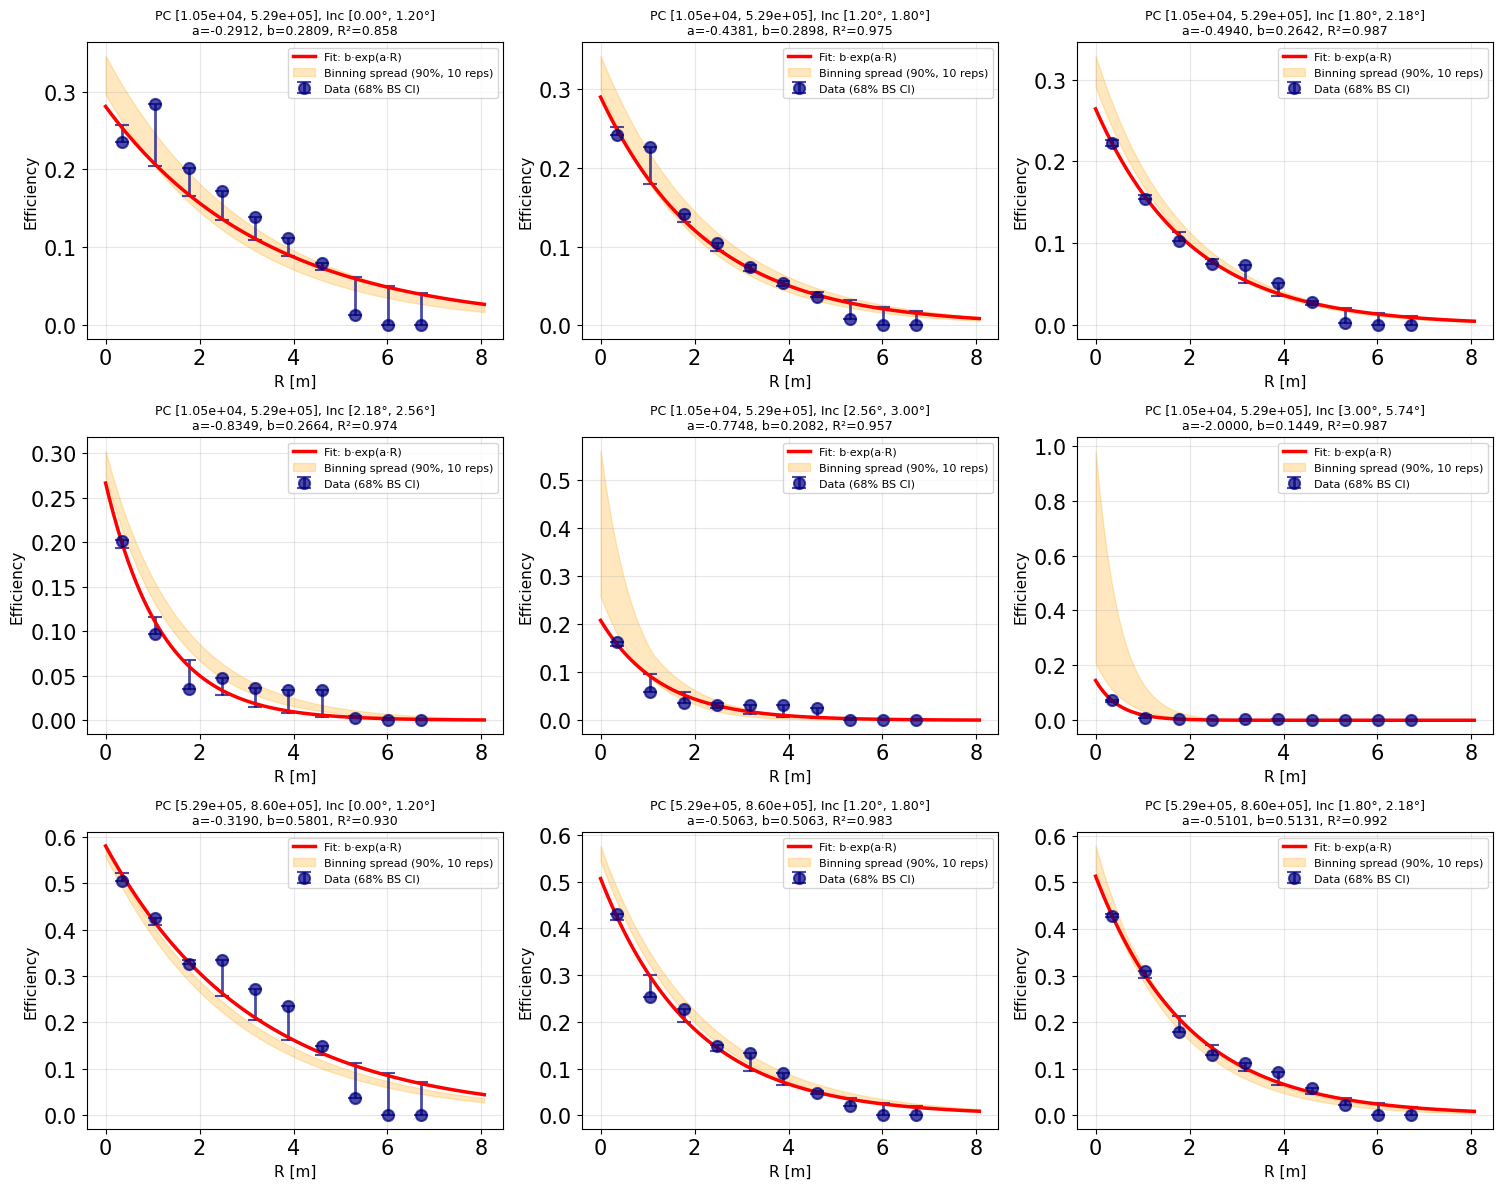


[Aeff] Creating 2D effective area map...


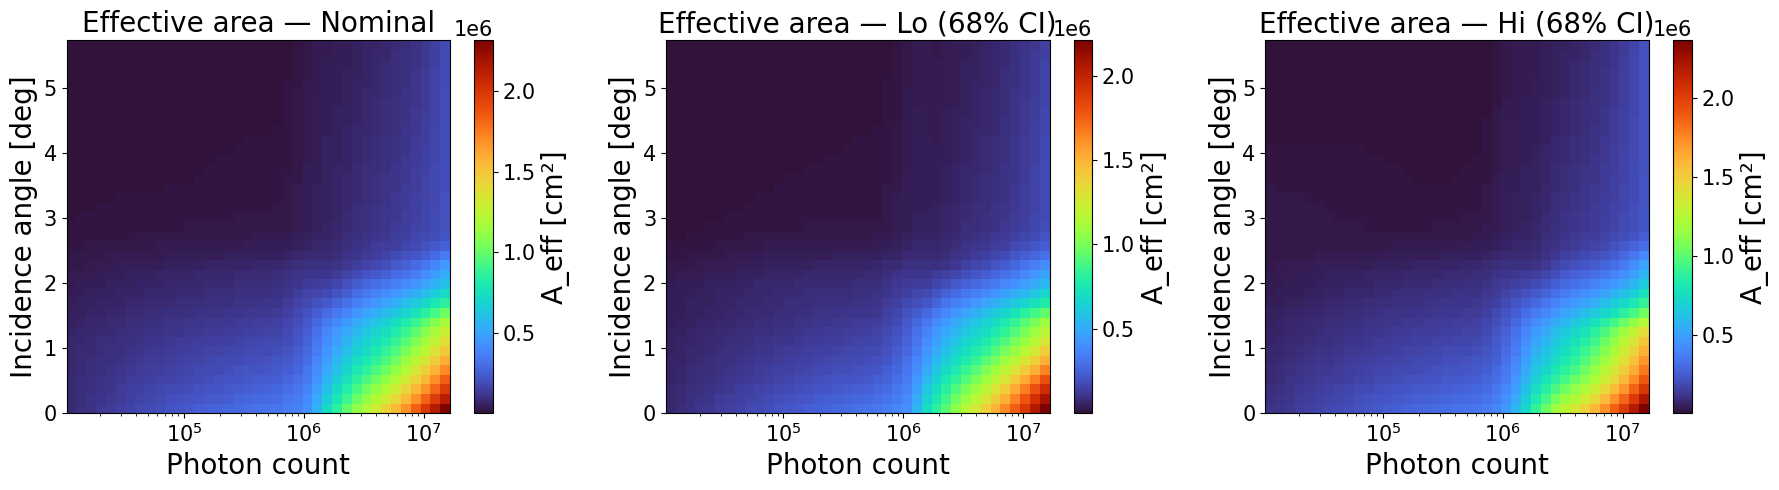

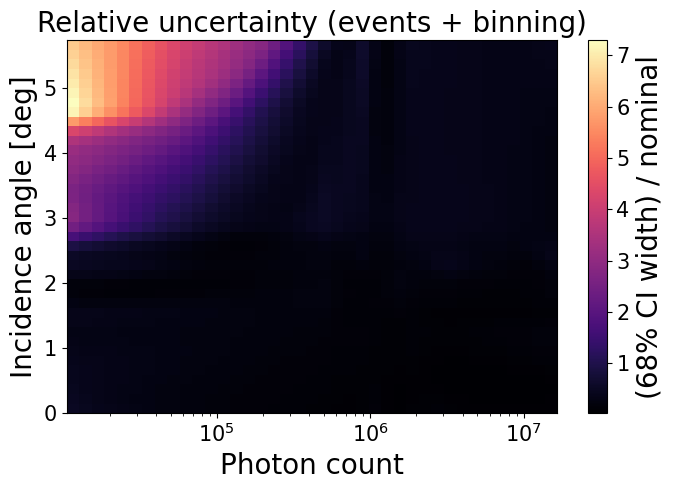


[Aeff] Creating parameter heatmaps...


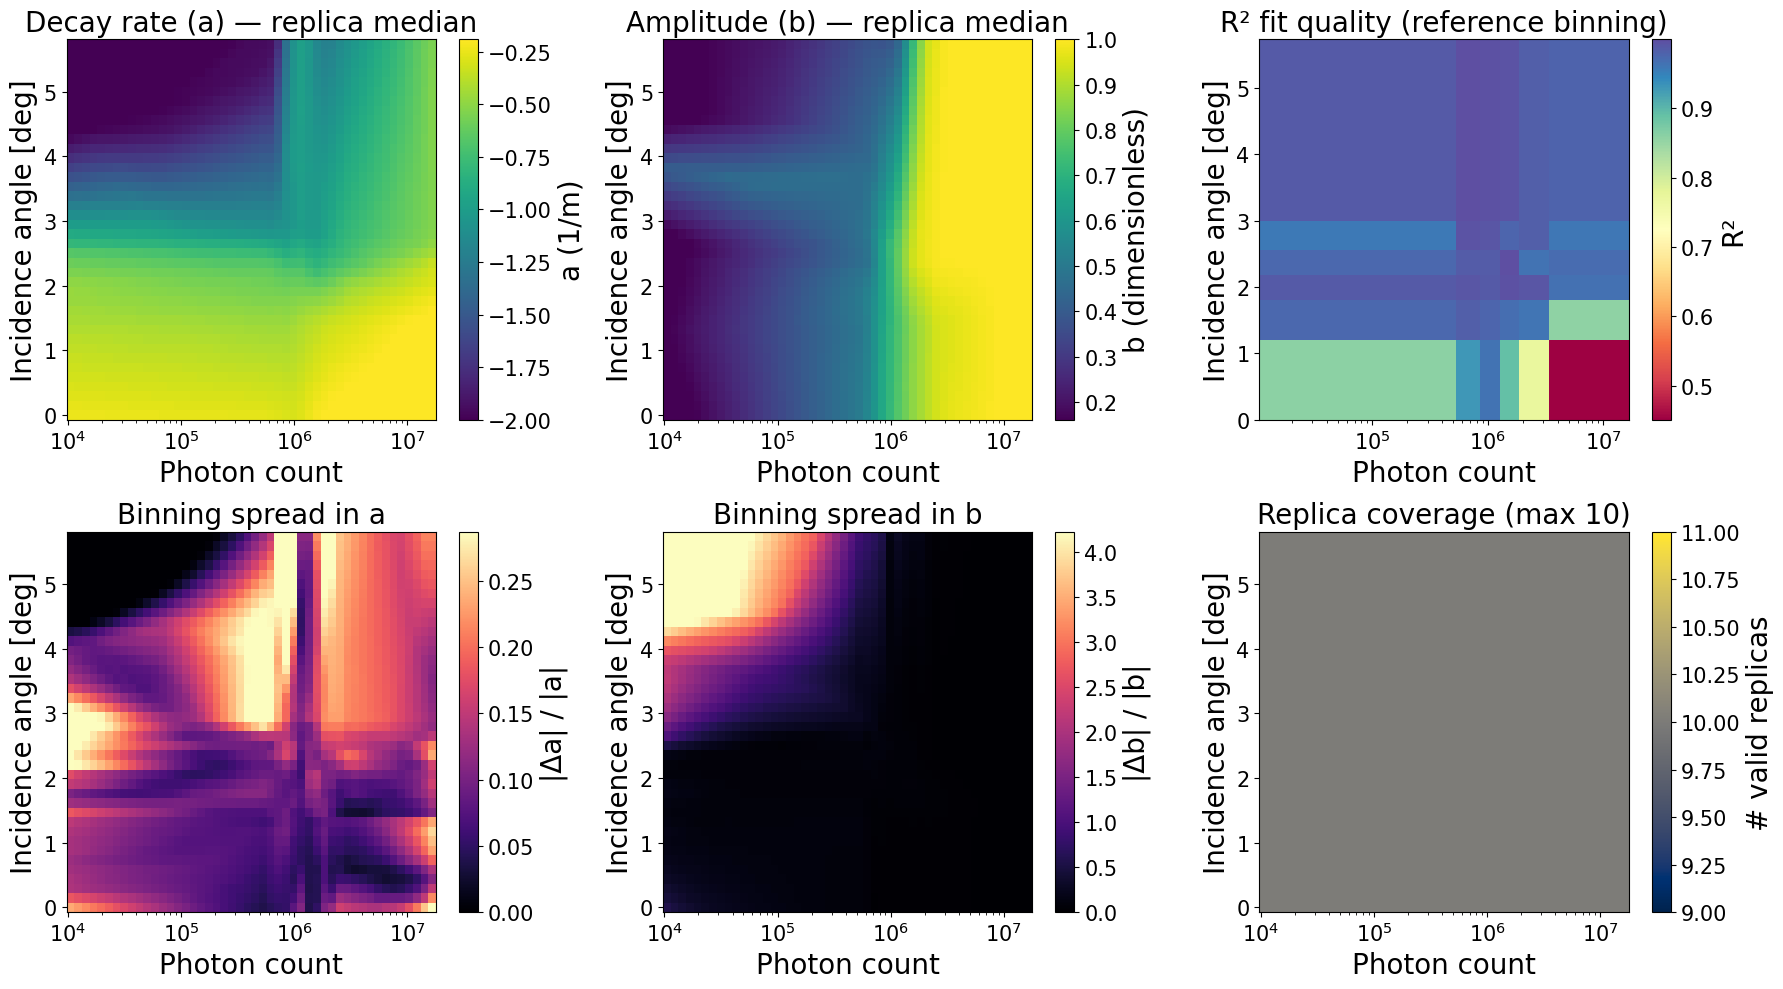

[Aeff] Heatmap plots complete!


In [9]:
# ---------- 5a. Reference-binning refit for diagnostics ---------------------
# The joint bootstrap discards per-cell arrays, so for validation plots we
# refit ONE reference binning (the median configuration) and keep everything.

print("\n[Aeff] Refitting reference binning for validation plots...")

REF_N_PC, REF_N_INC, REF_N_R = 6, 6, 10

ref_logPC_edges = np.unique(np.quantile(logPC_k, np.linspace(0, 1, REF_N_PC  + 1)))
ref_Inc_edges   = np.unique(np.quantile(Inc_k,   np.linspace(0, 1, REF_N_INC + 1)))
ref_n_pc  = len(ref_logPC_edges) - 1
ref_n_inc = len(ref_Inc_edges)   - 1

ref_R_edges   = np.linspace(R_k.min(), R_k.max(), REF_N_R + 1)
ref_R_centers = 0.5 * (ref_R_edges[:-1] + ref_R_edges[1:])
ref_n_r       = REF_N_R

ref_PC_edges  = 10.0 ** ref_logPC_edges

ref_pc_idx  = np.clip(np.digitize(logPC_k, ref_logPC_edges) - 1, 0, ref_n_pc  - 1)
ref_inc_idx = np.clip(np.digitize(Inc_k,   ref_Inc_edges)   - 1, 0, ref_n_inc - 1)

ref_a   = np.full((ref_n_pc, ref_n_inc), np.nan)
ref_b   = np.full((ref_n_pc, ref_n_inc), np.nan)
ref_r2  = np.full((ref_n_pc, ref_n_inc), np.nan)
ref_nom = np.full((ref_n_pc, ref_n_inc, ref_n_r), np.nan)
ref_lo  = np.full((ref_n_pc, ref_n_inc, ref_n_r), np.nan)
ref_hi  = np.full((ref_n_pc, ref_n_inc, ref_n_r), np.nan)

_rng = np.random.default_rng(RANDOM_SEED + 999)
N_REF_BOOT = 100

for i in range(ref_n_pc):
    for j in range(ref_n_inc):
        cell = (ref_pc_idx == i) & (ref_inc_idx == j)
        n_cell = int(cell.sum())
        if n_cell < 5:
            continue

        R_cell, trig_cell = R_k[cell], trig_k[cell]

        st, _ = np.histogram(R_cell, bins=ref_R_edges, weights=trig_cell)
        ct, _ = np.histogram(R_cell, bins=ref_R_edges)
        if ct.sum() < 5 or st.sum() == 0:
            continue
        if (st.sum() / ct.sum()) < MIN_MEAN_EFF:
            continue

        good = ct > 0
        if good.sum() < 2:
            continue

        eff_R = np.clip(st[good] / ct[good], 0.0, 1.0)
        ref_nom[i, j, good] = eff_R

        # nominal fit + R^2
        b0, ae = _fit_one_profile(ref_R_centers[good], eff_R, ct[good])
        if np.isfinite(b0):
            ref_a[i, j], ref_b[i, j] = ae, b0
            y_pred  = eff_model(ref_R_centers[good], b0, ae)
            w       = ct[good]
            y_wmean = np.average(eff_R, weights=w)
            ss_res  = np.sum(w * (eff_R - y_pred) ** 2)
            ss_tot  = np.sum(w * (eff_R - y_wmean) ** 2)
            if ss_tot > 0:
                ref_r2[i, j] = 1.0 - ss_res / ss_tot

        # bootstrap band on the fitted curve
        curves = np.full((ref_n_r, N_REF_BOOT), np.nan)
        for k in range(N_REF_BOOT):
            bs = _rng.integers(0, n_cell, size=n_cell)
            st_b, _ = np.histogram(R_cell[bs], bins=ref_R_edges, weights=trig_cell[bs])
            ct_b, _ = np.histogram(R_cell[bs], bins=ref_R_edges)
            g = ct_b > 0
            if g.sum() < 2:
                continue
            y = np.clip(st_b[g] / ct_b[g], 0.0, 1.0)
            bb, aa = _fit_one_profile(ref_R_centers[g], y, ct_b[g])
            if np.isfinite(bb):
                curves[:, k] = eff_model(ref_R_centers, bb, aa)

        ok = ~np.isnan(curves).all(axis=1)
        if ok.any():
            ref_lo[i, j, ok] = np.nanpercentile(curves[ok, :], 16, axis=1)
            ref_hi[i, j, ok] = np.nanpercentile(curves[ok, :], 84, axis=1)

print(f"[Aeff] Reference binning: {np.isfinite(ref_a).sum()}/{ref_n_pc*ref_n_inc} cells fitted.")


# ---------- 5b. Validate model: efficiency curves with bootstrap CI --------

print("\n[Aeff] Validating exponential model fit with bootstrap CI...")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# collect fitted cells first, then plot the first 9
cells_to_plot = [(i, j) for i in range(ref_n_pc) for j in range(ref_n_inc)
                 if np.isfinite(ref_a[i, j])][:9]

for plot_idx, (i, j) in enumerate(cells_to_plot):
    ax = axes[plot_idx]

    cell = (ref_pc_idx == i) & (ref_inc_idx == j)
    st, _ = np.histogram(R_k[cell], bins=ref_R_edges, weights=trig_k[cell])
    ct, _ = np.histogram(R_k[cell], bins=ref_R_edges)
    good = ct > 0

    eff_R = st[good] / ct[good]
    x     = ref_R_centers[good]

    valid = (np.isfinite(ref_nom[i, j, good])
             & np.isfinite(ref_lo[i, j, good])
             & np.isfinite(ref_hi[i, j, good]))

    if not valid.any():
        ax.scatter(x, eff_R, s=50, alpha=0.6, label='Data', color='k')
    else:
        y_nom = ref_nom[i, j, good][valid]
        y_lo  = ref_lo[i, j, good][valid]
        y_hi  = ref_hi[i, j, good][valid]
        ax.errorbar(x[valid], y_nom,
                    yerr=[np.clip(y_nom - y_lo, 0, np.inf),
                          np.clip(y_hi - y_nom, 0, np.inf)],
                    fmt='o', markersize=8, alpha=0.7,
                    label='Data (68% BS CI)', color='navy', capsize=5,
                    elinewidth=2, markeredgewidth=1.5)

    # reference-binning fit
    R_smooth = np.linspace(0, x.max() * 1.2, 100)
    a, b = ref_a[i, j], ref_b[i, j]
    eff_smooth = np.clip(b * np.exp(a * R_smooth), 0.0, 1.0)
    ax.plot(R_smooth, eff_smooth, 'r-', linewidth=2.5, label='Fit: b·exp(a·R)')

    # band across ALL binning replicas at this cell's centre
    logpc_c = 0.5 * (ref_logPC_edges[i] + ref_logPC_edges[i + 1])
    inc_c   = 0.5 * (ref_Inc_edges[j]   + ref_Inc_edges[j + 1])
    pt = np.array([[logpc_c, inc_c]])
    reps = np.array([
        np.clip(b * np.exp(a * R_smooth), 0.0, 1.0)
        for a, b in ((float(np.clip(INTERP_A_REPS[r](pt), -2.0, AEXP_UPPER)),
                      float(np.clip(INTERP_B_REPS[r](pt),  B0_LOWER, 1.0)))
                     for r in range(n_valid))
    ])
    ax.fill_between(R_smooth,
                    np.nanpercentile(reps,  5, axis=0),
                    np.nanpercentile(reps, 95, axis=0),
                    alpha=0.25, color='orange',
                    label=f'Binning spread (90%, {n_valid} reps)')

    ax.set_xlabel('R [m]', fontsize=11)
    ax.set_ylabel('Efficiency', fontsize=11)
    r2_val = ref_r2[i, j] if np.isfinite(ref_r2[i, j]) else 0.0
    ax.set_title(f'PC [{ref_PC_edges[i]:.2e}, {ref_PC_edges[i+1]:.2e}], '
                 f'Inc [{ref_Inc_edges[j]:.2f}°, {ref_Inc_edges[j+1]:.2f}°]\n'
                 f'a={a:.4f}, b={b:.4f}, R²={r2_val:.3f}', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

for idx in range(len(cells_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


# ---------- 5c. 2D heatmaps of effective area -----------------------------

print("\n[Aeff] Creating 2D effective area map...")

inc_bins_plot = np.linspace(Inc_k.min(), Inc_k.max(), 40)
pc_bins_plot  = np.logspace(np.log10(PC_k.min()), np.log10(PC_k.max()), 40)

inc_grid_plot = 0.5 * (inc_bins_plot[:-1] + inc_bins_plot[1:])
pc_grid_plot  = np.sqrt(pc_bins_plot[:-1] * pc_bins_plot[1:])

aeff_map_nom = np.full((len(inc_grid_plot), len(pc_grid_plot)), np.nan)
aeff_map_lo  = np.full_like(aeff_map_nom, np.nan)
aeff_map_hi  = np.full_like(aeff_map_nom, np.nan)

for j, inc_val in enumerate(inc_grid_plot):
    nom, lo, hi = eff_area_ci(pc_grid_plot, np.full_like(pc_grid_plot, inc_val))
    aeff_map_nom[j, :] = nom
    aeff_map_lo[j, :]  = lo
    aeff_map_hi[j, :]  = hi

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title in zip(axes,
                           [aeff_map_nom, aeff_map_lo, aeff_map_hi],
                           ["Nominal", f"Lo ({CI_LEVEL:.0f}% CI)", f"Hi ({CI_LEVEL:.0f}% CI)"]):
    pcm = ax.pcolormesh(pc_bins_plot, inc_bins_plot, data, cmap='turbo', shading='auto')
    fig.colorbar(pcm, ax=ax).set_label('A_eff [cm²]')
    ax.set_xscale('log')
    ax.set_xlabel('Photon count')
    ax.set_ylabel('Incidence angle [deg]')
    ax.set_title(f'Effective area — {title}')
plt.tight_layout()
plt.show()

# fractional CI width
frac_width = (aeff_map_hi - aeff_map_lo) / np.clip(aeff_map_nom, 1e-30, None)
fig, ax = plt.subplots(figsize=(7, 5))
pcm = ax.pcolormesh(pc_bins_plot, inc_bins_plot, frac_width,
                    cmap='magma', shading='auto')
fig.colorbar(pcm, ax=ax).set_label(f'({CI_LEVEL:.0f}% CI width) / nominal')
ax.set_xscale('log')
ax.set_xlabel('Photon count')
ax.set_ylabel('Incidence angle [deg]')
ax.set_title('Relative uncertainty (events + binning)')
plt.tight_layout()
plt.show()


# ---------- 6. Parameter maps on the common output grid -------------------

print("\n[Aeff] Creating parameter heatmaps...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# a — replica median
ax = axes[0, 0]
pcm = ax.pcolormesh(PC_edges, Inc_edges, a_nom.T, cmap='viridis', shading='auto',
                    vmin=np.nanpercentile(a_nom, 5), vmax=np.nanpercentile(a_nom, 95))
fig.colorbar(pcm, ax=ax).set_label('a (1/m)')
ax.set_title('Decay rate (a) — replica median')

# b — replica median
ax = axes[0, 1]
pcm = ax.pcolormesh(PC_edges, Inc_edges, b_nom.T, cmap='viridis', shading='auto',
                    vmin=np.nanpercentile(b_nom, 5), vmax=np.nanpercentile(b_nom, 95))
fig.colorbar(pcm, ax=ax).set_label('b (dimensionless)')
ax.set_title('Amplitude (b) — replica median')

# R^2 from the reference binning (coarse grid)
ax = axes[0, 2]
pcm = ax.pcolormesh(ref_PC_edges, ref_Inc_edges, ref_r2.T, cmap='Spectral', shading='auto')
fig.colorbar(pcm, ax=ax).set_label('R²')
ax.set_title('R² fit quality (reference binning)')

# binning-induced spread in a
ax = axes[1, 0]
pcm = ax.pcolormesh(PC_edges, Inc_edges, a_spread.T, cmap='magma', shading='auto',
                    vmin=0, vmax=np.nanpercentile(a_spread, 95))
fig.colorbar(pcm, ax=ax).set_label('|Δa| / |a|')
ax.set_title('Binning spread in a')

# binning-induced spread in b
ax = axes[1, 1]
pcm = ax.pcolormesh(PC_edges, Inc_edges, b_spread.T, cmap='magma', shading='auto',
                    vmin=0, vmax=np.nanpercentile(b_spread, 95))
fig.colorbar(pcm, ax=ax).set_label('|Δb| / |b|')
ax.set_title('Binning spread in b')

# replica coverage
ax = axes[1, 2]
coverage = np.isfinite(A_REPLICAS).sum(axis=0)
pcm = ax.pcolormesh(PC_edges, Inc_edges, coverage.T, cmap='cividis', shading='auto')
fig.colorbar(pcm, ax=ax).set_label('# valid replicas')
ax.set_title(f'Replica coverage (max {n_valid})')

for ax in axes.ravel():
    ax.set_xscale('log')
    ax.set_xlabel('Photon count')
    ax.set_ylabel('Incidence angle [deg]')

plt.tight_layout()
plt.show()

print("[Aeff] Heatmap plots complete!")


[Aeff] Creating line plots of a and b vs photon count...


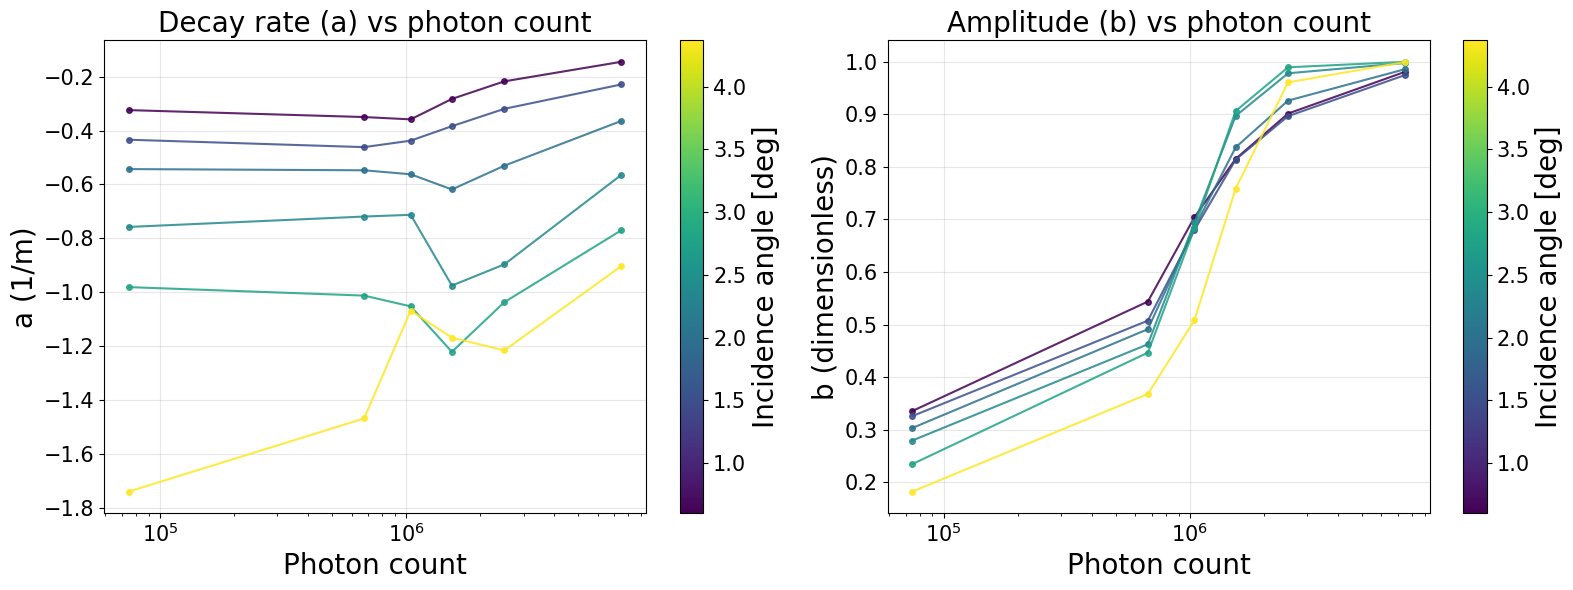

[Aeff] Line plots complete!

[Aeff] Creating line plots of a and b vs incidence angle...


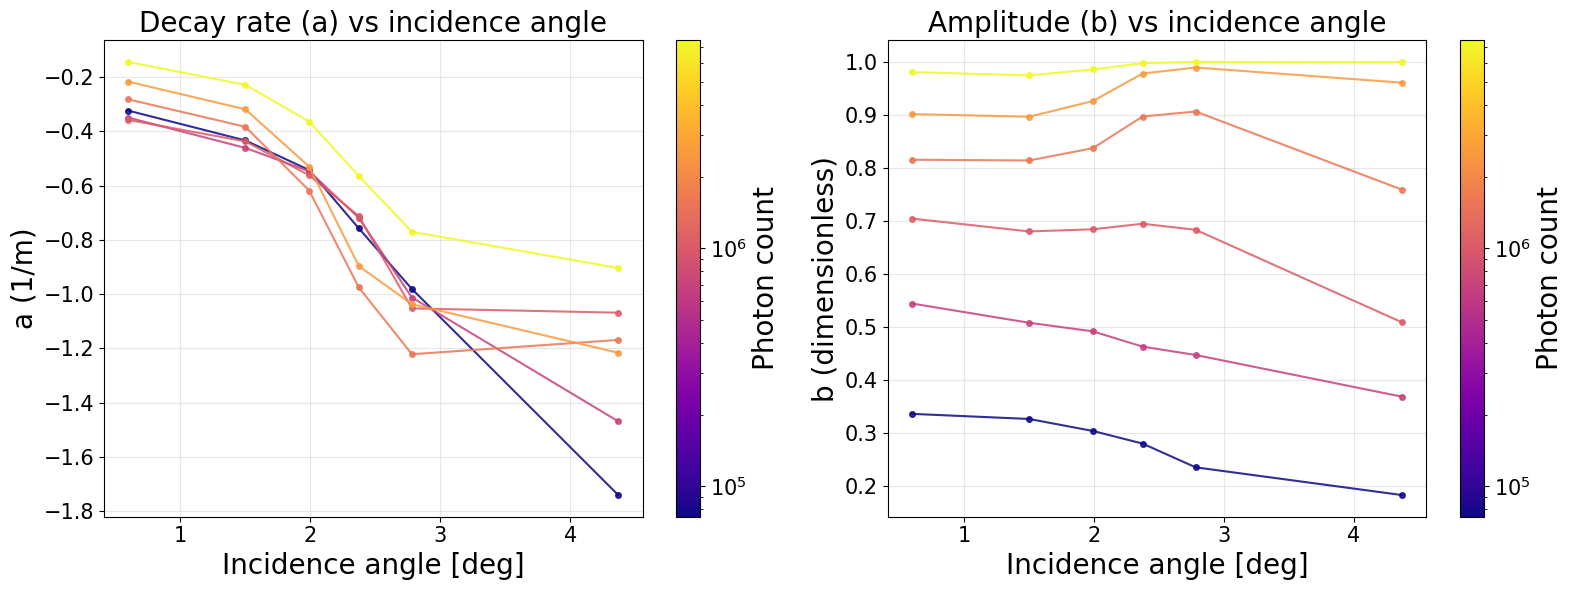

[Aeff] Line plots complete!


In [6]:
# ---------- 7. Line plots: a and b vs photon count, colored by incidence angle ----------

print("\n[Aeff] Creating line plots of a and b vs photon count...")

pc_centers_line = np.sqrt(PC_edges[:-1] * PC_edges[1:])   # geometric bin centers
inc_centers_line = 0.5 * (Inc_edges[:-1] + Inc_edges[1:])

cmap_line = plt.get_cmap('viridis')
norm_line = plt.Normalize(vmin=inc_centers_line.min(), vmax=inc_centers_line.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- a (decay rate) vs photon count ---
ax = axes[0]
for j in range(n_Inc_bins):
    a_line = a_smooth[:, j]
    good = np.isfinite(a_line)
    if good.sum() < 2:
        continue
    color = cmap_line(norm_line(inc_centers_line[j]))
    ax.plot(pc_centers_line[good], a_line[good],
            marker='o', markersize=4, linewidth=1.5,
            color=color, alpha=0.85)

ax.set_xscale('log')
ax.set_xlabel('Photon count')
ax.set_ylabel('a (1/m)')
ax.set_title('Decay rate (a) vs photon count')
ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap_line, norm=norm_line)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Incidence angle [deg]')

# --- b (amplitude) vs photon count ---
ax = axes[1]
for j in range(n_Inc_bins):
    b_line = b_smooth[:, j]
    good = np.isfinite(b_line)
    if good.sum() < 2:
        continue
    color = cmap_line(norm_line(inc_centers_line[j]))
    ax.plot(pc_centers_line[good], b_line[good],
            marker='o', markersize=4, linewidth=1.5,
            color=color, alpha=0.85)

ax.set_xscale('log')
ax.set_xlabel('Photon count')
ax.set_ylabel('b (dimensionless)')
ax.set_title('Amplitude (b) vs photon count')
ax.grid(True, alpha=0.3)

sm2 = plt.cm.ScalarMappable(cmap=cmap_line, norm=norm_line)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=ax)
cbar2.set_label('Incidence angle [deg]')

plt.tight_layout()
plt.show()

print("[Aeff] Line plots complete!")
# ---------- 8. Line plots: a and b vs incidence angle, colored by photon count ----------

print("\n[Aeff] Creating line plots of a and b vs incidence angle...")

pc_centers_line = np.sqrt(PC_edges[:-1] * PC_edges[1:])   # geometric bin centers
inc_centers_line = 0.5 * (Inc_edges[:-1] + Inc_edges[1:])

cmap_line = plt.get_cmap('plasma')
norm_line = mcolors.LogNorm(vmin=pc_centers_line.min(), vmax=pc_centers_line.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- a (decay rate) vs incidence angle ---
ax = axes[0]
for i in range(n_PC_bins):
    a_line = a_smooth[i, :]
    good = np.isfinite(a_line)
    if good.sum() < 2:
        continue
    color = cmap_line(norm_line(pc_centers_line[i]))
    ax.plot(inc_centers_line[good], a_line[good],
            marker='o', markersize=4, linewidth=1.5,
            color=color, alpha=0.85)

ax.set_xlabel('Incidence angle [deg]')
ax.set_ylabel('a (1/m)')
ax.set_title('Decay rate (a) vs incidence angle')
ax.grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap_line, norm=norm_line)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Photon count')

# --- b (amplitude) vs incidence angle ---
ax = axes[1]
for i in range(n_PC_bins):
    b_line = b_smooth[i, :]
    good = np.isfinite(b_line)
    if good.sum() < 2:
        continue
    color = cmap_line(norm_line(pc_centers_line[i]))
    ax.plot(inc_centers_line[good], b_line[good],
            marker='o', markersize=4, linewidth=1.5,
            color=color, alpha=0.85)

ax.set_xlabel('Incidence angle [deg]')
ax.set_ylabel('b (dimensionless)')
ax.set_title('Amplitude (b) vs incidence angle')
ax.grid(True, alpha=0.3)

sm2 = plt.cm.ScalarMappable(cmap=cmap_line, norm=norm_line)
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=ax)
cbar2.set_label('Photon count')

plt.tight_layout()
plt.show()

print("[Aeff] Line plots complete!")

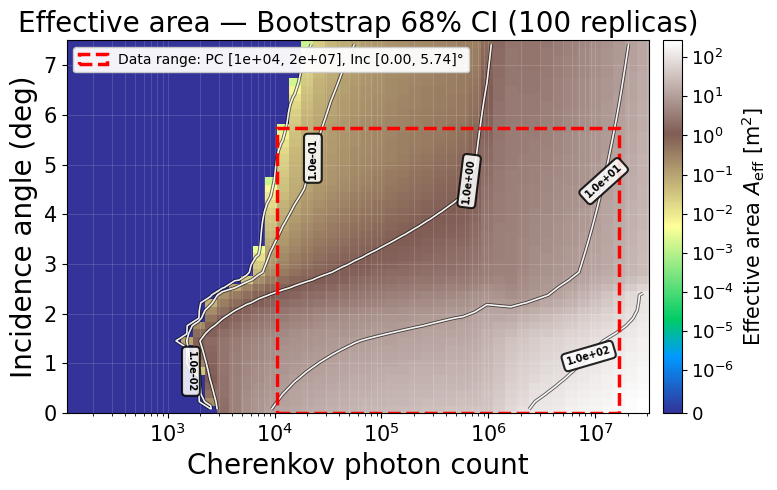

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif':  ['DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'xtick.labelsize':  15,
    'ytick.labelsize':  15,
    'axes.labelsize':   20,
    'axes.titlesize':   20,
})

# ── Grid ──────────────────────────────────────────────────────────────────
inc_bins = np.linspace(0, 7.5, 50)
pc_bins  = np.logspace(2, 7.5, 50)          # 1e3 to 1e7.5

inc_grid_2d = 0.5 * (inc_bins[:-1] + inc_bins[1:])
pc_grid_2d  = np.sqrt(pc_bins[:-1] * pc_bins[1:])   # geometric midpoints

# ── Evaluate effective area on the 2D grid ────────────────────────────────
aeff_map = np.full((len(inc_grid_2d), len(pc_grid_2d)), np.nan)  # shape (n_inc, n_pc)
for j, inc_val in enumerate(inc_grid_2d):
    aeff_c, aeff_c_lo, aeff_c_hi = eff_area_ci(pc_grid_2d, inc_val)
    #aeff_c = aeff_c-aeff_c_lo  # ← use the lower CI bound to avoid overestimating
    aeff_map[j, :] = aeff_c/1e4                 # ← row = inc, col = pc

# ── Symlog color norm (effective area in m^2, spans many decades, may include 0) ──
aeff_finite = aeff_map[np.isfinite(aeff_map)]
aeff_abs_pos = aeff_finite#np.abs(aeff_finite[aeff_finite != 0])

vmin = float(np.nanmin(aeff_finite)) if aeff_finite.size else -1.0
vmax = float(np.nanmax(aeff_finite)) if aeff_finite.size else 1e6

# linear threshold: smallest scale we still treat "linearly" near zero
linthresh = float(np.nanmin(aeff_abs_pos)) if aeff_abs_pos.size else 1e-3
linthresh = max(linthresh, 1e-6)  # guard against zero/negative

norm = mcolors.SymLogNorm(linthresh=linthresh, linscale=1.0,
                          vmin=vmin, vmax=vmax, base=10)

# ── Figure ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

mesh = ax.pcolormesh(
    pc_bins, inc_bins, aeff_map,           # ← x=pc, y=inc
    norm=norm,
    cmap='terrain',
    shading='auto',
)

# ── Contours with black outline ────────────────────────────────────────────
# For symlog, pick levels spanning the positive range (log-spaced) plus keep
# them within [vmin, vmax]
# ── Contours with black outline ────────────────────────────────────────────
contour_levels = [1e-2, 1e-1, 1e0, 1e1, 1e2]

if len(contour_levels):
    # Draw black outline contours first (thicker, solid)
    cs_outline = ax.contour(
        pc_grid_2d, inc_grid_2d, aeff_map,
        levels=contour_levels,
        colors='black',
        linewidths=2.5,
        alpha=0.6,
    )

    # Draw white contours on top (thinner)
    cs = ax.contour(
        pc_grid_2d, inc_grid_2d, aeff_map,    # ← x=pc, y=inc
        levels=contour_levels,
        colors='white',
        linewidths=1.2,
        alpha=0.95,
    )

    ax.clabel(cs,
              fmt={v: f'{v:.1e}' for v in contour_levels},
              fontsize=7,
              inline=False,
              inline_spacing=10)

    for text in cs.labelTexts:
        text.set_bbox(dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='black',
            linewidth=1.5,
            alpha=0.85
        ))
        text.set_color('black')
        text.set_fontweight('bold')

# ── Data Range Box ────────────────────────────────────────────────────────
pc_data_min = pc_[hit_ > 0].min()
pc_data_max = pc_.max()
inc_data_min = inc_.min()
inc_data_max = inc_.max()

data_box = mpatches.Rectangle(
    (pc_data_min, inc_data_min),
    pc_data_max - pc_data_min,
    inc_data_max - inc_data_min,
    linewidth=2.5,
    edgecolor='red',
    facecolor='none',
    linestyle='--',
    label=f'Data range: PC [{pc_data_min:.0e}, {pc_data_max:.0e}], Inc [{inc_data_min:.2f}, {inc_data_max:.2f}]°',
    zorder=2,
)
ax.add_patch(data_box)

# ── Colorbar ──────────────────────────────────────────────────────────────
cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label(r'Effective area $A_{\mathrm{eff}}$ [m$^2$]', fontsize=15)
cbar.ax.tick_params(labelsize=13)

# ── Axes ──────────────────────────────────────────────────────────────────
ax.set_xscale('log')
ax.set_xlabel('Cherenkov photon count')
ax.set_ylabel('Incidence angle (deg)')
ax.set_title(f'Effective area — Bootstrap {CI_LEVEL}% CI ({N_BOOT} replicas)')
ax.grid(True, which='both', alpha=0.2, color='white', linewidth=0.5)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)

fig.tight_layout()
plt.show()

In [8]:
# Empirical effective-area cube on (zenith, azimuth, H, E)
# =============================================================================
# Direct adaptation of the trigger-efficiency cube pipeline
# (efficiency_grid_H_E / extrapolate_via_slant / build_efficiency_interpolator)
# with trigger_eff_ci(...) replaced by eff_area_ci(...), so every bin now
# holds an *effective area* [m^2] instead of a dimensionless trigger
# probability.
#
# REQUIRED PRE-EXISTING NAMESPACE (from the eff_area_ci cell):
#   eff_area_ci, interp_a, interp_b, R_MAX_GLOBAL, _area_integral_exact
#
# Key differences vs the trigger-efficiency version:
#   1. area_eff_ci_adapter() wraps eff_area_ci() so its call signature
#      matches trigger_eff_ci(pc, inc, reducer=...) used by the zenith-slice
#      workers. `reducer` is accepted and silently ignored: eff_area_ci is a
#      single closed-form (a,b)-interpolated model, it has no
#      mean/median/global empirical-reducer variants.
#   2. Every np.clip(..., 0.0, 1.0) that assumed a probability is relaxed to
#      np.clip(..., 0.0, None) — area has a floor of 0 but no ceiling of 1.
#   3. Cube arrays are named AEFF / AEFF_LO / AEFF_HI (m^2) instead of
#      EFF / EFF_LO / EFF_HI. Grid-building/parallelization logic is
#      otherwise untouched.
# =============================================================================

import os
import numpy as np
from joblib import Parallel, delayed
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

# ---------- Config ----------
BOOT_SEED   = 123
N_BOOT_EFF  = N_BOOTSTRAP
MIN_PTS_EFF = 5
N_E_BINS    = 20
N_H_BINS    = 10
N_Z_BINS    = 10
N_AZ_BINS   = 5

N_JOBS      = os.cpu_count()

Telescope_Zenith = 90
ENERGY_MIN = 1e1
ENERGY_MAX = 1e6
ZEN_MIN    = np.nanmin(Zenith)
ZEN_MAX    = np.nanmax(Zenith)

AZIMUTH_RANGE = 10
AZ_MIN = 0.0
AZ_MAX = AZIMUTH_RANGE

H_MIN = np.nanmin(H)
H_MAX = np.nanmax(H)

OBS_HEIGHT_M   = 2_944.0
EARTH_RADIUS_M = 6_371_000.0

N_PARAMS    = 1
PARAM_ORDER = ["dummy"]
COV_FULL    = np.zeros((N_PARAMS, N_PARAMS))

# Radius used for the effective-area radial integral (see eff_area_ci cell).
# Override this after import if you want a different integration radius
# than the one baked into the eff_area_ci module.
AEFF_R_MAX = R_MAX_GLOBAL


def area_eff_ci_adapter(pc_b, inc_b, reducer=None):
    """
    Drop-in replacement for trigger_eff_ci(pc, inc, reducer=...) that
    returns *effective area* [cm^2] instead of trigger probability.
    `reducer` is accepted only for call-signature compatibility with the
    zenith-slice workers below; eff_area_ci has one closed-form model, so
    the argument has no effect.

    Returns (nom, lo, hi), each broadcast to the shape of (pc_b, inc_b).
    """
    return eff_area_ci(pc_b, inc_b, R_max=AEFF_R_MAX)


# =============================================================================
# Helpers
# =============================================================================

def _phi_inc_grid(zen_deg, tele_zen_deg, phi_max_deg, n_phi):
    """Returns phi (n_phi,) in degrees AND radians, and theta_inc (n_phi,)."""
    theta_z  = np.radians(zen_deg)
    psi      = np.radians(tele_zen_deg)
    phi_rad  = np.linspace(0.0, np.radians(phi_max_deg), n_phi)
    phi_deg  = np.degrees(phi_rad)
    cos_t    = (np.cos(psi) * np.cos(theta_z)
                + np.sin(psi) * np.sin(theta_z) * np.cos(phi_rad))
    cos_t    = np.clip(cos_t, -1.0, 1.0)
    theta_inc = np.degrees(np.arccos(cos_t))   # (n_phi,)
    return phi_rad, phi_deg, theta_inc


def _combine_uncertainty(med_phi, lo_phi, hi_phi, n_boot, rng):
    """
    Combine model-side CI (lo/hi per shower) with bootstrap sampling CI
    over showers, returning (nominal, lo, hi). No upper clip at 1 — these
    are effective-area values [m^2], not probabilities.
    """
    npts = len(med_phi)
    aeff_nom = float(np.mean(med_phi))

    aeff_model_lo = float(np.mean(lo_phi))
    aeff_model_hi = float(np.mean(hi_phi))

    if npts >= 2 and n_boot > 0:
        idx = rng.integers(0, npts, size=(n_boot, npts))
        boot_means = med_phi[idx].mean(axis=1)
        stat_lo, stat_hi = np.percentile(boot_means, [16, 84])
    else:
        stat_lo = stat_hi = aeff_nom

    sig_stat_lo = max(aeff_nom - stat_lo, 0.0)
    sig_stat_hi = max(stat_hi - aeff_nom, 0.0)
    sig_mod_lo  = max(aeff_nom - aeff_model_lo, 0.0)
    sig_mod_hi  = max(aeff_model_hi - aeff_nom, 0.0)

    aeff_lo = aeff_nom - np.hypot(sig_stat_lo, sig_mod_lo)
    aeff_hi = aeff_nom + np.hypot(sig_stat_hi, sig_mod_hi)
    return aeff_nom, max(aeff_lo, 0.0), aeff_hi


# =============================================================================
# 1. Forward-fill along H — fully vectorized (unchanged, dtype-agnostic)
# =============================================================================

def ffill_along_H(AEFF, *extras):
    """
    Forward-fill NaNs along the H axis (axis=2) for arrays of shape
    (n_zen, n_az, n_H, n_E[, ...]).
    """
    n_zen, n_az, n_H, n_E = AEFF.shape[:4]

    def _ffill_4d(arr):
        out = arr.copy()
        finite = np.isfinite(out)
        h_idx = np.where(finite, np.arange(n_H)[None, None, :, None], 0)
        np.maximum.accumulate(h_idx, axis=2, out=h_idx)
        z_idx = np.arange(n_zen)[:, None, None, None]
        a_idx = np.arange(n_az)[None, :, None, None]
        e_idx = np.arange(n_E)[None, None, None, :]
        out   = out[z_idx, a_idx, h_idx, e_idx]
        first_finite = np.argmax(finite, axis=2)
        all_nan      = ~finite.any(axis=2)
        h_range      = np.arange(n_H)[None, None, :, None]
        before       = h_range < first_finite[:, :, None, :]
        out[before | all_nan[:, :, None, :]] = np.nan
        return out

    def _ffill_5d(arr):
        n_p = arr.shape[4]
        return np.stack([_ffill_4d(arr[..., p]) for p in range(n_p)], axis=-1)

    out_aeff = _ffill_4d(AEFF)
    out_extras = []
    for arr in extras:
        if arr.ndim == 4:
            out_extras.append(_ffill_4d(arr))
        elif arr.ndim == 5:
            out_extras.append(_ffill_5d(arr))
        else:
            raise ValueError(f"ffill_along_H: unsupported ndim={arr.ndim}")

    return (out_aeff, *out_extras) if out_extras else out_aeff


# =============================================================================
# 2. Per-zenith-slice worker (used by area_grid_H_E)
# =============================================================================

def _process_zen_slice_area_HE(k, zen_deg, bin_tasks,
                                tele_zen_deg, phi_max_deg, n_phi,
                                reducer, n_boot, rng_seed):
    if not bin_tasks:
        return []

    rng = np.random.default_rng(rng_seed)
    phi_rad, phi_deg, theta_inc = _phi_inc_grid(
        zen_deg, tele_zen_deg, phi_max_deg, n_phi
    )

    results = []
    for (j, i, pc_sel) in bin_tasks:
        pc_b   = pc_sel[:, None]                          # (N, n_phi)
        inc_b  = theta_inc[None, :]                       # (1, n_phi)
        med_raw, lo_raw, hi_raw = area_eff_ci_adapter(pc_b, inc_b, reducer=reducer)

        med_phi = med_raw.mean(axis=0)   # (n_phi,)
        lo_phi  = lo_raw.mean(axis=0)
        hi_phi  = hi_raw.mean(axis=0)

        if n_boot > 1 and len(pc_sel) >= 2:
            idx = rng.integers(0, len(pc_sel), size=(n_boot, len(pc_sel)))
            boot = med_raw[idx].mean(axis=1)
            stat_lo = np.percentile(boot, 16, axis=0)
            stat_hi = np.percentile(boot, 84, axis=0)
        else:
            stat_lo = med_phi.copy()
            stat_hi = med_phi.copy()

        sig_stat_lo = np.maximum(med_phi - stat_lo, 0.0)
        sig_stat_hi = np.maximum(stat_hi - med_phi, 0.0)
        sig_mod_lo  = np.maximum(med_phi - lo_phi,  0.0)
        sig_mod_hi  = np.maximum(hi_phi  - med_phi, 0.0)
        aeff_lo = med_phi - np.hypot(sig_stat_lo, sig_mod_lo)
        aeff_hi = med_phi + np.hypot(sig_stat_hi, sig_mod_hi)

        results.append((
            k, j, i,
            med_phi,
            np.clip(aeff_lo, 0.0, None),   # floor at 0, no ceiling of 1
            np.clip(aeff_hi, 0.0, None),
        ))

    return results


# =============================================================================
# 3. Empirical effective-area cube (parallel over zenith slices)
# =============================================================================

def area_grid_H_E(
    E_edges, H_edges, Zen_grid, Az_grid,
    Energy_GeV, H, photon_count,
    tele_zen_deg=90.0, phi_max_deg=3.0, n_phi=50,
    min_pts=5, reducer='mean',
    n_boot=200, rng=None, n_jobs=1,
):
    n_zen = len(Zen_grid)
    n_az  = len(Az_grid)
    n_H   = len(H_edges) - 1
    n_E   = len(E_edges) - 1
    E_cen = np.sqrt(E_edges[:-1] * E_edges[1:])
    H_cen = 0.5 * (H_edges[:-1] + H_edges[1:])

    AEFF    = np.full((n_zen, n_az, n_H, n_E), np.nan)
    AEFF_LO = np.full((n_zen, n_az, n_H, n_E), np.nan)
    AEFF_HI = np.full((n_zen, n_az, n_H, n_E), np.nan)
    COUNTS  = np.zeros((n_zen, n_az, n_H, n_E), dtype=int)
    GRAD    = np.zeros((n_zen, n_az, n_H, n_E, N_PARAMS))
    pc_in_bin = [[[None] * n_E for _ in range(n_H)] for _ in range(n_zen)]

    E_idx = np.digitize(Energy_GeV, E_edges) - 1
    H_idx = np.digitize(H,          H_edges) - 1

    valid = (E_idx >= 0) & (E_idx < n_E) & (H_idx >= 0) & (H_idx < n_H)
    E_idx_v = E_idx[valid]
    H_idx_v = H_idx[valid]
    pc_v    = photon_count[valid]

    flat_idx = H_idx_v * n_E + E_idx_v
    _order  = np.argsort(flat_idx)
    _fi_s   = flat_idx[_order]
    _pc_s   = pc_v[_order]
    _splits = np.searchsorted(_fi_s, np.arange(n_H * n_E + 1))
    pc_HE   = {}
    for flat in range(n_H * n_E):
        j, i = divmod(flat, n_E)
        sl   = slice(_splits[flat], _splits[flat + 1])
        cnt  = _splits[flat + 1] - _splits[flat]
        COUNTS[:, :, j, i] = cnt
        if cnt >= min_pts:
            pc_HE[(j, i)] = _pc_s[sl]
            for k in range(n_zen):
                pc_in_bin[k][j][i] = _pc_s[sl]

    if not pc_HE:
        return (AEFF, AEFF_LO, AEFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)

    zen_tasks = []
    for k, zen_deg in enumerate(Zen_grid):
        bin_tasks = [(j, i, arr) for (j, i), arr in pc_HE.items()]
        zen_tasks.append((k, zen_deg, bin_tasks))

    n_total_bins = len(Zen_grid) * len(pc_HE)
    print(f"area_grid_H_E: {n_total_bins} bins "
          f"({len(Zen_grid)} zen x {len(pc_HE)} HE), {n_jobs} CPUs")

    rng_seed = int(rng.integers(0, 2**31 - 1)) if rng is not None else None

    slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_zen_slice_area_HE)(k, zen_deg, bin_tasks,
                                   tele_zen_deg, phi_max_deg, n_phi, reducer,
                                   n_boot, rng_seed)
        for k, zen_deg, bin_tasks in zen_tasks
    )

    for slice_out in slice_results:
        for k, j, i, med_phi, lo_phi, hi_phi in slice_out:
            for a in range(n_az):
                AEFF[k, a, j, i]    = med_phi[a]
                AEFF_LO[k, a, j, i] = lo_phi[a]
                AEFF_HI[k, a, j, i] = hi_phi[a]
            COUNTS[k, :, j, i] = COUNTS[k, 0, j, i]

    return (AEFF, AEFF_LO, AEFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD)


# =============================================================================
# 4. Build (E, Slant) photon-count lookup table (unchanged: no efficiency
#    call inside this one, it's pure binning)
# =============================================================================

def build_E_slant_pc_table(E_edges, H_emit, Energy_GeV, photon_count,
                           Zenith_deg, n_slant_bins):
    E_edges      = np.asarray(E_edges,      dtype=float)
    H_emit       = np.asarray(H_emit,       dtype=float)
    Energy_GeV   = np.asarray(Energy_GeV,   dtype=float)
    photon_count = np.asarray(photon_count, dtype=float)
    Zenith_rad   = np.radians(np.asarray(Zenith_deg, dtype=float))

    Slant_km = slant_depth(
        H_emit + EARTH_RADIUS_M,
        OBS_HEIGHT_M + EARTH_RADIUS_M,
        Zenith_rad,
    ) / 1000.0

    S_edges = np.linspace(np.nanmin(Slant_km), np.nanmax(Slant_km), n_slant_bins + 1)
    S_cen   = 0.5 * (S_edges[:-1] + S_edges[1:])
    n_E     = len(E_edges) - 1

    finite_mask = np.isfinite(photon_count) & (photon_count > 0)
    E_idx = np.digitize(Energy_GeV, E_edges) - 1
    S_idx = np.digitize(Slant_km,   S_edges) - 1

    valid = (finite_mask
             & (E_idx >= 0) & (E_idx < n_E)
             & (S_idx >= 0) & (S_idx < n_slant_bins))
    E_idx_v  = E_idx[valid]
    S_idx_v  = S_idx[valid]
    pc_v     = photon_count[valid]

    flat_idx = E_idx_v * n_slant_bins + S_idx_v
    order    = np.argsort(flat_idx)
    fi_s     = flat_idx[order]
    pc_s     = pc_v[order]
    splits   = np.searchsorted(fi_s, np.arange(n_E * n_slant_bins + 1))

    pc_ES = [[None] * n_slant_bins for _ in range(n_E)]
    for flat in range(n_E * n_slant_bins):
        i, s = divmod(flat, n_slant_bins)
        sl = slice(splits[flat], splits[flat + 1])
        arr = pc_s[sl]
        pc_ES[i][s] = arr if len(arr) > 0 else np.empty(0)

    return S_edges, S_cen, pc_ES


# =============================================================================
# 5. Slant-based extrapolation — parallel over zenith slices
# =============================================================================

def _process_zen_slice_area_slant(k, zen, j_tasks, tele_zen_deg, phi_max_deg, n_phi,
                                   reducer, n_boot, rng_seed):
    if not j_tasks:
        return []
    rng = np.random.default_rng(rng_seed + 1000 + k) if rng_seed is not None else np.random.default_rng()
    phi_rad, phi_deg, theta_inc = _phi_inc_grid(zen, tele_zen_deg, phi_max_deg, n_phi)

    out = []
    for j, i, pc in j_tasks:
        if len(pc) == 0:
            out.append((k, j, i, np.full(n_phi, np.nan),
                                  np.full(n_phi, np.nan),
                                  np.full(n_phi, np.nan)))
            continue

        pc_b  = pc[:, None]
        inc_b = theta_inc[None, :]
        med_raw, lo_raw, hi_raw = area_eff_ci_adapter(pc_b, inc_b, reducer=reducer)

        med_phi = med_raw.mean(axis=0)
        lo_phi  = lo_raw.mean(axis=0)
        hi_phi  = hi_raw.mean(axis=0)

        if n_boot > 1 and len(pc) >= 2:
            idx  = rng.integers(0, len(pc), size=(n_boot, len(pc)))
            boot = med_raw[idx].mean(axis=1)
            stat_lo = np.percentile(boot, 16, axis=0)
            stat_hi = np.percentile(boot, 84, axis=0)
        else:
            stat_lo = med_phi.copy()
            stat_hi = med_phi.copy()

        sig_stat_lo = np.maximum(med_phi - stat_lo, 0.0)
        sig_stat_hi = np.maximum(stat_hi - med_phi, 0.0)
        sig_mod_lo  = np.maximum(med_phi - lo_phi,  0.0)
        sig_mod_hi  = np.maximum(hi_phi  - med_phi, 0.0)
        aeff_lo = np.clip(med_phi - np.hypot(sig_stat_lo, sig_mod_lo), 0.0, None)
        aeff_hi = np.clip(med_phi + np.hypot(sig_stat_hi, sig_mod_hi), 0.0, None)

        out.append((k, j, i, med_phi, aeff_lo, aeff_hi))
    return out


def extrapolate_area_via_slant(AEFF, AEFF_LO, AEFF_HI,
                          E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                          tele_zen_deg=90.0, phi_max_deg=5.0, n_phi=20,
                          min_pts=5, reducer='mean', n_boot=200,
                          rng=None, n_jobs=N_JOBS):
    n_zen, n_az, n_H, n_E = AEFF.shape

    zen_tasks = []
    for k in range(n_zen):
        zen = zenith_deg[k]
        j_tasks = []
        for j in range(n_H):
            slant_km = slant_depth(
                H_cen[j] + EARTH_RADIUS_M,
                OBS_HEIGHT_M + EARTH_RADIUS_M,
                np.deg2rad(zen),
            ) / 1000.0
            si = int(np.clip(np.searchsorted(S_edges, slant_km) - 1,
                             0, len(S_edges) - 2))
            for i in range(n_E):
                if np.all(np.isfinite(AEFF[k, :, j, i])):
                    continue
                pc = pc_ES[i][si]
                if pc is None or len(pc) < min_pts:
                    continue
                j_tasks.append((j, i, pc))
        if j_tasks:
            zen_tasks.append((k, zen, j_tasks))

    if not zen_tasks:
        return AEFF, AEFF_LO, AEFF_HI

    n_total = sum(len(t[2]) for t in zen_tasks)
    print(f"extrapolate_area_via_slant: {n_total} bins "
          f"across {len(zen_tasks)} zenith slices, {n_jobs} CPUs")

    rng_seed = int(rng.integers(0, 2**31 - 1)) if rng is not None else None
    slice_results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(_process_zen_slice_area_slant)(k, zen, j_tasks,
                                          tele_zen_deg, phi_max_deg, n_phi, reducer,
                                          n_boot, rng_seed)
        for k, zen, j_tasks in zen_tasks
    )

    for slice_out in slice_results:
        for k, j, i, med_phi, lo_phi, hi_phi in slice_out:
            if np.any(np.isfinite(med_phi)):
                AEFF[k, :, j, i]    = med_phi
                AEFF_LO[k, :, j, i] = lo_phi
                AEFF_HI[k, :, j, i] = hi_phi

    return AEFF, AEFF_LO, AEFF_HI


# =============================================================================
# 6. Build area interpolator (logic unchanged, calls optimized helpers)
# =============================================================================

def build_area_interpolator(AEFF, AEFF_LO, AEFF_HI,
                                  E_cen, H_cen, zenith_deg, S_edges, pc_ES,
                                  tele_zen_deg=90.0, phi_max_deg=5.0, n_phi=20,
                                  min_pts=3, reducer='mean', n_boot=200,
                                  rng=None,
                                  H_extrap_range=(0.0, 120_000.0),
                                  n_H_extra=4,
                                  zen_extrap_range=None,
                                  n_zen_extra=2,
                                  n_jobs=N_JOBS):
    H_cen      = np.asarray(H_cen,      dtype=float)
    zenith_deg = np.asarray(zenith_deg, dtype=float)
    n_az       = AEFF.shape[1]

    if n_H_extra > 0:
        H_lo      = np.linspace(H_extrap_range[0], H_cen[0],   n_H_extra + 1)[:-1]
        H_hi      = np.linspace(H_cen[-1], H_extrap_range[1],  n_H_extra + 1)[1:]
        H_cen_ext = np.concatenate([H_lo, H_cen, H_hi])
    else:
        H_cen_ext = H_cen.copy()

    if zen_extrap_range is not None and n_zen_extra > 0:
        Z_lo    = np.linspace(zen_extrap_range[0], zenith_deg[0],  n_zen_extra + 1)[:-1]
        Z_hi    = np.linspace(zenith_deg[-1], zen_extrap_range[1], n_zen_extra + 1)[1:]
        zen_ext = np.concatenate([Z_lo, zenith_deg, Z_hi])
    else:
        zen_ext = zenith_deg.copy()

    z_off     = int(np.searchsorted(zen_ext, zenith_deg[0]))
    h_off     = int(np.searchsorted(H_cen_ext, H_cen[0]))
    n_zen_ext = len(zen_ext)
    n_H_ext   = len(H_cen_ext)
    n_E       = AEFF.shape[3]

    def _embed(arr_old):
        out = np.full((n_zen_ext, n_az, n_H_ext, n_E), np.nan)
        out[z_off:z_off + len(zenith_deg),
            :,
            h_off:h_off + len(H_cen),
            :] = arr_old
        return out

    AEFF    = _embed(AEFF)
    AEFF_LO = _embed(AEFF_LO)
    AEFF_HI = _embed(AEFF_HI)

    fill_mask = ~np.isfinite(AEFF)

    H_cen      = H_cen_ext
    zenith_deg = zen_ext

    AEFF_filled    = AEFF.copy()
    AEFF_LO_filled = AEFF_LO.copy()
    AEFF_HI_filled = AEFF_HI.copy()

    nan_mask = ~np.isfinite(AEFF_filled)
    if np.any(nan_mask):
        _, idx = distance_transform_edt(nan_mask, return_indices=True)
        AEFF_filled[nan_mask]    = AEFF_filled[tuple(idx)][nan_mask]
        AEFF_LO_filled[nan_mask] = AEFF_LO_filled[tuple(idx)][nan_mask]
        AEFF_HI_filled[nan_mask] = AEFF_HI_filled[tuple(idx)][nan_mask]

    original_nan = ~np.isfinite(AEFF)
    edge_mask = np.zeros_like(AEFF_filled, dtype=bool)
    edge_mask[:, :, :2, :]  = True
    edge_mask[:2, :, :, :]  = True
    edge_mask[-2:, :, :, :] = True
    reopen = edge_mask & original_nan
    AEFF_filled[reopen]    = np.nan
    AEFF_LO_filled[reopen] = np.nan
    AEFF_HI_filled[reopen] = np.nan

    AEFF_filled, AEFF_LO_filled, AEFF_HI_filled = extrapolate_area_via_slant(
        AEFF_filled, AEFF_LO_filled, AEFF_HI_filled,
        E_cen, H_cen, zenith_deg, S_edges, pc_ES,
        tele_zen_deg=tele_zen_deg, phi_max_deg=phi_max_deg, n_phi=n_phi,
        min_pts=min_pts, reducer=reducer, n_boot=n_boot, rng=rng,
        n_jobs=n_jobs,
    )

    remaining = ~np.isfinite(AEFF_filled)
    if np.any(remaining):
        _, idx2 = distance_transform_edt(remaining, return_indices=True)
        AEFF_filled[remaining]    = AEFF_filled[tuple(idx2)][remaining]
        AEFF_LO_filled[remaining] = AEFF_LO_filled[tuple(idx2)][remaining]
        AEFF_HI_filled[remaining] = AEFF_HI_filled[tuple(idx2)][remaining]

    AEFF_filled[~np.isfinite(AEFF_filled)]       = 0.0
    AEFF_LO_filled[~np.isfinite(AEFF_LO_filled)] = 0.0
    AEFF_HI_filled[~np.isfinite(AEFF_HI_filled)] = 0.0

    log10_E = np.log10(E_cen)
    rgi_aeff = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E), AEFF_filled,
        method='linear', bounds_error=False, fill_value=None)
    rgi_lo   = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E), AEFF_LO_filled,
        method='linear', bounds_error=False, fill_value=None)
    rgi_hi   = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E), AEFF_HI_filled,
        method='linear', bounds_error=False, fill_value=None)
    rgi_mask = RegularGridInterpolator(
        (zenith_deg, Az_grid, H_cen, log10_E),
        fill_mask.astype(float),
        method='nearest', bounds_error=False, fill_value=1.0)

    def _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q):
        E_b, H_b, Z_b, A_b = np.broadcast_arrays(
            np.asarray(E_GeV,        float),
            np.asarray(H_m,          float),
            np.asarray(zenith_deg_q, float),
            np.asarray(az_deg_q,     float),
        )
        return np.column_stack([
            Z_b.ravel(), A_b.ravel(), H_b.ravel(), np.log10(E_b.ravel())
        ]), E_b.shape

    def area_func(E_GeV, H_m, zenith_deg_q, az_deg_q):
        pts, shp = _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q)
        # floor at 0 only -- area has no ceiling of 1
        return np.clip(rgi_aeff(pts), 0.0, None).reshape(shp)

    def area_sigma_func(E_GeV, H_m, zenith_deg_q, az_deg_q):
        pts, shp = _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q)
        med = np.clip(rgi_aeff(pts), 0.0, None).reshape(shp)
        lo  = np.clip(rgi_lo(pts),  0.0, None).reshape(shp)
        hi  = np.clip(rgi_hi(pts),  0.0, None).reshape(shp)
        return med, lo, hi

    def area_fill_mask_func(E_GeV, H_m, zenith_deg_q, az_deg_q):
        pts, shp = _make_pts(E_GeV, H_m, zenith_deg_q, az_deg_q)
        return (rgi_mask(pts).reshape(shp) >= 0.5)

    extra = {
        "AEFF_filled":    AEFF_filled,
        "AEFF_LO_filled": AEFF_LO_filled,
        "AEFF_HI_filled": AEFF_HI_filled,
        "fill_mask":      fill_mask,
        "H_cen_ext":      H_cen,
        "zen_ext":        zenith_deg,
    }
    return area_func, area_sigma_func, area_fill_mask_func, extra

# =============================================================================
# Driver
# =============================================================================

rng     = np.random.default_rng(BOOT_SEED)
E_edges = np.logspace(np.log10(ENERGY_MIN), np.log10(ENERGY_MAX), N_E_BINS + 1)
H_edges = np.logspace(np.log10(H_MIN), np.log10(H_MAX), N_H_BINS + 1)
Zen_grid = np.linspace(ZEN_MIN, ZEN_MAX, N_Z_BINS)
Az_grid = np.linspace(AZ_MIN, AZ_MAX, N_AZ_BINS)
REDUCER = "median"  # kept for API symmetry with the efficiency cube; ignored
                     # by area_eff_ci_adapter (eff_area_ci has one model only)
photon_mask = (photon_count >= 0) & (R == 0)

(AEFF, AEFF_LO, AEFF_HI, COUNTS, E_cen, H_cen, pc_in_bin, GRAD) = area_grid_H_E(
    E_edges, H_edges, Zen_grid, Az_grid,
    Energy_GeV[photon_mask], H[photon_mask], photon_count[photon_mask],
    tele_zen_deg=Telescope_Zenith, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reducer=REDUCER,
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)
filled_mask = ~np.isnan(AEFF)  # before ffill
print(f"Filled bins: {filled_mask.sum()} / {AEFF.size}  ({100*filled_mask.mean():.1f}%)")
sparse_mask = COUNTS < MIN_PTS_EFF
AEFF[sparse_mask] = np.nan  # exclude from interpolation

AEFF, AEFF_LO, AEFF_HI, GRAD = ffill_along_H(AEFF, AEFF_LO, AEFF_HI, GRAD)

S_edges, S_cen, pc_ES = build_E_slant_pc_table(
    E_edges, H[photon_mask], Energy_GeV[photon_mask], photon_count[photon_mask], Zenith[photon_mask],
    n_slant_bins=N_H_BINS,
)

area_func, area_sigma_func, area_fill_mask_func, area_extra = build_area_interpolator(
    AEFF, AEFF_LO, AEFF_HI, E_cen, H_cen, Zen_grid, S_edges, pc_ES,
    tele_zen_deg=Telescope_Zenith, phi_max_deg=AZIMUTH_RANGE, n_phi=N_AZ_BINS,
    min_pts=MIN_PTS_EFF, reducer=REDUCER,
    n_boot=N_BOOT_EFF, rng=rng, n_jobs=N_JOBS,
)

area_grid_H_E: 2000 bins (10 zen x 200 HE), 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done   4 out of  10 | elapsed:  1.2min remaining:  1.8min
[Parallel(n_jobs=56)]: Done   7 out of  10 | elapsed:  1.6min remaining:   39.9s
[Parallel(n_jobs=56)]: Done  10 out of  10 | elapsed:  1.6min finished


Filled bins: 10000 / 10000  (100.0%)
extrapolate_area_via_slant: 856 bins across 10 zenith slices, 56 CPUs


[Parallel(n_jobs=56)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=56)]: Done   4 out of  10 | elapsed:    7.5s remaining:   11.3s
[Parallel(n_jobs=56)]: Done   7 out of  10 | elapsed:   16.5s remaining:    7.1s
[Parallel(n_jobs=56)]: Done  10 out of  10 | elapsed:   23.7s finished


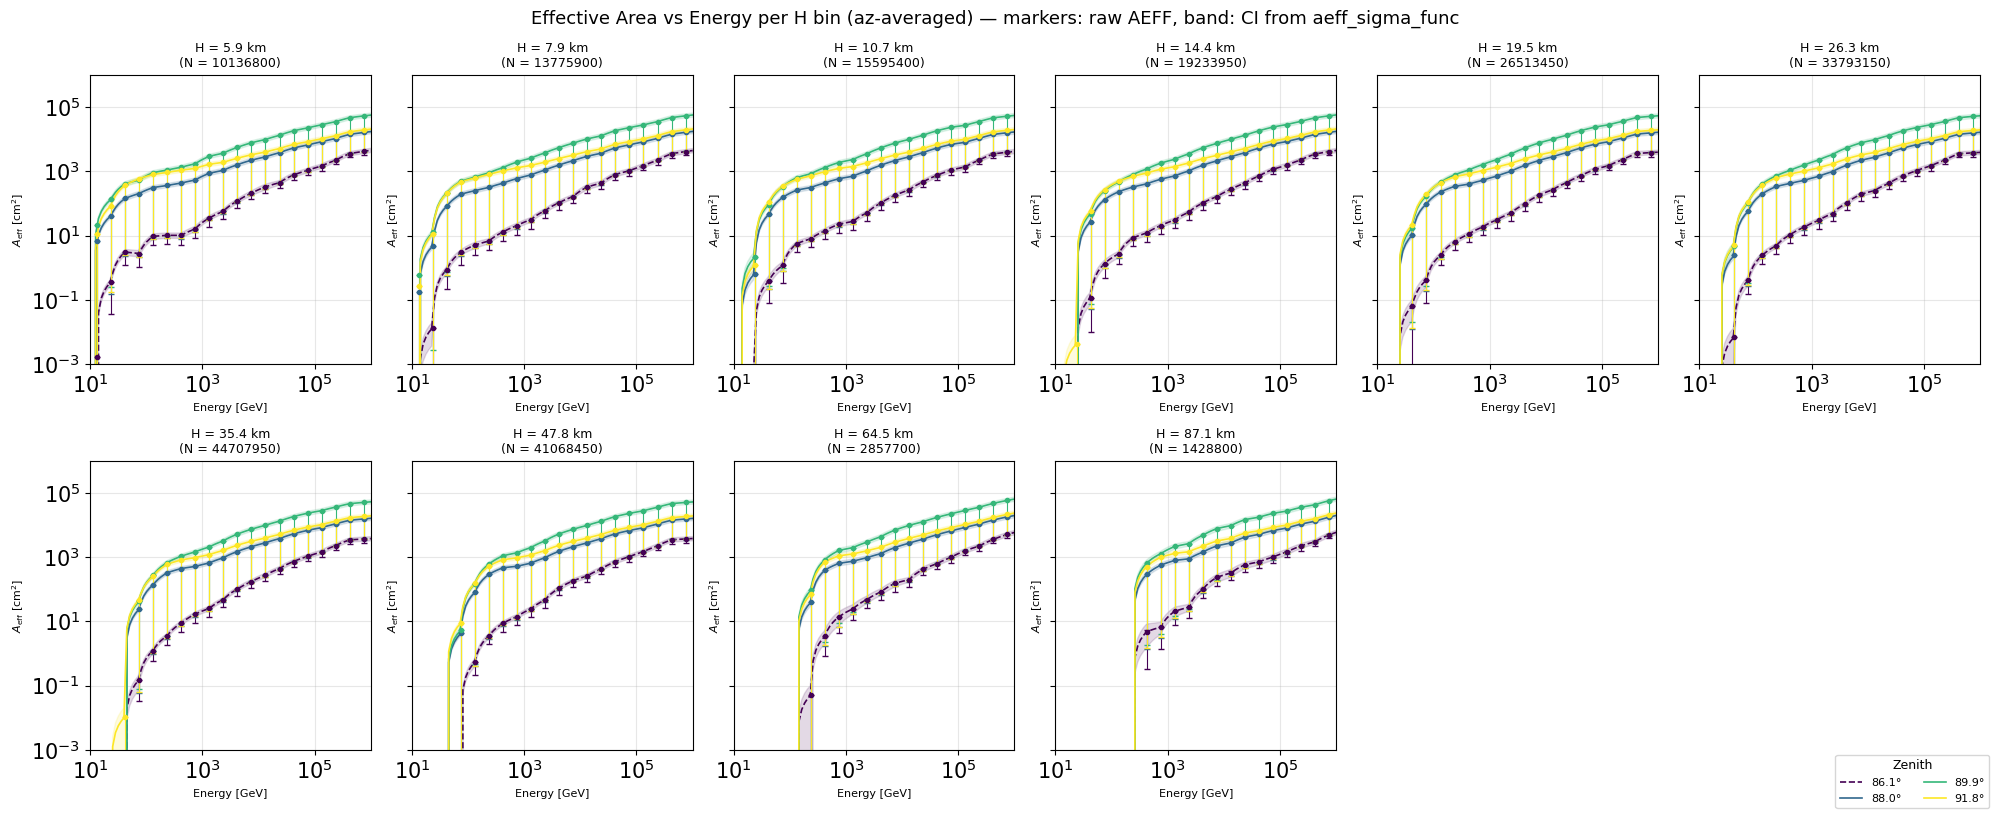

In [9]:
# Testing effective area vs Energy per zenith (averaged over azimuth)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

n_H = len(H_cen)
n_Z = len(Zen_grid)

ncols = 6
nrows = int(np.ceil(n_H / ncols))

MAX_ZEN_LINES = 4

# Subsample zenith indices
if n_Z <= MAX_ZEN_LINES:
    zen_inds = np.arange(n_Z)
else:
    zen_inds = np.linspace(0, n_Z - 1, MAX_ZEN_LINES).round().astype(int)
    zen_inds = np.unique(zen_inds)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(20, 4.1 * nrows),
    sharey=True,
)
axes = np.atleast_1d(axes).ravel()

colors = cm.viridis(np.linspace(0, 1, len(zen_inds)))

E_plot = np.logspace(np.log10(E_edges[0]), np.log10(E_edges[-1]), 100)

for j in range(n_H):
    ax    = axes[j]
    H_val = H_cen[j]

    for ci, k in enumerate(zen_inds):
        zen = Zen_grid[k]

        # --- average interpolator over all azimuth bins ---
        med_az, lo_az, hi_az = [], [], []
        for a in range(len(Az_grid)):
            az = Az_grid[a]
            med_c, lo_c, hi_c = area_sigma_func(
                E_plot,
                np.full_like(E_plot, H_val),
                np.full_like(E_plot, zen),
                np.full_like(E_plot, az),
            )
            med_az.append(med_c)
            lo_az.append(lo_c)
            hi_az.append(hi_c)

        med_curve = np.mean(med_az, axis=0)   # average over azimuth
        lo_curve  = np.mean(lo_az,  axis=0)
        hi_curve  = np.mean(hi_az,  axis=0)

        ax.plot(
            E_plot, med_curve,
            color=colors[ci],
            linestyle='-' if zen > 87 else '--',
            linewidth=1.2,
            label=f"{zen:.1f}°",
        )
        ax.fill_between(E_plot, lo_curve, hi_curve,
                        color=colors[ci], alpha=0.15)

        # --- raw AEFF markers: average over azimuth axis (axis=1 → az) ---
        aeff_row = np.nanmean(AEFF[k, :, j, :], axis=0)   # (n_az, n_E) → (n_E,)
        valid    = np.isfinite(aeff_row)
        if valid.any():
            med_pts, lo_pts, hi_pts = area_sigma_func(
                E_cen[valid],
                np.full_like(E_cen[valid], H_val),
                np.full_like(E_cen[valid], zen),
                np.full_like(E_cen[valid], Az_grid.mean()),  # mean az for markers
            )
            yerr = np.vstack([
                np.clip(aeff_row[valid] - lo_pts, 0, None),
                np.clip(hi_pts - aeff_row[valid], 0, None),
            ])
            ax.errorbar(
                E_cen[valid], aeff_row[valid],
                yerr=yerr,
                color=colors[ci],
                marker='o',
                markersize=3,
                linestyle='none',
                elinewidth=0.8,
                capsize=2,
            )

    ax.set_xscale('log')
    ax.set_xlim(E_edges[0], E_edges[-1])
    ax.set_yscale('log')
    ax.set_title(
        f"H = {H_cen[j]/1e3:.1f} km\n"
        f"(N = {COUNTS[:, :, j, :].sum()})",
        fontsize=9,
    )
    ax.set_xlabel("Energy [GeV]", fontsize=8)
    ax.set_ylabel(r"$A_{\mathrm{eff}}$ [cm$^2$]", fontsize=8)
    ax.grid(True, which='both', alpha=0.3)

# Autoscale y-limits based on actual data range (no fixed [1e-8, 1] bound)
all_finite = AEFF[np.isfinite(AEFF) & (AEFF > 0)]
if all_finite.size:
    ymin = 10 ** np.floor(np.log10(np.nanpercentile(all_finite, 0.5)))
    ymax = 10 ** np.ceil(np.log10(np.nanpercentile(all_finite, 99.5)))
    for ax in axes[:n_H]:
        ax.set_ylim(ymin, ymax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Zenith",
    loc='lower right',
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    bbox_to_anchor=(1.0, 0.0),
)

for j in range(n_H, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Effective Area vs Energy per H bin (az-averaged) — markers: raw AEFF, band: CI from aeff_sigma_func",
    fontsize=13,
)
plt.tight_layout()
plt.show()

In [10]:
# Muon Flux Tensor Calculation
import pickle
import numpy as np
import matplotlib.pyplot as plt

def convert_altitude_to_depth(altitude_m, zenith_deg):
    altitude_m  = np.asarray(altitude_m, dtype=float)
    altitude_km = altitude_m * 1e-3
    altitude_cm = altitude_m * 100.0

    zenith_deg  = np.asarray(zenith_deg, dtype=float)
    zenith_deg  = np.where(zenith_deg >= 90.0, 89.9, zenith_deg)

    depth = np.empty_like(altitude_m)

    m1 = (altitude_km >   0.0) & (altitude_km <   4.0)
    m2 = (altitude_km >=  4.0) & (altitude_km <  10.0)
    m3 = (altitude_km >= 10.0) & (altitude_km <  40.0)
    m4 = (altitude_km >= 40.0) & (altitude_km <= 100.0)
    m5 =  altitude_km > 100.0

    depth[m1] = -186.555305 + 1222.6562 * np.exp(-altitude_cm[m1] / 994186.38)
    depth[m2] =  -94.919    + 1144.9069 * np.exp(-altitude_cm[m2] / 878153.55)
    depth[m3] =    0.61289  + 1305.5948 * np.exp(-altitude_cm[m3] / 636143.04)
    depth[m4] =    0.0      +  540.1778 * np.exp(-altitude_cm[m4] / 772170.16)
    depth[m5] =    0.01128292 - altitude_cm[m5] / 1e9

    depth /= np.cos(np.deg2rad(zenith_deg))

    return depth

# --- CHANGED: use the 4D effective-area interpolator directly, no eff_sigma_func ---
def aeff_sigma_func_X(E_mesh, H_mesh, Z_mesh, A_mesh):
    X_mesh = convert_altitude_to_depth(H_mesh, Z_mesh)
    return aeff_sigma_func(E_mesh, H_mesh, Z_mesh, A_mesh)

# =========================================================================
# 2. Load the precomputed MCEq grid
# =========================================================================
with open('/scratch/general/vast/u1520754/data_Muon_Trinity/'
          'mceq_grid_80_90deg_Nzen100_no_decay_no_E_loss.pkl', 'rb') as f:     
    grid_data = pickle.load(f)

zen_centers_all = grid_data['zen_centers']
cos_edges       = grid_data['cos_edges']
sin_edges       = np.sqrt(1-cos_edges**2)
theta_edges     = np.arccos(cos_edges)
int_sin2_edges  = (theta_edges - sin_edges*cos_edges)/2
E_GeV           = grid_data['E_GeV']

min_E           = ENERGY_MIN
max_E           = 1e6
E_mask          = (E_GeV>=min_E)&(E_GeV<=max_E)
E_GeV           = E_GeV[E_mask]

zen_min_use, zen_max_use = 85, 90.0
tele_azimuth = 270
n_azimuth = 5

zen_mask = (zen_centers_all >= zen_min_use) & (zen_centers_all <= zen_max_use)
if not np.any(zen_mask):
    raise ValueError(
        f"No zenith bins in [{zen_min_use}, {zen_max_use}] deg. "
        f"Available centers: {zen_centers_all}"
    )

zen_centers = zen_centers_all[zen_mask]

min_az, max_az = tele_azimuth - AZIMUTH_RANGE, tele_azimuth + AZIMUTH_RANGE
phi = np.linspace(0, AZIMUTH_RANGE, n_azimuth)

dphi = np.radians(max_az - min_az)

selected_entries = [e for e, keep in zip(grid_data['per_zenith'], zen_mask) if keep]

n_A = len(phi)

flux_slices = []
zen_list    = []
X_list      = []
for entry in selected_entries:
    theta  = entry['theta']
    H_grid = entry['H_grid']
    d_CDF  = entry['d_CDF']
    X_grid = entry['X_grid']
    d_X = np.gradient(X_grid)[:,None]
    flux_HE = np.asarray(d_CDF)[:, E_mask]

    flux_HEA = np.broadcast_to(flux_HE[:, :, None], flux_HE.shape + (n_A,))

    flux_slices.append(flux_HEA)
    zen_list.append(theta)
    X_list.append(X_grid)
X_arr = np.array(X_list)
flux_tensor = np.stack(flux_slices, axis=0)

zen_arr = np.array(zen_list)

print("flux_tensor shape (Z, H, E, A):", flux_tensor.shape)
print("zenith values:", zen_arr)

# Common axes (built once)
H_m      = np.asarray(selected_entries[0]['H_grid']) / 100.0
E_axis   = np.asarray(E_GeV)
phi_axis = np.asarray(phi)

# 3D meshes for ONE zenith slice — built once, reused every iteration
H_mesh, E_mesh, A_mesh = np.meshgrid(H_m, E_axis, phi_axis, indexing='ij')

Z_mesh = np.empty_like(H_mesh)

# --- CHANGED: build aeff_tensor (effective area, cm^2) instead of eff_tensor ---
aeff_slices = []
aeff_slices_lo = []
aeff_slices_hi = []
for theta in zen_arr:
    print(theta)
    Z_mesh.fill(theta)
    aeff_HEA, aeff_lo, aeff_hi = area_sigma_func(E_mesh, H_mesh, Z_mesh, A_mesh)
    aeff_slices.append(aeff_HEA.astype(np.float32))
    aeff_slices_lo.append(aeff_lo.astype(np.float32))
    aeff_slices_hi.append(aeff_hi.astype(np.float32))

aeff_tensor    = np.stack(aeff_slices,    axis=0)   # (Z, H, E, A), units cm^2
aeff_tensor_lo = np.stack(aeff_slices_lo, axis=0)
aeff_tensor_hi = np.stack(aeff_slices_hi, axis=0)
print("aeff_tensor shape:", aeff_tensor.shape, "dtype:", aeff_tensor.dtype)
assert aeff_tensor.shape == flux_tensor.shape

# --- CHANGED: flux * effective area (instead of flux * efficiency) ---
flux_aeff_tensor    = aeff_tensor    * flux_tensor
flux_aeff_tensor_lo = aeff_tensor_lo * flux_tensor
flux_aeff_tensor_hi = aeff_tensor_hi * flux_tensor

# =========================================================================
# Extrapolate flux grid to 91.8 degrees by copying the 90-degree slice
# =========================================================================

idx_90 = np.argmin(np.abs(zen_arr - 90.0))
print(f"Using zenith slice at {zen_arr[idx_90]:.2f}° as the basis for extrapolation")

zen_extrap = np.degrees(np.arccos(np.linspace(np.cos(np.radians(91.8)), np.cos(np.radians(90)), 10)))

# --- Flux extrapolation ---
flux_extrap_slices = []
X_extrap = []
for z_new in zen_extrap:
    flux_extrap_slices.append(flux_tensor[idx_90].copy())
    X_extrap.append(X_arr[idx_90].copy())
flux_extrap_tensor = np.stack(flux_extrap_slices, axis=0)
print(f"flux_extrap_tensor shape: {flux_extrap_tensor.shape}")

# --- CHANGED: Effective-area extrapolation (recompute at new zenith angles) ---
aeff_extrap_slices    = []
aeff_extrap_slices_lo = []
aeff_extrap_slices_hi = []

for z_new in zen_extrap:
    print(f"Computing effective area at zenith = {z_new}°")
    Z_mesh_extrap = np.full_like(H_mesh, z_new)
    aeff_HEA, aeff_lo, aeff_hi = area_sigma_func(E_mesh, H_mesh, Z_mesh_extrap, A_mesh)
    aeff_extrap_slices.append(aeff_HEA.astype(np.float32))
    aeff_extrap_slices_lo.append(aeff_lo.astype(np.float32))
    aeff_extrap_slices_hi.append(aeff_hi.astype(np.float32))

aeff_extrap_tensor    = np.stack(aeff_extrap_slices,    axis=0)  # (Z_new, H, E, A)
aeff_extrap_tensor_lo = np.stack(aeff_extrap_slices_lo, axis=0)
aeff_extrap_tensor_hi = np.stack(aeff_extrap_slices_hi, axis=0)
print(f"aeff_extrap_tensor shape: {aeff_extrap_tensor.shape}")

# --- Concatenate original + extrapolated tensors ---
zen_arr_full          = np.concatenate([zen_extrap, zen_arr])
X_arr_full            = np.concatenate([np.array(X_extrap), X_arr])
flux_tensor_full      = np.concatenate([flux_extrap_tensor, flux_tensor], axis=0)
aeff_tensor_full      = np.concatenate([aeff_extrap_tensor,    aeff_tensor],    axis=0)
aeff_tensor_lo_full   = np.concatenate([aeff_extrap_tensor_lo, aeff_tensor_lo], axis=0)
aeff_tensor_hi_full   = np.concatenate([aeff_extrap_tensor_hi, aeff_tensor_hi], axis=0)

flux_aeff_tensor_full    = aeff_tensor_full    * flux_tensor_full
flux_aeff_tensor_lo_full = aeff_tensor_lo_full * flux_tensor_full
flux_aeff_tensor_hi_full = aeff_tensor_hi_full * flux_tensor_full

print(f"\nFinal combined tensor shapes:")
print(f"  zen_arr_full:          {zen_arr_full}")
print(f"  flux_tensor_full:      {flux_tensor_full.shape}")
print(f"  aeff_tensor_full:      {aeff_tensor_full.shape}")
print(f"  flux_aeff_tensor_full: {flux_aeff_tensor_full.shape}")

# --- CHANGED: variable names updated from eff_* to aeff_* for downstream use ---
zen_arr          = zen_arr_full
X_arr            = X_arr_full
flux_tensor      = flux_tensor_full
aeff_tensor      = aeff_tensor_full
aeff_tensor_lo   = aeff_tensor_lo_full
aeff_tensor_hi   = aeff_tensor_hi_full
flux_aeff_tensor    = flux_aeff_tensor_full
flux_aeff_tensor_lo = flux_aeff_tensor_lo_full
flux_aeff_tensor_hi = flux_aeff_tensor_hi_full

print("\nDone. Downstream variables updated to include 91.8° extrapolation, using effective-area (aeff) directly.")

flux_tensor shape (Z, H, E, A): (50, 1000, 50, 5)
zenith values: [89.95025346 89.85076022 89.75126653 89.65177209 89.5522766  89.45277976
 89.35328127 89.25378083 89.15427814 89.05477289 88.9552648  88.85575355
 88.75623886 88.65672041 88.5571979  88.45767105 88.35813953 88.25860306
 88.15906134 88.05951405 87.95996091 87.8604016  87.76083583 87.66126329
 87.56168369 87.46209671 87.36250206 87.26289944 87.16328854 87.06366906
 86.96404069 86.86440313 86.76475608 86.66509923 86.56543228 86.46575493
 86.36606686 86.26636778 86.16665737 86.06693534 85.96720137 85.86745516
 85.7676964  85.66792479 85.56814001 85.46834177 85.36852974 85.26870363
 85.16886312 85.0690079 ]
89.95025345524756
89.850760215738
89.75126652621034
89.65177208663894
89.5522765969778
89.45277975715244
89.35328126705171
89.25378082651967
89.15427813534743
89.05477289326498
88.95526479993308
88.85575355493502
88.75623885776848
88.6567204078374
88.55719790444367
88.45767104677908
88.35813953391704
88.25860306480433
88.15

In [11]:
#Compute the flux from the tensor
def Muon_Rate_Calculation(flux_aeff_tensor, E_axis, phi_axis, zen_arr, extra_area=None):
    """
    flux_aeff_tensor : (Z, H, E, A) tensor of flux already multiplied by
                       effective area [m^2] (or, if extra_area is given,
                       a bare flux tensor to be multiplied by that scalar/array
                       area, e.g. for the raw-rate case).
    extra_area       : optional scalar or broadcastable area [m^2] to apply
                       (use for raw_area with flux_tensor_full; leave None
                       when flux_aeff_tensor already includes A_eff).
    """
    if extra_area is not None:
        flux_aeff_tensor = flux_aeff_tensor * extra_area

    R_zen_az = np.sum(np.trapezoid(flux_aeff_tensor, x=E_axis, axis=2), axis=1)
    R_zen = 2 * np.trapezoid(R_zen_az * np.cos(np.radians(phi_axis)),
                              x=np.radians(phi_axis), axis=1)

    zen_arr = zen_arr - Telescope_Zenith #negative = above horizon, positive = below horizon
    zen_arr_pos = zen_arr[zen_arr >= 0]
    R_zen_pos = R_zen[zen_arr >= 0]
    R_pos = np.trapezoid(R_zen_pos * np.cos(np.radians(zen_arr_pos))**2,
                          x=-(np.radians(zen_arr_pos)), axis=0) * 3600 * 24

    zen_arr_neg = zen_arr[zen_arr < 0]
    R_zen_neg = R_zen[zen_arr < 0]
    R_neg = np.trapezoid(R_zen_neg * np.cos(np.radians(zen_arr_neg))**2,
                          x=-(np.radians(zen_arr_neg)), axis=0) * 3600 * 24

    R = R_neg + R_pos
    return R, R_neg, R_pos

# --- Effective-area-weighted rate: A_eff already folded into flux_aeff_tensor ---
Rate, Rate_above_horizon, Rate_below_horizon    = Muon_Rate_Calculation(flux_aeff_tensor,    E_axis, phi_axis, zen_arr)
Rate_lo, Rate_above_horizon_lo, Rate_below_horizon_lo = Muon_Rate_Calculation(flux_aeff_tensor_lo, E_axis, phi_axis, zen_arr)
Rate_hi, Rate_above_horizon_hi, Rate_below_horizon_hi = Muon_Rate_Calculation(flux_aeff_tensor_hi, E_axis, phi_axis, zen_arr)

# --- Raw rate: bare flux tensor still needs an explicit (scalar) raw_area ---
raw_area = 10000
Rate_raw = Muon_Rate_Calculation(flux_tensor_full, E_axis, phi_axis, zen_arr,
                                  extra_area=raw_area)[0]

print("Raw rate", Rate_raw)
print(Rate/3, "68% CI [", Rate_lo/3, Rate_hi/3, "] muons per 8 hours (Total)")
print(Rate_above_horizon/3, "68% CI [", Rate_above_horizon_lo/3, Rate_above_horizon_hi/3, "] muons per 8 hours (Above Horizon)")
print(Rate_below_horizon/3, "68% CI [", Rate_below_horizon_lo/3, Rate_below_horizon_hi/3, "] muons per 8 hours (Below Horizon)")

Raw rate 37891.689172238606
9.53055070858747 68% CI [ 8.065802899587434 10.998511724949362 ] muons per 8 hours (Total)
5.133051355371441 68% CI [ 4.342352995323837 5.925371258773385 ] muons per 8 hours (Above Horizon)
4.39749935321603 68% CI [ 3.7234499042635973 5.073140466175976 ] muons per 8 hours (Below Horizon)


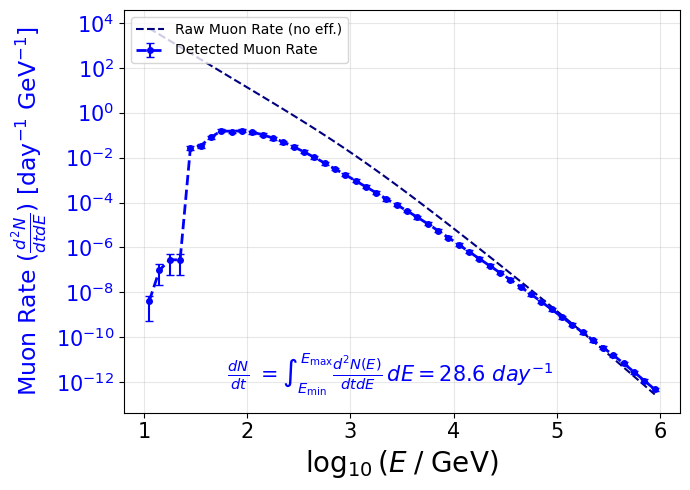

In [12]:
#Make the plot
def Muon_Rate_per_E_Calculation(flux_aeff_tensor, phi_axis, zen_arr, extra_area=None):
    """
    flux_aeff_tensor : (Z, H, E, A) flux tensor. If it already contains
                       flux * A_eff (per-bin, 4D), leave extra_area=None.
                       If it's a bare flux tensor (e.g. flux_tensor_full),
                       pass extra_area = raw_area (scalar) to apply it.
    """
    if extra_area is not None:
        flux_aeff_tensor = flux_aeff_tensor * extra_area

    R_zen_az_E = np.sum(flux_aeff_tensor, axis=1)
    R_zen_E = 2 * np.trapezoid(R_zen_az_E * np.cos(np.radians(phi_axis)),
                                x=np.radians(phi_axis), axis=2)
    zen_arr = zen_arr - Telescope_Zenith
    zen_arr_pos = zen_arr[zen_arr >= 0][:, None]
    R_zen_pos = R_zen_E[zen_arr >= 0]
    R_pos = np.trapezoid(R_zen_pos * np.cos(np.radians(zen_arr_pos))**2,
                          x=-(np.radians(zen_arr_pos)), axis=0) * 3600 * 24

    zen_arr_neg = zen_arr[zen_arr < 0][:, None]
    R_zen_neg = R_zen_E[zen_arr < 0]
    R_neg = np.trapezoid(R_zen_neg * np.cos(np.radians(zen_arr_neg))**2,
                          x=-(np.radians(zen_arr_neg)), axis=0) * 3600 * 24

    R_E = R_neg + R_pos
    return R_E

# --- Effective-area-weighted rate per energy: A_eff already folded into flux_aeff_tensor ---
R_E     = Muon_Rate_per_E_Calculation(flux_aeff_tensor,    phi_axis, zen_arr)
R_E_lo  = Muon_Rate_per_E_Calculation(flux_aeff_tensor_lo, phi_axis, zen_arr)
R_E_hi  = Muon_Rate_per_E_Calculation(flux_aeff_tensor_hi, phi_axis, zen_arr)

# --- Raw rate: bare flux tensor still needs an explicit (scalar) raw_area ---
R_E_raw = Muon_Rate_per_E_Calculation(flux_tensor_full, phi_axis, zen_arr, extra_area=raw_area)

R_eff = R_E / R_E_raw

fig, ax1 = plt.subplots(figsize=(7, 5))

# ── left axis : muon rate ──────────────────────────────────────────────────
color_rate = 'blue'

err_lo = R_E - R_E_lo  # lower error bar lengths (always positive)
err_lo = np.clip(err_lo, np.min(err_lo[err_lo>0]), None)
err_hi = R_E_hi - R_E   # upper error bar lengths (always positive)
E_data_mask = E_axis<= max(Energy_GeV)
ax1.errorbar(
    np.log10(E_axis[E_data_mask]), R_E[E_data_mask],
    yerr=[err_lo[E_data_mask], err_hi[E_data_mask]],
    fmt='--o',
    color=color_rate,
    ecolor=color_rate,
    elinewidth=1.5,
    capsize=3,
    markersize=4,
    linewidth=2,
    label='Detected Muon Rate',
)
ax1.plot(np.log10(E_axis), R_E_raw,
         color='navy', linewidth=1.5, linestyle='--', label='Raw Muon Rate (no eff.)')

ax1.set_yscale('log')
ax1.set_xlabel(r'$\log_{10}(E\;/\;\mathrm{GeV})$')
ax1.set_ylabel(r'Muon Rate $(\frac{d^{2}N}{dtdE})$ [day$^{-1}$ GeV$^{-1}$]', color=color_rate, fontsize=17)
ax1.tick_params(axis='y', labelcolor=color_rate)
ax1.legend(loc='upper left', fontsize=10)

# ── right axis : effective-area ratio (A_eff / A_raw) ──────────────────────
color_eff = 'black'
#ax2 = ax1.twinx()

# Ratio error bars propagated from lo/hi rate ratios
R_eff_lo = R_E_lo / R_E_raw
R_eff_hi = R_E_hi / R_E_raw

eff_err_lo = R_eff - R_eff_lo
eff_err_lo = np.clip(eff_err_lo, np.min(eff_err_lo[eff_err_lo>0]), None)

eff_err_hi = R_eff_hi - R_eff

"""ax2.errorbar(
    np.log10(E_axis[E_data_mask]), R_eff[E_data_mask],
    yerr=[eff_err_lo[E_data_mask], eff_err_hi[E_data_mask]],
    fmt='--s',
    color=color_eff,
    ecolor=color_eff,
    elinewidth=1.5,
    capsize=3,
    markersize=4,
    linewidth=2,
    label='Effective Area Ratio',
)

ax2.set_ylabel(r'Effective Area $(A_{\mathrm{eff}}/A_{\mathrm{raw}})$', color=color_eff, fontsize=17)
ax2.tick_params(axis='y', labelcolor=color_eff)
ax2.set_yscale("log")
ax2.legend(loc='upper right', fontsize=10)"""

# ── cosmetics ─────────────────────────────────────────────────────────────
ax1.grid(True, which='both', alpha=0.3)
ax1.text(1.8, 1e-12, 
        r"$\frac{dN}{dt}\ = \int_{E_{\min}}^{E_{\max}} \frac{d^{2}N(E)}{dtdE} \, dE =$"+ rf"${np.round(Rate,1)}$"+" "+r"$ day^{-1}$",
        fontsize=15,
        color = color_rate
)
fig.tight_layout()
#ax1.set_ylim(1e-13, 1e8)
#ax2.set_ylim(1e-9, 1e-1)
#plt.xlim(1.4, 6)
#plt.savefig("/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/plot/Muon_rate.png",transparent=True)
plt.show()